In [2]:
#!pip install 
from huggingface_hub import login
login("")

In [1]:
!pip install ../RMSearch

Processing /workspace/RMSearch
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.1/201.1 MB 130.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.5/906.5 MB 92.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 75.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 120.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 193.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 104.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 191.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 125.8 MB/s eta 0:00:0000:0100:

# Process Data

In [1]:
!pip install datasets
!pip install huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 160.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 178.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 204.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 219.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 209.1 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
from datasets import load_dataset
from huggingface_hub import snapshot_download

#dataset_name = "hatakeyama-llm-team/japanese2010"
#dataset_name = "hotchpotch/fineweb-2-edu-japanese-noise-detect-raw"
dataset_name = "HuggingFaceTB/smollm-corpus"
save_name = "smollm-corpus"

ds = load_dataset("HuggingFaceTB/smollm-corpus", "cosmopedia-v2", split="train", num_proc=16)
#ds = load_dataset(dataset_name)
ds

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/104 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/39134000 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/432 [00:00<?, ?it/s]

Dataset({
    features: ['prompt', 'text', 'token_length', 'audience', 'format', 'seed_data'],
    num_rows: 39134000
})

In [ ]:
from datasets import load_dataset, Features, Value

features = Features({
    "index": Value("int64"),   # extra column that is really there
    "text":  Value("string")
})

ds = load_dataset(
    "hatakeyama-llm-team/japanese2010",
    split="train",             # or any split you need
    features=features,         # override the script‑defined schema
    #ignore_verifications=True  # skip size/sha checks – speeds things up
)                              # :contentReference[oaicite:0]{index=0}

# drop the column you don’t need
ds = ds.remove_columns("index")


README.md:   0%|          | 0.00/554 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/1548 [00:00<?, ?it/s]

00000000_0.parquet:   0%|          | 0.00/113M [00:00<?, ?B/s]

00000000_1.parquet:   0%|          | 0.00/143M [00:00<?, ?B/s]

00000000_2.parquet:   0%|          | 0.00/140M [00:00<?, ?B/s]

...

00000009_1.parquet:   0%|          | 0.00/133M [00:00<?, ?B/s]

00000009_2.parquet:   0%|          | 0.00/121M [00:00<?, ?B/s]

00000009_3.parquet:   0%|          | 0.00/145M [00:00<?, ?B/s]

00000009_4.parquet:   0%|          | 0.00/144M [00:00<?, ?B/s]

00000009_5.parquet:   0%|          | 0.00/146M [00:00<?, ?B/s]

In [3]:
n_sample_train = 100000
#save_name = "ja-web-text-2"
save_name = "smollm-corpus"

ds = ds.shuffle(seed=42)
ds = ds.select(range(n_sample_train))

import pandas as pd   # only needed once
from datasets import DatasetDict  # your DatasetDict is already in memory as `ds`

df = ds.to_pandas()          # convert the split to a pandas DataFrame
print(df.shape)                 # (108000, 15) in your example
print(df.head())                 # (108000, 15) in your example
print(ds)

#ds = ds.shuffle(seed=42)
#ds = ds.select(range(n_sample))
ds.save_to_disk(f"./data/{save_name}")
df.to_csv(f"./data/{save_name}/df.csv", index=False)

NameError: name 'dataset' is not defined

In [4]:
df = ds.to_pandas()          # convert the split to a pandas DataFrame
print(df.shape)                 # (108000, 15) in your example
print(df.head())                 # (108000, 15) in your example
print(ds)

#ds = ds.shuffle(seed=42)
#ds = ds.select(range(n_sample))
ds.save_to_disk(f"./data/{save_name}")
df.to_csv(f"./data/{save_name}/df.csv", index=False)

(100000, 6)
                                              prompt  \
0  Write a long and very detailed course unit for...   
1  Here is an extract from a webpage:\n"Last year...   
2  Here is an extract from a webpage:\n"Do you wa...   
3  Here is an extract from a webpage:\n""There ar...   
4  Here is an extract from a webpage:\n"Irene Aba...   

                                                text  token_length  \
0   Welcome to Speaking Medieval: Ecologies of In...           642   
1   Welcome, future explorers! Get ready to embar...           664   
2   Course Unit: "Selling Books Online with Amazi...           742   
3   Chapter 1: The Wonderful World of Life Scienc...           653   
4   Traditional healing practices have been utili...          1256   

                 audience                         format seed_data  
0          young_children             textbook_narrative  stanford  
1  middle_school_students                       textbook   fineweb  
2  middle_school_studen

Saving the dataset (0/2 shards):   0%|          | 0/100000 [00:00<?, ? examples/s]

In [5]:
n_sample_train = 100000
n_sample_test = 8000
#save_name = "ja-web-text-2"
save_name = "smollm-corpus"

ds = ds.shuffle(seed=42)

ds["train"] = ds["train"].select(range(n_sample_train))
ds["test"] = ds["test"].select(range(n_sample_test))

import pandas as pd   # only needed once
from datasets import DatasetDict  # your DatasetDict is already in memory as `ds`

def datasetdict_to_pandas(dataset_dict: DatasetDict) -> pd.DataFrame:
    """Merge all splits in a DatasetDict into a single DataFrame with a `split` column."""
    frames = []
    for split_name, split_ds in dataset_dict.items():
        df = split_ds.to_pandas()          # convert the split to a pandas DataFrame
        df["split"] = split_name           # label rows with their origin
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

df_all = datasetdict_to_pandas(ds)  # ds is your original DatasetDict
print(df_all.shape)                 # (108000, 15) in your example
print(df_all.head())                 # (108000, 15) in your example

#ds = ds.shuffle(seed=42)
#ds = ds.select(range(n_sample))
ds.save_to_disk(f"./data/{save_name}")
print(ds)
df_all.to_csv(f"./data/{save_name}/df.csv", index=False)

(108000, 15)
                                     normalized_text   noise_spans  \
0  なにか自分の中で課題曲があったとして、\nその曲のアドリブを練習する前に考えるべきことがあり...            []   
1  開放骨折(右ひじ・右足)の治癒までの経過\n80歳の叔母ですが、交通事故にあい右ひじと右足(...  [[326, 337]]   
2  当城について\n当城では、絵画の巨匠の作品のコレクションを鑑賞することができます。ムリーリョ...            []   
3  遊水池としての機能を備えた新横浜公園(横浜市港北区小机町)が10月23日、台風21号の影響で...            []   
4  キーン(KEEN)の「ユニーク (UNEEK)」は、全く新しい靴づくりの発想で3年の歳月をか...            []   

                                                id             dump  \
0  <urn:uuid:f352c0b7-559c-4539-888f-35a42af68801>  CC-MAIN-2018-30   
1  <urn:uuid:18b047ab-965f-4579-ad07-769651ca78f9>  CC-MAIN-2017-26   
2  <urn:uuid:1e454fc6-d6c3-4561-9812-6f103ac95dae>  CC-MAIN-2017-13   
3  <urn:uuid:1940f835-c27d-4f04-bc0a-ded88c688cda>  CC-MAIN-2018-47   
4  <urn:uuid:ba2d4d5a-d4d5-4619-a5c6-30426f6d8b9e>  CC-MAIN-2020-40   

                                                 url                  date  \
0               https://jazzsounds.net/grouping-code  2018-07

Saving the dataset (0/1 shards):   0%|          | 0/100000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/8000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['normalized_text', 'noise_spans', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'language_script', 'minhash_cluster_size', 'top_langs', 'score', 'token_count'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['normalized_text', 'noise_spans', 'id', 'dump', 'url', 'date', 'file_path', 'language', 'language_score', 'language_script', 'minhash_cluster_size', 'top_langs', 'score', 'token_count'],
        num_rows: 8000
    })
})


In [2]:
aijsan

NameError: name 'aijsan' is not defined

In [5]:
# Make small df
n_small_sample = 10000
import pandas as pd

save_name = "smollm-corpus"

df_all = pd.read_csv(f"./data/{save_name}/df.csv")
df = df_all.sample(n_small_sample)
df.to_csv(f"./data/{save_name}/df_small.csv", index=False)
df

,prompt,text,token_length,audience,format,seed_data
90410,"Here is an extract from a webpage:\n""Your pers...",Chapter 9: Study Schedules and Planning Tools...,1379,college_students,textbook,fineweb
84358,"Here is an extract from a webpage:\n""As always...",**Unit Title:** Academic Mysteries in Science...,976,middle_school_students,textbook,fineweb
66094,"Here is an extract from a webpage: ""Childhood ...","Once upon a time, in a happy town called Mind...",948,children,story,fineweb
24678,"Here is an extract from a webpage: ""Membership...",Course Unit: Understanding Native American Sp...,959,college_students,textbook,fineweb
31659,"Here is an extract from a webpage: ""The reason...",Inheritance Patterns and the Importance of Pa...,1171,college_students,textbook,fineweb
...,...,...,...,...,...,...
93072,"Here is an extract from a webpage:\n""Reading f...",Course Unit: Understanding Emotions and Their...,698,middle_school_students,textbook_unconditionned_topic,fineweb
58064,"Here is an extract from a webpage: ""Program Ma...",Chapter 9: The Business Side of Healthcare: A ...,778,middle_school_students,textbook,fineweb
72177,"Here is an extract from a webpage:\n""ORIGINAL ...",Chapter 1: Helping Students Succeed in Math a...,682,middle_school_students,textbook_unconditionned_topic,fineweb
26305,"Here is an extract from a webpage: ""Constructi...","Once upon a time, in a vast forest filled with...",495,children,story,fineweb


# Generate Tag Graph

In [2]:
!pip install -U vllm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.4/436.4 MB 127.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 198.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.1/888.1 MB 134.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 144.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 99.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 122.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 333.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 173.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 30.5 MB/s eta 0:00:00


In [1]:
import pandas as pd      # only needed if you want to manipulate the result further
from typing import List, Tuple, Dict, Any, Optional
from generate_tag_graph2 import generate_tag, embed_tags, get_tag_group, generate_representative_tag, _embed_pool_context, generate_tag_tree
import os, json, random
import torch

"""
Minimal debugging run. Adjust model names to ones you have locally.
- For vLLM (generation): use a small instruct model, e.g. "Qwen2.5-3B-Instruct" or "meta-llama/Meta-Llama-3-8B-Instruct".
- For embeddings: the user’s reference model "intfloat/e5-mistral-7b-instruct" works with SentenceTransformer.
"""
# ----- CONFIG -----
working_dir = "/workspace/RMS_exp"
data_name = "smollm-corpus"
#data_name = "test"
GEN_MODEL = os.environ.get("VLLM_MODEL", "/workspace/qwen7b")
EMB_MODEL = os.environ.get("EMB_MODEL", "intfloat/e5-mistral-7b-instruct")
SAVE_EMB = f"{working_dir}/data/{data_name}/key_embeddings.pt"
N_GROUP = 5000
N_TAG_SAMPLE = 6
tensor_parallel_size = 1
num_instances = 1
device_groups = []
device_id = 0
for dp in range(num_instances):
    device_group = []
    for tp in range(tensor_parallel_size):
        device_group.append(device_id)
        device_id += 1

    device_groups.append(device_group)
    
random.seed(0)

'''
# ----- SAMPLE KEYS (replace with yours) -----
sample_keys = [
    "Graph-based retrieval augmentation for enterprise documents",
    "Reward models for search result re-ranking",
    "Neural sparse indexing for web-scale retrieval",
    "Semantic tagging of legal contracts",
    "LLM orchestration with multi-agent planners",
    "Efficient RAG with vector + keyword hybrid",
    "Biomedical literature triage with MeSH terms",
    "GPU-efficient vLLM serving on multi-GPU",
    "Evaluation of negotiation agents with self-play",
    "Knowledge graph construction from PDFs",
]
'''

csv_name = "df_small.csv"
#ds = load_from_disk(f"./data/{save_name}") 
#df = ds.to_pandas()
df = pd.read_csv(f"./data/{data_name}/{csv_name}")
keys = df['text'].to_list()

if not os.path.exists(f"/workspace/RMS_exp/data/{data_name}"):
    os.makedirs(f"/workspace/RMS_exp/data/{data_name}")

INFO 09-25 02:38:35 [__init__.py:216] Automatically detected platform cuda.


In [3]:
print(">>> Generating tags with vLLM ...")
tag_recs = generate_tag(keys, model_name=GEN_MODEL, batch_size=1000)
for r in tag_recs[:2]:
    print(f"[key_id={r['key_id']}] {r['key']}\n  tags={r['tags']}")

with open(f"{working_dir}/data/{data_name}/tag_recs.json", "w") as f:
    json.dump(tag_recs, f)

`torch_dtype` is deprecated! Use `dtype` instead!


>>> Generating tags with vLLM ...
INFO 09-23 13:17:04 config.py:478] This model supports multiple tasks: {'embed', 'reward', 'classify', 'score', 'generate'}. Defaulting to 'generate'.
INFO 09-23 13:17:04 llm_engine.py:249] Initializing an LLM engine (v0.6.5) with config: model='/workspace/qwen7b', speculative_config=None, tokenizer='/workspace/qwen7b', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_time=False), seed=0, served_

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 09-23 13:18:17 model_runner.py:1097] Loading model weights took 14.2487 GB
INFO 09-23 13:18:23 worker.py:241] Memory profiling takes 5.51 seconds
INFO 09-23 13:18:23 worker.py:241] the current vLLM instance can use total_gpu_memory (23.57GiB) x gpu_memory_utilization (0.90) = 21.22GiB
INFO 09-23 13:18:23 worker.py:241] model weights take 14.25GiB; non_torch_memory takes 0.09GiB; PyTorch activation peak memory takes 4.35GiB; the rest of the memory reserved for KV Cache is 2.52GiB.
INFO 09-23 13:18:23 gpu_executor.py:76] # GPU blocks: 2948, # CPU blocks: 4681
INFO 09-23 13:18:23 gpu_executor.py:80] Maximum concurrency for 32768 tokens per request: 1.44x
INFO 09-23 13:18:26 model_runner.py:1413] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 09-23 13:18:26 model_runner.py:1417] If out-of-memory error occurs during cudagraph captur

Processed prompts:   2%|▏         | 20/1000 [00:11<04:58,  3.28it/s, est. speed input: 1150.29 toks/s, output: 54.13 toks/s]

...

WARNING 09-23 13:41:24 scheduler.py:1555] Sequence group 6863 is preempted by PreemptionMode.RECOMPUTE mode because there is not enough KV cache space. This can affect the end-to-end performance. Increase gpu_memory_utilization or tensor_parallel_size to provide more KV cache memory. total_num_cumulative_preemption=101


Processed prompts:  17%|█▋        | 169/1000 [00:41<04:45,  2.91it/s, est. speed input: 3061.26 toks/s, output: 377.50 toks/s]

WARNING 09-23 13:49:22 scheduler.py:1555] Sequence group 9224 is preempted by PreemptionMode.RECOMPUTE mode because there is not enough KV cache space. This can affect the end-to-end performance. Increase gpu_memory_utilization or tensor_parallel_size to provide more KV cache memory. total_num_cumulative_preemption=151


Processed prompts: 100%|██████████| 1000/1000 [03:18<00:00,  5.04it/s, est. speed input: 3854.82 toks/s, output: 504.71 toks/s]


[key_id=0]  Chapter 9: Study Schedules and Planning Tools - Harnessing Technology for Academic Success

In today's fast-paced world, technology has become an integral part of our lives. From communication to entertainment, its influence is undeniable. However, one area where technology has shown significant promise is education. With the advent of artificial intelligence (AI), learning has been revolutionized like never before. This chapter focuses on how AI tools such as StudyMonkey can aid high school students in creating effective study schedules and planning their academic pursuits. By exploring various aspects of these digital study aids, this chapter aims to equip learners with the necessary knowledge to maximize their potential and achieve success in entrance examinations.

I. Understanding Artificial Intelligence and Its Role in Education

Artificial intelligence refers to the simulation of human intelligence processes by machines, particularly computer systems. These processes

In [ ]:
with open(f"{working_dir}/data/{data_name}/tag_recs.json") as f:
    tag_recs = json.load(f)

print("\n>>> Embedding tags with SentenceTransformer ...")

pool_settings = {
    "tensor_parallel_size": tensor_parallel_size,
    "num_instances": num_instances,
    "device_groups": device_groups,
    #"llm_kwargs": llm_kwargs,
}
batch_size = 10
timeout = 1000

with _embed_pool_context(EMB_MODEL, **pool_settings) as pool:
    emb = embed_tags(
        tag_records=tag_recs,
        embed_model_name=EMB_MODEL,
        pool=pool,
        worker_batch_size=batch_size,
        timeout_s=timeout,
    )

print("embeddings:", tuple(emb.shape), emb.dtype, emb.device)

torch.save(emb, f"{working_dir}/data/{data_name}/key_embeddings.pt")

== Worker logs ==
[Worker 0] loading model…
INFO 09-24 12:23:31 [utils.py:328] non-default args: {'task': 'embed', 'disable_log_stats': True, 'enforce_eager': True, 'model': 'intfloat/e5-mistral-7b-instruct'}


In [ ]:
with open(f"{working_dir}/data/{data_name}/tag_recs.json") as f:
    tag_recs = json.load(f)
emb = torch.load(f"{working_dir}/data/{data_name}/key_embeddings.pt")

print("\n>>> Clustering keys into groups ...")
tag_recs, centroids, group_recs = get_tag_group(tag_records=tag_recs, embeddings=emb, n_group=N_GROUP)
for g in group_recs[:10]:
    print(f"[group {g['group_id']}] members≈{len(g['tag_ids'])} tags_in_union={len(g['tags'])}")

torch.save(centroids, f"{working_dir}/data/{data_name}/centroids.pt")
with open(f"{working_dir}/data/{data_name}/tag_recs.json", "w") as f:
    json.dump(tag_recs, f)
with open(f"{working_dir}/data/{data_name}/group_recs.json", "w") as f:
    json.dump(group_recs, f)



In [2]:
with open(f"{working_dir}/data/{data_name}/tag_recs.json") as f:
    tag_recs = json.load(f)
with open(f"{working_dir}/data/{data_name}/group_recs.json") as f:
    group_recs = json.load(f)

    
print("\n>>> Generating representative tag per group with vLLM ...")
group_recs = generate_representative_tag(
    tag_records=tag_recs,
    group_records=group_recs,
    #embeddings=emb,
    n_tag_sample=N_TAG_SAMPLE,
    model_name=GEN_MODEL
)
for g in group_recs[:10]:
    print(f"[group {g['group_id']}] rep='{g['representative_tag']}'")

with open(f"{working_dir}/data/{data_name}/group_recs.json", "w") as f:
    json.dump(group_recs, f)

print("\n>>> Done. Saved reuslt to:", f"{working_dir}/data/{data_name}")


== Worker logs ==
[Worker 0] generating: 623/625 (99.7%) · 1.85 batch/s · ETA 1.1s
[group 0] rep='Active Listening Empathy Empathy Empathetic Communication Em'
[group 1] rep='Patriarchy Patriarchy Patriarchy Patriarchy P'
[group 2] rep='Real_Estate_Laws'
[group 3] rep='Origins National Origin Origins Origins Knowledge Origin Ori'
[group 4] rep='End-of-life-care'
[group 5] rep='Misinformation Campaigns'
[group 6] rep='Thesis Statement Do NOT include punctuation at the end. Outp'
[group 7] rep='urban development planning Do NOT include punctuation at the'
[group 8] rep='Derivatives Regulation Pricing Hedging #Output: Deriv'
[group 9] rep='Publishing sectors #output without space at end'

>>> Done. Saved reuslt to: /workspace/RMS_exp/data/smollm-corpus


In [2]:
with open(f"{working_dir}/data/{data_name}/tag_recs.json") as f:
    tag_recs = json.load(f)
with open(f"{working_dir}/data/{data_name}/group_recs.json") as f:
    group_recs = json.load(f)
centroids = torch.load(f"{working_dir}/data/{data_name}/centroids.pt")

tag_tree_recs = generate_tag_tree(
    group_records = group_recs,
    centroids = centroids,
    tree_struc = [500, 50, 10],
    n_tag_sample = 20,
    model_name=GEN_MODEL,
    tensor_parallel_size=tensor_parallel_size,
    num_instances=num_instances,
    worker_batch_size=100,
)

with open(f"{working_dir}/data/{data_name}/tag_tree_recs.json", "w") as f:
    json.dump(tag_tree_recs, f)

== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initializing…
== Worker l

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 09-25 02:38:56 [__init__.py:1815] Using max model len 2500
== Worker logs ==
[Worker 0] loading model…
== Worker logs ==
[Worker 0] loading model…
INFO 09-25 02:38:57 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
== Worker logs ==
[Worker 0] loading model…
== Worker logs ==
[Worker 0] loading model…
== Worker logs ==
[Worker 0] loading model…
(EngineCore_DP0 pid=4830) INFO 09-25 02:38:57 [core.py:654] Waiting for init message from front-end.
(EngineCore_DP0 pid=4830) INFO 09-25 02:38:57 [core.py:76] Initializing a V1 LLM engine (v0.10.2) with config: model='/workspace/qwen7b', speculative_config=None, tokenizer='/workspace/qwen7b', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2500, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce

[W925 02:39:00.933799427 ProcessGroupNCCL.cpp:981] Warning: TORCH_NCCL_AVOID_RECORD_STREAMS is the default now, this environment variable is thus deprecated. (function operator())


(EngineCore_DP0 pid=4830) INFO 09-25 02:39:00 [gpu_model_runner.py:2338] Starting to load model /workspace/qwen7b...
== Worker logs ==
[Worker 0] loading model…
(EngineCore_DP0 pid=4830) INFO 09-25 02:39:00 [gpu_model_runner.py:2370] Loading model from scratch...
(EngineCore_DP0 pid=4830) INFO 09-25 02:39:00 [cuda.py:362] Using Flash Attention backend on V1 engine.
== Worker logs ==
[Worker 0] loading model…


...

== Worker logs ==
[Worker 0] generating: 0/1 ( 0.0%) · 0.00 batch/s · ETA 0.0s
== Worker logs ==
[Worker 0] generating: 0/1 ( 0.0%) · 0.00 batch/s · ETA 0.0s
== Worker logs ==
[Worker 0] initializing…
== Worker logs ==
[Worker 0] initialized: 0/1 (0.0%)


Processed prompts:  50%|█████     | 5/10 [00:00<00:00, 19.52it/s, est. speed input: 1193.94 toks/s, output: 89.70 toks/s]

== Worker logs ==
[Worker 0] initialized: 0/1 (0.0%)
== Worker logs ==
[Worker 0] initialized: 0/1 (0.0%)


Processed prompts: 100%|██████████| 10/10 [00:00<00:00, 17.61it/s, est. speed input: 1870.21 toks/s, output: 178.02 toks/s]


== Worker logs ==
[Worker 0] initialized: 0/1 (0.0%)


In [ ]:
def generate_tag(keys: List[str], model_name: str):
    return tag_records # [{"key":, "key_id":, "tags":[]}, ...]

def embed_tags(tag_records, save_path, embed_model_name:str):
    return embeddings # torch.tensor([[...], ...]). # shape:[n_keys, embed_dim]

def get_tag_group(tag_records, embeddings, n_group:int):

    # tag_records = [{"key":str, "key_id":int, "tags":List[str], "group_ids":List[int]}, ...]
    # centroids = torch.tensor([[...], ...])   # shape: [n_group, embed_dim]
    # group_records = [{"group_id":int, "tags":List[str], "tag_ids":List[Tuple[int, int]]}]. # tag_ids = (key_id where the tag comes from, tag_id in the tags in dict in tag_records)
    return tag_records, centroids, group_records

def generate_representative_tag(tag_records, group_records, embeddings, n_tag_sample:int, model_name: str):
    # get n_tag_sample tags sampled from each group tags and llm generates a longer tag which represents the group.
    
    # group_records = [{"group_id":int, "representative_tag":str, "centroid":torch.tensor([]), "tags":List[str], "tag_ids":List[Tuple[int, int]]}]
    return group_records

def generate_tag_tree(group_records, centroids, tree_struc: List[int], n_tag_sample:int):
    # ex. 
    # tree_struc=[500, 50, 10] 
    # len(centroids)=5000 
    # n_tag_sample=20

    # 1. apply k_means to centroids and get 500 new_centroids
    # 2. from representative tags in each group, make new representative tag
    # 3. iterate this until the end of tree struc and get tag_tree
    # tag_tree_recs = [{"tag":, "children": [{"tag":, "children":...}, ...]}, ...]
    # here each tag is same as representative tag 
    # tag_tree_recs represents tree structure of tags and there are 10 tags at the top, 50 in total at second depth, and ...
    # each tag branch should be children of tag which is generated from it

    return tag_tree_recs


# Generate Tag Graph2 (Using outsource library for hierarchical kmeans)

In [ ]:
!pip install -U vllm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 436.4/436.4 MB 127.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 198.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.1/888.1 MB 134.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 144.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 MB 99.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 122.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 333.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 173.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 30.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd      # only needed if you want to manipulate the result further
from typing import List, Tuple, Dict, Any, Optional
from generate_tag_graph2 import generate_tag, embed_tags, get_tag_group, generate_representative_tag, _embed_pool_context, generate_tag_tree
import os, json, random
import torch
from hierarchical_kmeans import HierarchicalKMeans

"""
Minimal debugging run. Adjust model names to ones you have locally.
- For vLLM (generation): use a small instruct model, e.g. "Qwen2.5-3B-Instruct" or "meta-llama/Meta-Llama-3-8B-Instruct".
- For embeddings: the user’s reference model "intfloat/e5-mistral-7b-instruct" works with SentenceTransformer.
"""
# ----- CONFIG -----
working_dir = "/workspace/RMS_exp"
data_name = "smollm-corpus"
#data_name = "test"
GEN_MODEL = os.environ.get("VLLM_MODEL", "/workspace/qwen7b")
EMB_MODEL = os.environ.get("EMB_MODEL", "intfloat/e5-mistral-7b-instruct")
SAVE_EMB = f"{working_dir}/data/{data_name}/key_embeddings.pt"
N_GROUP = 5000
N_TAG_SAMPLE = 6
tensor_parallel_size = 1
num_instances = 1
device_groups = []
device_id = 0
for dp in range(num_instances):
    device_group = []
    for tp in range(tensor_parallel_size):
        device_group.append(device_id)
        device_id += 1

    device_groups.append(device_group)
    
random.seed(0)

'''
# ----- SAMPLE KEYS (replace with yours) -----
sample_keys = [
    "Graph-based retrieval augmentation for enterprise documents",
    "Reward models for search result re-ranking",
    "Neural sparse indexing for web-scale retrieval",
    "Semantic tagging of legal contracts",
    "LLM orchestration with multi-agent planners",
    "Efficient RAG with vector + keyword hybrid",
    "Biomedical literature triage with MeSH terms",
    "GPU-efficient vLLM serving on multi-GPU",
    "Evaluation of negotiation agents with self-play",
    "Knowledge graph construction from PDFs",
]
'''

csv_name = "df_small.csv"
#ds = load_from_disk(f"./data/{save_name}") 
#df = ds.to_pandas()
df = pd.read_csv(f"./data/{data_name}/{csv_name}")
keys = df['text'].to_list()

if not os.path.exists(f"/workspace/RMS_exp/data/{data_name}"):
    os.makedirs(f"/workspace/RMS_exp/data/{data_name}")

INFO 09-25 02:38:35 [__init__.py:216] Automatically detected platform cuda.


In [ ]:
print(">>> Generating tags with vLLM ...")
tag_recs = generate_tag(keys, model_name=GEN_MODEL, batch_size=1000)
for r in tag_recs[:2]:
    print(f"[key_id={r['key_id']}] {r['key']}\n  tags={r['tags']}")

with open(f"{working_dir}/data/{data_name}/tag_recs.json", "w") as f:
    json.dump(tag_recs, f)

`torch_dtype` is deprecated! Use `dtype` instead!


>>> Generating tags with vLLM ...
INFO 09-23 13:17:04 config.py:478] This model supports multiple tasks: {'embed', 'reward', 'classify', 'score', 'generate'}. Defaulting to 'generate'.
INFO 09-23 13:17:04 llm_engine.py:249] Initializing an LLM engine (v0.6.5) with config: model='/workspace/qwen7b', speculative_config=None, tokenizer='/workspace/qwen7b', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_time=False), seed=0, served_

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 09-23 13:18:17 model_runner.py:1097] Loading model weights took 14.2487 GB
INFO 09-23 13:18:23 worker.py:241] Memory profiling takes 5.51 seconds
INFO 09-23 13:18:23 worker.py:241] the current vLLM instance can use total_gpu_memory (23.57GiB) x gpu_memory_utilization (0.90) = 21.22GiB
INFO 09-23 13:18:23 worker.py:241] model weights take 14.25GiB; non_torch_memory takes 0.09GiB; PyTorch activation peak memory takes 4.35GiB; the rest of the memory reserved for KV Cache is 2.52GiB.
INFO 09-23 13:18:23 gpu_executor.py:76] # GPU blocks: 2948, # CPU blocks: 4681
INFO 09-23 13:18:23 gpu_executor.py:80] Maximum concurrency for 32768 tokens per request: 1.44x
INFO 09-23 13:18:26 model_runner.py:1413] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 09-23 13:18:26 model_runner.py:1417] If out-of-memory error occurs during cudagraph captur

Processed prompts:   2%|▏         | 20/1000 [00:11<04:58,  3.28it/s, est. speed input: 1150.29 toks/s, output: 54.13 toks/s]

...

WARNING 09-23 13:41:24 scheduler.py:1555] Sequence group 6863 is preempted by PreemptionMode.RECOMPUTE mode because there is not enough KV cache space. This can affect the end-to-end performance. Increase gpu_memory_utilization or tensor_parallel_size to provide more KV cache memory. total_num_cumulative_preemption=101


Processed prompts:  17%|█▋        | 169/1000 [00:41<04:45,  2.91it/s, est. speed input: 3061.26 toks/s, output: 377.50 toks/s]

WARNING 09-23 13:49:22 scheduler.py:1555] Sequence group 9224 is preempted by PreemptionMode.RECOMPUTE mode because there is not enough KV cache space. This can affect the end-to-end performance. Increase gpu_memory_utilization or tensor_parallel_size to provide more KV cache memory. total_num_cumulative_preemption=151


Processed prompts: 100%|██████████| 1000/1000 [03:18<00:00,  5.04it/s, est. speed input: 3854.82 toks/s, output: 504.71 toks/s]


[key_id=0]  Chapter 9: Study Schedules and Planning Tools - Harnessing Technology for Academic Success

In today's fast-paced world, technology has become an integral part of our lives. From communication to entertainment, its influence is undeniable. However, one area where technology has shown significant promise is education. With the advent of artificial intelligence (AI), learning has been revolutionized like never before. This chapter focuses on how AI tools such as StudyMonkey can aid high school students in creating effective study schedules and planning their academic pursuits. By exploring various aspects of these digital study aids, this chapter aims to equip learners with the necessary knowledge to maximize their potential and achieve success in entrance examinations.

I. Understanding Artificial Intelligence and Its Role in Education

Artificial intelligence refers to the simulation of human intelligence processes by machines, particularly computer systems. These processes

In [ ]:
with open(f"{working_dir}/data/{data_name}/tag_recs.json") as f:
    tag_recs = json.load(f)

print("\n>>> Embedding tags with SentenceTransformer ...")

pool_settings = {
    "tensor_parallel_size": tensor_parallel_size,
    "num_instances": num_instances,
    "device_groups": device_groups,
    #"llm_kwargs": llm_kwargs,
}
batch_size = 10
timeout = 1000

with _embed_pool_context(EMB_MODEL, **pool_settings) as pool:
    emb = embed_tags(
        tag_records=tag_recs,
        embed_model_name=EMB_MODEL,
        pool=pool,
        worker_batch_size=batch_size,
        timeout_s=timeout,
    )

print("embeddings:", tuple(emb.shape), emb.dtype, emb.device)

torch.save(emb, f"{working_dir}/data/{data_name}/key_embeddings.pt")

In [ ]:
emb = torch.load(f"{working_dir}/data/{data_name}/key_embeddings.pt")

# Build a k-means tree with branching factor 3, and leaf size < 60
hkm = HierarchicalKMeans(n_clusters=10, max_leaf_size=60, random_state=0)
hkm.fit(emb)

# Show leaf sizes
members = hkm.leaf_members()
print("Number of leaves:", len(members))
sizes = {nid: idxs for nid, idxs in members.items()}
print("Leaf sizes:", sizes)

# Predict which leaf a new point belongs to
test_pts = np.array([[0.2, 0.1], [5.2, 5.0], [0.1, 5.9]])
print("Assignments:", hkm.predict(test_pts))

In [ ]:
from typing import Dict, Any, List, Tuple, Iterable

def _as_int_list(xs: Iterable) -> List[int]:
    # Works for numpy arrays, lists, tuples—anything iterable of numbers.
    return [int(x) for x in xs]

def _sorted_keys_numeric(keys: Iterable[str]) -> List[str]:
    # Sort child segment keys numerically if possible (e.g., '0','1','2',...)
    return sorted(keys, key=lambda k: (0, int(k)) if k.isdigit() else (1, k))

def convert_tree_dict_to_json(tree: Dict[str, Iterable]) -> List[Dict[str, Any]]:
    """
    Convert a dict like {'root/0/1': np.array([...]), 'root/1': np.array([...]), ...}
    into a JSON-like nested structure:
      [
        {"tag_ids": [], "children": [ {"tag_ids":[...]}, {"tag_ids":[...]} ]},
        {"tag_ids":[...]}
      ]
    """
    # Internal node storage by path tuple (excluding the literal 'root')
    Node = Dict[str, Any]
    nodes: Dict[Tuple[str, ...], Node] = {}

    def get_node(path: Tuple[str, ...]) -> Node:
        if path not in nodes:
            nodes[path] = {"tag_ids": [], "children": {}}
        return nodes[path]

    # Ensure root exists
    get_node(())  # path () represents 'root' itself

    # Insert all leaves; create intermediates as needed
    for key, ids in tree.items():
        parts = key.split('/')
        if not parts or parts[0] != 'root':
            raise ValueError(f"All keys must start with 'root': got {key}")
        segs = tuple(parts[1:])  # e.g., ('0','1') or ('1',)

        # Create intermediate nodes
        for i in range(len(segs)):
            parent_path = segs[:i]
            child_key = segs[i]
            parent = get_node(parent_path)
            child_path = segs[:i+1]
            child = get_node(child_path)
            parent["children"].setdefault(child_key, child)

        # Set tag_ids on the leaf node
        leaf = get_node(segs)
        leaf["tag_ids"] = _as_int_list(ids)

    # Recursively serialize node -> {"tag_ids": [...], "children":[...]} dropping empty children
    def serialize(node: Node) -> Dict[str, Any]:
        out = {"tag_ids": node["tag_ids"]}
        if node["children"]:
            children_objs = []
            for k in _sorted_keys_numeric(node["children"].keys()):
                child = node["children"][k]
                children_objs.append(serialize(child))
            out["children"] = children_objs
        return out

    # Top-level output is the list of root's immediate children
    root = nodes[()]
    result = []
    for k in _sorted_keys_numeric(root["children"].keys()):
        result.append(serialize(root["children"][k]))
    return result

tag_tree_recs = convert_tree_dict_to_json(sizes)


In [ ]:
# Use Model from local environment

import asyncio
from transformers import AutoTokenizer
from vllm import AsyncLLMEngine, AsyncEngineArgs, SamplingParams
import time, warnings
import os
from tqdm import tqdm

model_name = "/workspace/qwen7b"
tensor_parallel_size = 2
pipeline_parallel_size = 1
data_parallel_size = 2

engine_args = AsyncEngineArgs(
    model = model_name,
    tensor_parallel_size = tensor_parallel_size,
    pipeline_parallel_size = pipeline_parallel_size,
    data_parallel_size = data_parallel_size,
    gpu_memory_utilization=0.95,
    disable_log_stats=True,
)
engine = AsyncLLMEngine.from_engine_args(engine_args)
engine.log_requests = False
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side='left')

from jsonschema import validate, ValidationError

def validate_item(item, schema):
    try:
        validate(item, schema)
        return True, None
    except ValidationError as e:
        return False, str(e)


class AllRequests:
    
    def __init__(self, max_request):
        self.max_request = max_request
        self.requests = []
        self.request_ids = []
        self.request_id = 0
        self.results = []
        self.finished_ids = []
        self.progress_bar = None
        
    def add(self, request):
        self.requests.append(request)
        self.request_ids.append(self.request_id)
        self.request_id += 1
    
    async def process(self, model=model_name, max_tokens = 3000, temperature=0.4, save_dir = "progress_log", restart = False):

        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        if restart:
            if os.path.exists(f"{save_dir}/finished_ids.json") and os.path.exists(f"{save_dir}/results.json"):
                with open(f"{save_dir}/finished_ids.json") as f:
                    finished_ids = json.load(f)
                with open(f"{save_dir}/results.json") as f:
                    self.results = json.load(f)
                for finished_id in finished_ids:
                    self.finished_ids.append(finished_id)
                    id = self.request_ids.index(finished_id)
                    self.request_ids.pop(id)
                    self.requests.pop(id)
        else:
            if os.path.exists(f"{save_dir}/finished_ids.json"):
                os.remove(f"{save_dir}/finished_ids.json")
            if os.path.exists(f"{save_dir}/results.json"):
                os.remove(f"{save_dir}/results.json")

        total = len(self.requests)
        self.progress_bar = tqdm(total=total, desc="Processing Requests")

        await asyncio.gather(
            *[self.process_requests(temperature = temperature, max_tokens = max_tokens, save_dir=save_dir) for _ in range(self.max_request)]
        )

        self.progress_bar.close()
            
        return self.results


    async def process_requests(self, max_tokens = 3000, temperature=0.4, save_dir = "progress_log"):

        while len(self.requests) != 0:
            request_dict = self.requests.pop(0)
            request_id = self.request_ids.pop(0)

            prompt = request_dict["prompt"]

            final_output = None
            results_generator = engine.generate(prompt, SamplingParams(temperature=temperature, max_tokens=max_tokens), request_id)
            async for request_output in results_generator:
                # print(request_output) => for streaming
                final_output = request_output

            output = final_output.outputs[0].text
            
            request_dict["output"] = output

            valid = False
            try:
                json.loads(json.dumps(request_dict))
                valid = True
            except Exception as e:
                print("\nrequest id : ", request_id)
                print(e)
            #valid, error = validate_item(request_dict, schema)

            if valid:
                self.results.append(request_dict)
                self.finished_ids.append(request_id)
    
                with open(f"{save_dir}/results.json", "w") as f:
                    json.dump(self.results, f)
                with open(f"{save_dir}/finished_ids.json", "w") as f:
                    json.dump(self.finished_ids, f)
    
            self.progress_bar.update(1)
            

In [ ]:
import json
import os
import random
from typing import Any, Dict, List, Optional

# -----------------------------
# Dummy inputs for testing
# -----------------------------
# Minimal toy tree shaped like your converted structure:
tag_tree_recs = [
    {
        "tag_ids": [],  # internal node
        "children": [
            {"tag_ids": [202, 230], "tags": ["apple", "red apple"]},  # leaf
            {"tag_ids": [257, 275], "tags": ["banana", "ripe banana"]},  # leaf
        ],
    },
    {
        "tag_ids": [400, 403],  # leaf at top-level
        "tags": ["general-tools", "misc"]
    },
]

# tag_recs maps integer id -> {"tag": "..."}.
# Only needed by your make_leaf_tag_recs; we keep it for completeness.
tag_recs = {
    202: {"tag": "apple"},
    230: {"tag": "red apple"},
    257: {"tag": "banana"},
    275: {"tag": "ripe banana"},
    400: {"tag": "general-tools"},
    403: {"tag": "misc"},
}

# -----------------------------
# Utilities & dummies
# -----------------------------
n_tag_sample = 8
random.seed(42)

class AllRequests:
    """A dummy collector that returns a deterministic 'representative' tag for each request."""
    def __init__(self, max_request: int = 50):
        self.max_request = max_request
        self.reqs: List[Dict[str, Any]] = []

    def add(self, request: Dict[str, Any]):
        if len(self.reqs) >= self.max_request:
            # For a real system, you might batch; here just append up to max
            return
        self.reqs.append(request)

    def process(self, max_tokens: int = 3000, temperature: float = 0.0,
                save_dir: Optional[str] = None, restart: bool = True) -> List[Dict[str, Any]]:
        # A deterministic "LLM" that creates a short representative tag from the prompt
        os.makedirs(save_dir or "progress_questions", exist_ok=True)

        results = []
        for i, req in enumerate(self.reqs):
            # Super simple heuristic: take the first bullet after "Sample tags:"
            lines = [ln.strip("- ").strip() for ln in req["prompt"].splitlines() if ln.strip().startswith("- ")]
            candidate = lines[0] if lines else "general"
            # Shorten to <= 6 words as your prompt asks
            rep = " ".join(candidate.split()[:6]) or "general"
            results.append({"tag_ids": req["tag_ids"], "output": rep})
        # Reset if restart requested
        if restart:
            self.reqs = []
        return results

# -----------------------------
# Your helper: populate leaf "tags"
# (kept but made robust: it won’t crash if tag_id missing in tag_recs)
# -----------------------------
def make_leaf_tag_recs(tag_tree_recs, tag_recs):
    def walk(node_list: List[Dict[str, Any]]):
        for tag_dict in node_list:
            if tag_dict.get("tag_ids"):
                tags = []
                for tag_id in tag_dict["tag_ids"]:
                    if tag_id in tag_recs:
                        tags.append(tag_recs[tag_id]["tag"])
                if tags:
                    tag_dict["tags"] = tags
            if "children" in tag_dict:
                walk(tag_dict["children"])
    walk(tag_tree_recs)
    return tag_tree_recs

# -----------------------------
# Helpers to navigate the tree by index path
# -----------------------------
def get_node_by_path(root_list: List[Dict[str, Any]], path: List[int]) -> Dict[str, Any]:
    cur_list = root_list
    node = None
    for idx in path:
        node = cur_list[idx]
        cur_list = node.get("children", [])
    # If path empty, there's no "node" object corresponding to the root-list container.
    if path == []:
        # Represent the root container as a synthetic node; we won’t assign a tag to it.
        return {"_synthetic_root": True, "children": root_list}
    return node

def set_representative_tag(tag_tree_recs, tag_ids: List[int], representative_tag: str):
    if not tag_ids:
        # Avoid setting tag on the synthetic "root" container
        raise ValueError("tag_ids should point to a real node (non-empty path)")
    node = get_node_by_path(tag_tree_recs, tag_ids)
    node["tag"] = representative_tag
    return tag_tree_recs

def is_leaf(node: Dict[str, Any]) -> bool:
    return "children" not in node or not node["children"]

# -----------------------------
# Core: request generation and iterative labeling
# -----------------------------
def get_representative_tag_request(tag_tree_recs):
    """
    One pass:
      - Ensure all leaves have a 'tag' (derived from their 'tags' if necessary).
      - For each internal node whose children ALL have 'tag' and the node itself lacks 'tag',
        enqueue a request with children's tags.
      - If no requests were created, return (tag_tree_recs, True) meaning 'done'.
      - Otherwise, process and set the new tags, return (tag_tree_recs, False) to continue.
    """
    all_requests = AllRequests(max_request=50)
    progress_made = False

    def ensure_leaf_tags(node: Dict[str, Any]):
        nonlocal progress_made
        if is_leaf(node):
            if "tag" not in node:
                # derive a simple representative from its own tags (if any)
                tags = node.get("tags", [])
                if tags:
                    node["tag"] = tags[0]
                else:
                    node["tag"] = "general"
                progress_made = True
        else:
            for ch in node["children"]:
                ensure_leaf_tags(ch)

    def enqueue_when_children_tagged(node_list: List[Dict[str, Any]], path: List[int]):
        """
        Consider the node represented by 'path' (its children are node_list).
        If all children of this node have 'tag' and the node itself lacks it,
        enqueue a request to generate it.
        """
        # First recurse into children to finish bottom-up
        for i, ch in enumerate(node_list):
            if not is_leaf(ch):
                enqueue_when_children_tagged(ch["children"], path + [i])
        # Now check this parent node itself (skip synthetic root: path==[])
        # Collect immediate children tags:
        all_children_have_tag = all(("tag" in ch) for ch in node_list)
        if path != [] and all_children_have_tag:
            parent_node = get_node_by_path(tag_tree_recs, path)
            if "tag" not in parent_node:
                # Build sample from children's tags
                child_tags = [ch["tag"] for ch in node_list]
                sample = ["general"] if not child_tags else (
                    child_tags if len(child_tags) <= n_tag_sample else random.sample(child_tags, n_tag_sample)
                )
                lines = "\n".join(f"- {t}" for t in sample)
                prompt = (
                    "You are a taxonomy expert. Given the following sample tags from one cluster,\n"
                    "produce ONE concise representative tag (≤ 6 words) that best describes them all.\n"
                    "Do NOT include punctuation at the end. Output ONLY the tag text, nothing else.\n\n"
                    f"Sample tags:\n{lines}\n\nRepresentative tag:"
                )
                all_requests.add({"tag_ids": path, "prompt": prompt})

    # 1) Ensure all leaves have 'tag'
    # Walk from a synthetic root node so we can reuse the traversal
    synth_root = {"children": tag_tree_recs}
    ensure_leaf_tags(synth_root)

    # 2) For each internal node whose children have tags but node lacks tag, enqueue
    enqueue_when_children_tagged(tag_tree_recs, [])

    # If nothing to request and we made no progress at leaves, we're done
    if not all_requests.reqs:
        return tag_tree_recs, True

    # 3) Process requests (dummy) and set tags on those internal nodes
    results = all_requests.process(max_tokens=3000, temperature=0.0,
                                   save_dir="progress_questions", restart=True)

    for result in results:
        tag_ids = result["tag_ids"]
        output = result["output"]
        set_representative_tag(tag_tree_recs, tag_ids, output)

    return tag_tree_recs, False

# -----------------------------
# Driver loop (iterative until convergence)
# -----------------------------
def build_representative_tags(tag_tree_recs, save_path=None):
    while_end = False
    # Optionally, call make_leaf_tag_recs first if you only have tag_ids:
    # tag_tree_recs = make_leaf_tag_recs(tag_tree_recs, tag_recs)

    # In this demo, leaves already have "tags", so we skip.
    while not while_end:
        tag_tree_recs, while_end = get_representative_tag_request(tag_tree_recs)

    # Save
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        with open(save_path, "w", encoding="utf-8") as f:
            json.dump(tag_tree_recs, f, ensure_ascii=False, indent=2)
    else:
        os.makedirs("data/demo_dir", exist_ok=True)
        with open("data/demo_dir/tag_tree_recs.json", "w", encoding="utf-8") as f:
            json.dump(tag_tree_recs, f, ensure_ascii=False, indent=2)

    return tag_tree_recs


save_path = f"data/{save_dir}/tag_tree_recs.json"
final_tree = build_representative_tags(tag_tree_recs, save_path)
print(json.dumps(final_tree, ensure_ascii=False, indent=2))

## Test

In [ ]:
# Generate Representative Tag

def make_leaf_tag_recs(tag_tree_recs, tag_recs):

    def walk(node):
        for tag_dict in node:
            if tag_dict["tag_ids"] != []:
                tags = []
                for tag_id in tag_dict["tag_ids"]:
                    tag = tag_recs[tag_id]["tag"]
                    tags.append(tag)
                tag_dict["tags"] = tags
            
            if "children" in tag_dict:
                walk(tag_dict["children"])

    walk(tag_tree_recs)
    return tag_tree_recs

def get_representative_tag_request(tag_tree_recs):

    all_requests = AllRequests(max_request=50)

    def set_reqresentative_tag(tag_tree_recs, tag_ids, representative_tag):

        if tag_ids==None or tag_ids==[]:
            raise Exception("tag_ids should include at least one index inside the list")
        
        tag_tree_recs_ = tag_tree_recs
        for i, tag_id in enumerate(tag_ids):
            tag_dict = tag_tree_recs_[tag_id]

            if "children" in tag_dict:
                tag_tree_recs_ = tag_dict["children"]
            else:
                raise Exception("tag_dict doesn't have children")
            
        tag_tree_recs_[tag_ids[-1]]["tag"] = representative_tag
        
        return tag_tree_recs


    def walk(child_recs, tag_ids):
        
        generate_tag = True
        tags = []
        for id, tag_dict in enumerate(child_recs):
            if "tag" in tag_dict:
                tags.append(tag_dict["tag"])
            else:
                generate_tag = False
                walk(tag_dict["children"], tag_ids + [id])

        if generate_tag:
            if tag_ids==[]:
                return True
            else:
                sample = ["general"] if not tags else (tags if len(tags) <= n_tag_sample else random.sample(tags, n_tag_sample))
                lines = "\n".join(f"- {tag}" for tag in sample)

                prompt = f"""You are a taxonomy expert. Given the following sample tags from one cluster,
produce ONE concise representative tag (≤ 6 words) that best describes them all.\n
Do NOT include punctuation at the end. Output ONLY the tag text, nothing else.\n\n
Sample tags:\n{lines}\n\nRepresentative tag:"""
                
                request = {"tag_ids":tag_ids, "prompt":prompt}
                all_requests.add(request)


    while_end = walk(tag_tree_recs, [])

    if while_end:
        return tag_tree_recs, True

    results = await all_requests.process(max_tokens = 3000, temperature=0, save_dir = "progress_questions", restart = True)

    for result in results:
        tag_ids = result["tag_ids"]
        output = result["output"]

        tag_tree_recs = set_reqresentative_tag(tag_tree_recs, tag_ids, output)

    return tag_tree_recs, False


while_end = False

while not while_end:

    tag_tree_recs, while_end = get_representative_tag_request(tag_tree_recs)

        
with open(f"data/{data_dir}/tag_tree_recs.json", "w") as f:
    json.dump(tag_tree_recs, f)  # {request_id: {"titles":[...], "keywords":["keyword1", ...], "questions":["question1", ...], "irr_questions":["irr_question1", ...]}}



# Make Dataset (Make questions -> Get top relevant keys -> Judge by LLM)

## Async Engine Class

In [2]:
!pip install vllm==0.6.5
import os
os.environ["OMP_NUM_THREADS"] = "4"

In [2]:
# Use Model from local environment

import asyncio
from transformers import AutoTokenizer
from vllm import AsyncLLMEngine, AsyncEngineArgs, SamplingParams
import time, warnings
import os
from tqdm import tqdm

model_name = "/workspace/qwen7b"
tensor_parallel_size = 2
pipeline_parallel_size = 1
data_parallel_size = 2

engine_args = AsyncEngineArgs(
    model = model_name,
    tensor_parallel_size = tensor_parallel_size,
    pipeline_parallel_size = pipeline_parallel_size,
    data_parallel_size = data_parallel_size,
    gpu_memory_utilization=0.95,
    disable_log_stats=True,
)
engine = AsyncLLMEngine.from_engine_args(engine_args)
engine.log_requests = False
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side='left')

from jsonschema import validate, ValidationError

def validate_item(item, schema):
    try:
        validate(item, schema)
        return True, None
    except ValidationError as e:
        return False, str(e)


class AllRequests:
    
    def __init__(self, max_request):
        self.max_request = max_request
        self.requests = []
        self.request_ids = []
        self.request_id = 0
        self.results = []
        self.finished_ids = []
        self.progress_bar = None
        
    def add(self, request):
        self.requests.append(request)
        self.request_ids.append(self.request_id)
        self.request_id += 1
    
    async def process(self, model=model_name, max_tokens = 3000, temperature=0.4, save_dir = "progress_log", restart = False):

        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        if restart:
            if os.path.exists(f"{save_dir}/finished_ids.json") and os.path.exists(f"{save_dir}/results.json"):
                with open(f"{save_dir}/finished_ids.json") as f:
                    finished_ids = json.load(f)
                with open(f"{save_dir}/results.json") as f:
                    self.results = json.load(f)
                for finished_id in finished_ids:
                    self.finished_ids.append(finished_id)
                    id = self.request_ids.index(finished_id)
                    self.request_ids.pop(id)
                    self.requests.pop(id)
        else:
            if os.path.exists(f"{save_dir}/finished_ids.json"):
                os.remove(f"{save_dir}/finished_ids.json")
            if os.path.exists(f"{save_dir}/results.json"):
                os.remove(f"{save_dir}/results.json")

        total = len(self.requests)
        self.progress_bar = tqdm(total=total, desc="Processing Requests")

        await asyncio.gather(
            *[self.process_requests(temperature = temperature, max_tokens = max_tokens, save_dir=save_dir) for _ in range(self.max_request)]
        )

        self.progress_bar.close()
            
        return self.results


    async def process_requests(self, max_tokens = 3000, temperature=0.4, save_dir = "progress_log"):

        while len(self.requests) != 0:
            request_dict = self.requests.pop(0)
            request_id = self.request_ids.pop(0)

            prompt = request_dict["prompt"]

            final_output = None
            results_generator = engine.generate(prompt, SamplingParams(temperature=temperature, max_tokens=max_tokens), request_id)
            async for request_output in results_generator:
                # print(request_output) => for streaming
                final_output = request_output

            output = final_output.outputs[0].text
            
            request_dict["output"] = output

            valid = False
            try:
                json.loads(json.dumps(request_dict))
                valid = True
            except Exception as e:
                print("\nrequest id : ", request_id)
                print(e)
            #valid, error = validate_item(request_dict, schema)

            if valid:
                self.results.append(request_dict)
                self.finished_ids.append(request_id)
    
                with open(f"{save_dir}/results.json", "w") as f:
                    json.dump(self.results, f)
                with open(f"{save_dir}/finished_ids.json", "w") as f:
                    json.dump(self.finished_ids, f)
    
            self.progress_bar.update(1)
            

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 08-31 06:03:13 config.py:478] This model supports multiple tasks: {'reward', 'generate', 'embed', 'classify', 'score'}. Defaulting to 'generate'.
INFO 08-31 06:03:13 config.py:1216] Defaulting to use mp for distributed inference
INFO 08-31 06:03:13 llm_engine.py:249] Initializing an LLM engine (v0.6.5) with config: model='/workspace/qwen7b', speculative_config=None, tokenizer='/workspace/qwen7b', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=2, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, 

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 08-31 06:04:19 model_runner.py:1097] Loading model weights took 7.1216 GB
(VllmWorkerProcess pid=952) INFO 08-31 06:04:20 model_runner.py:1097] Loading model weights took 7.1216 GB
(VllmWorkerProcess pid=952) INFO 08-31 06:04:26 worker.py:241] Memory profiling takes 6.12 seconds
(VllmWorkerProcess pid=952) INFO 08-31 06:04:26 worker.py:241] the current vLLM instance can use total_gpu_memory (23.67GiB) x gpu_memory_utilization (0.95) = 22.49GiB
(VllmWorkerProcess pid=952) INFO 08-31 06:04:26 worker.py:241] model weights take 7.12GiB; non_torch_memory takes 0.53GiB; PyTorch activation peak memory takes 2.84GiB; the rest of the memory reserved for KV Cache is 12.00GiB.
INFO 08-31 06:04:26 worker.py:241] Memory profiling takes 6.18 seconds
INFO 08-31 06:04:26 worker.py:241] the current vLLM instance can use total_gpu_memory (23.67GiB) x gpu_memory_utilization (0.95) = 22.49GiB
INFO 08-31 06:04:26 worker.py:241] model weights take 7.12GiB; non_torch_memory takes 0.53GiB; PyTorch activa

## Make queries

In [4]:
# Make questions

prompts = []
all_requests = AllRequests(max_request=50)

import os, re, json
import pandas as pd      # only needed if you want to manipulate the result further
from datasets import load_from_disk

#save_name = "ja-web-text-2"
save_name = "smollm-corpus"
csv_name = "df_small.csv"
#ds = load_from_disk(f"./data/{save_name}") 
#df = ds.to_pandas()
df = pd.read_csv(f"./data/{save_name}/{csv_name}")
df

,prompt,text,token_length,audience,format,seed_data
0,"Here is an extract from a webpage:\n""Your pers...",Chapter 9: Study Schedules and Planning Tools...,1379,college_students,textbook,fineweb
1,"Here is an extract from a webpage:\n""As always...",**Unit Title:** Academic Mysteries in Science...,976,middle_school_students,textbook,fineweb
2,"Here is an extract from a webpage: ""Childhood ...","Once upon a time, in a happy town called Mind...",948,children,story,fineweb
3,"Here is an extract from a webpage: ""Membership...",Course Unit: Understanding Native American Sp...,959,college_students,textbook,fineweb
4,"Here is an extract from a webpage: ""The reason...",Inheritance Patterns and the Importance of Pa...,1171,college_students,textbook,fineweb
...,...,...,...,...,...,...
9995,"Here is an extract from a webpage:\n""Reading f...",Course Unit: Understanding Emotions and Their...,698,middle_school_students,textbook_unconditionned_topic,fineweb
9996,"Here is an extract from a webpage: ""Program Ma...",Chapter 9: The Business Side of Healthcare: A ...,778,middle_school_students,textbook,fineweb
9997,"Here is an extract from a webpage:\n""ORIGINAL ...",Chapter 1: Helping Students Succeed in Math a...,682,middle_school_students,textbook_unconditionned_topic,fineweb
9998,"Here is an extract from a webpage: ""Constructi...","Once upon a time, in a vast forest filled with...",495,children,story,fineweb


In [5]:
for request_id in range(len(df)):

    system = f"""You are a helpful assistant who extracts titles, and keywords from a sentence provided by the user, and also creates questions and irrelevant questions.
Following the user's instructions, analyze the content of the sentence and respond according to the output format below.
Make sure that your questions are creative and sometimes that asks question

Output format:
<titles>["Title1", "Title2", ... ]</titles>
<keywords>["Keyword1", "Keyword2", ... ]</keywords>
<questions>["Question1", "Question2", ... ]</questions>
<irrelevant questions>["Question1", "Question2", ... ]</irrelevant questions>"""

    user_prompt = f"""Sentence:
'''
{df.iloc[request_id]["text"]}
'''

Instructions:
1. Summarize the content of the sentence into 2-3 one-line titles.
2. Extract 3–5 main keywords from the sentence.
3. Create several questions and irrelevant ones about the sentence, ranging from easy to difficult.
4. Enclose each element in order with the tags <titles></titles>, <keywords></keywords>, <questions></questions>, and <irrelevant questions></irrelevant questions> when outputting.

Follow the instructions step-by-step and think in sequence."""


    prompt = tokenizer.apply_chat_template(
                [{"role": "system", "content":system}, {"role": "user", "content":user_prompt}],
                tokenize=False,
                add_generation_prompt=True
            )
    
    request = {"request_id":request_id, "prompt":prompt}
    all_requests.add(request)

results = await all_requests.process(max_tokens = 3000, temperature=0, save_dir = "progress_questions", restart = True)
    
    

Processing Requests: 100%|██████████| 6392/6392 [1:32:00<00:00,  1.16it/s]


In [6]:
# process result
import re, json

save_dir = "progress_questions"
data_dir = "smollm-corpus"

with open(f"{save_dir}/results.json") as f:
    results = json.load(f)
    
def extract_text(textC: str, textB: str) -> str | None:
    # Build a non-greedy pattern like r'<tag>(.*?)</tag>'
    pattern = rf"<{re.escape(textB)}>(.*?)</{re.escape(textB)}>"
    match = re.search(pattern, textC, flags=re.DOTALL)
    return match.group(1) if match else None

def extract_int(text: str) -> int | None:
    """
    Return the first integer found in `text`.
    If no digits appear, return None.
    """
    match = re.search(r"-?\d+", text)  # handles negative numbers too
    return int(match.group()) if match else None

query_dict = {}  # {request_id: {"title":"", "summary":"", "keywords":["keyword1", ...], "questions":["question1", ...]}}

for result in results:
    request_id = result["request_id"]
    output = result["output"]
    titles = extract_text(output, "titles")
    keywords = extract_text(output, "keywords")
    questions = extract_text(output, "questions")
    irr_questions = extract_text(output, "irrelevant questions")

    #print()
    #print("questions: ", questions)

    try:
        titles = json.loads(titles)
        keywords = json.loads(keywords)
        questions = json.loads(questions)
        irr_questions = json.loads(irr_questions)
        query_dict[request_id] = {"titles":titles, "keywords":keywords, "questions":questions, "irr_questions":irr_questions}
    except:
        query_dict[request_id] = {"titles":[], "keywords":[], "questions":[], "irr_questions":[]}
        continue
    
with open(f"data/{data_dir}/query_dict.json", "w") as f:
    json.dump(query_dict, f)  # {request_id: {"titles":[...], "keywords":["keyword1", ...], "questions":["question1", ...], "irr_questions":["irr_question1", ...]}}



### Other prompts

In [ ]:
    # English version
    system = f"""You are a helpful assistant who makes questions about a sentence given by a user.
Please follow the instructions the user will give you, analyze the content of the sentence, and answer your output following the output format.

Output format:
<questions>["question 1", "question 2", ... ]</questions>"""

    user_prompt = f"""Sentence:
'''
{df.iloc[request_id]["normalized_text"]}
'''

Instructions:
1. Think of some questions about the sentence. Note that the questions range from easy to difficult ones.
2. Please return your output enclosing your questions within <questions></questions> tag.

Let's think step by step following each step of the instructions."""


    # Japanese version
    system = f"""あなたは、ユーザーから与えられた文について質問を作成する親切なアシスタントです。
ユーザーが与える指示に従い、文の内容を分析し、出力形式に従って答えてください。

出力形式:
<questions>["質問1", "質問2", ... ]</questions>"""

    user_prompt = f"""文:
'''
{df.iloc[request_id]["normalized_text"]}
'''

指示:
1. 文についていくつかの質問を考えてください。質問は簡単なものから難しいものまで含めてください。
2. 質問を<questions></questions>タグで囲んで出力してください。

ステップごとに指示に従って順を追って考えましょう。"""


    # Japanese version 2
    system = f"""あなたは、ユーザーから与えられた文について
1) タイトルを考え、
2) 要約を作り、
3) 質問を作成する親切なアシスタントです。
ユーザーが与える指示に従い、文の内容を分析し、
下記の出力形式に従って答えてください。

出力形式:
<titles>["タイトル1", "タイトル2", ... ]</titles>
<summaries>["要約1", "要約2", ... ]</summaries>
<questions>["質問1", "質問2", ... ]</questions>"""

    user_prompt = f"""文:
'''
{df.iloc[request_id]["normalized_text"]}
'''

指示:
1. 文の主題がわかる簡潔なタイトルを 1〜3 個考えてください。
2. 文全体の要旨を 1〜2 文で要約してください（複数可）。
3. 文について簡単なものから難しいものまで、いくつか質問を作ってください。
4. 生成したタイトル・要約・質問はそれぞれ
   <titles>…</titles>・<summaries>…</summaries>・<questions>…</questions>
   のタグで必ず囲んで出力してください。

ステップごとに指示に従い、順を追って考えましょう。"""

## Reward Model Gets TopN-Relevant Sentences and LLM Judges Which Content Is More Relevant to A Question -> Got some error

In [ ]:
!pip install -U vllm==0.10.1

In [ ]:
# Get top N files

from itertools import combinations
import random, json
import os, re
import torch
from copy import deepcopy
from rmsearch import Search
import os, re, json
import pandas as pd      # only needed if you want to manipulate the result further
from datasets import load_from_disk
from vllm_reward2 import build_llm, search
import multiprocessing as mp
mp.set_start_method("spawn", force=True)  # do this ONCE per kernel before using mp
os.environ.setdefault("VLLM_CONFIGURE_LOGGING", "1")  # don't let vLLM set up its own handlers

save_name = "smollm-corpus"
log_save_dir = "progress_search_log"
model_name = f"/workspace/llama3b-rm-converted-model"
df = pd.read_csv(f"./data/{save_name}/df_small.csv")
with open(f"./data/{save_name}/query_dict.json") as f:
    query_dict = json.load(f)
#with open("tag_dict.json") as f:
#    tag_dict = json.load(f)  # [{"tag":"", "children":[{}, ...]}, ...]
with open(f"./data/{save_name}/tag_tree_recs.json") as f:
    tag_dict = json.load(f)  # [{"tag":"", "children":[{}, ...]}, ...]

# GPUs = tensor_parallel_size * num_instances
tensor_parallel_size = 1  # Assign Model Parameters Over GPUS
num_instances = 4         # Number of Models

# device_groups is set according to gpu environment
# e.g. device_groups = [[0], [1]]  # 2 workers on GPU 0 and 1
device_groups = []
device_id = 0
for dp in range(num_instances):
    device_group = []
    for tp in range(tensor_parallel_size):
        device_group.append(device_id)
        device_id += 1

    device_groups.append(device_group)

rm = build_llm(
    model_name=model_name,
    tensor_parallel_size=len(device_groups[0]),
    num_instances=len(device_groups),
    device_groups=device_groups,
    max_model_len=2500,
    max_num_seqs=64,
    gpu_memory_utilization=0.90,
    runner="pooling",
)

tokenizer = rm.tokenizer

'''
# ── Search engine instance ────────────────────────────────────────────────────
search_engine = Search(
    model_name="/workspace/llama3b-rm-converted-model",
    tensor_parallel_size=1,
    pipeline_parallel_size=4,
    max_request = 10000,
)

tokenizer = search_engine.tokenizer
'''


In [ ]:
#df = pd.read_csv(f"./df_all.csv")
#n_sample = 4672
#n_sample = 2000
#df = df[:n_sample]
#search_engine.max_request = None

"""
def llm_template_func(query, key):
    message = [
        {'role': 'user', 'content':f"Generate tag for the sentence\n\nSentence:'''{query}'''"},
        {'role': 'assistant', 'content':f"{key}"}
    ]
    if len(message[0]["content"]) > 4000: message[0]["content"] = message[0]["content"][:4000]+"..."
    prompt = tokenizer.apply_chat_template(message, tokenize=False)
    #prompt = prompt[17:]
    return prompt
"""

from tqdm import tqdm

def llm_template_func(row):
    query, tag = row["query"], row["key"]
    
    message = [
        {'role': 'user', 'content':f"Generate tag for the sentence\n\nSentence:'''{query}'''"},
        {'role': 'assistant', 'content':f"{tag}"}
    ]
    if len(message[0]["content"]) > 4000: message[0]["content"] = message[0]["content"][:4000]+"..."
    prompt = tokenizer.apply_chat_template(message, tokenize=False)
    #prompt = prompt[17:]
    return prompt

'''
async def assign_tag(tag_dict, key_dict): # -> key_dict : [{"key":"", "tag_ids":[0,3, ...], **kwargs}]
    # tag_dict: [{"tag":"", "children":[{}, ...]}, ...] 
    # key_dict: [{"key":"", **kwargs}, ...]
    # llm_template: function (key_dict -> str)

    queries = []
    for dict in key_dict:
        key = dict["key"]
        queries.append(key) # when assigning tag to each key, rmsearch gets tags from keys. Here key plays as queries in rmsearch.
    
    tag_ids_list = [[] for i in range(len(key_dict))]
    end = False
    while True:
        tags = []
        for tag_ids in tag_ids_list:
            tag = get_tag(tag_ids, tag_dict)
            if not tag:
                end = True
                break
            tags.append(tag)
        
        if end: break

        output = await search_engine(queries, tags, k=1, return_relevance=True)  # e.g. [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]

        for i, output_dict in enumerate(output):
            new_tag_id = output_dict["keys"][0]["key_id"]
            tag_ids_list[i].append(new_tag_id)

    tag2key = deepcopy(tag_dict)  # [{"tag":"", "key_ids":[], "children":[{"key_id":[]}]}]
    for i in range(len(key_dict)):
        set_key_id(tag2key, tag_ids_list[i], i)
        key_dict[i]["tag_ids"] = tag_ids_list[i]

    return key_dict, tag2key
'''


async def search_tag(query_dict, tag_dict, k_tag=2):
    # Args
    # query_dict: [{"query":"", **kwargs}, ...]
    # tag_dict: [{"tag":"", "children":[{}, ...]}, ...]

    # Return
    # query2tag_ids : [{"tag_ids":[[0,3,...], [2,1,...]]}, ...]   # (num_queries, "tag_ids":(k_tag, depth))
    # tag2query : [{"tag":"", "key_ids":[0,2, ...], "children":[{"key_ids":[2, ...]}, {"key_ids":[0, ...]}]}]
    
    # Output definition
    tag2query = deepcopy(tag_dict)
    query2tag_ids = [{"tag_ids":[[] for _ in range(k_tag)]} for i in range(len(query_dict))]   # query2tag_ids = [{"tag_ids":[[]]}, ...]   # (num_queries, "tag_ids":(k_tag, depth))

    # Parameters definition
    tags = [tag2query_dict["tag"] for tag2query_dict in tag_dict]
    tags_request = [{"tags":[tags]} for _ in range(len(query_dict))]    # tags_request = [{"tags":[[]]}, ...]   # (num_queries, "tags":(k_tag, num_tags_in_branch))
    while_end = False
    depth = 1

    def get_tag_dict(tag_ids, tag_dict):
        if tag_ids == []: return None
    
        for tag_id in tag_ids[:-1]:
            if "children" not in tag_dict[tag_id]:
                return None
            else:
                tag_dict = tag_dict[tag_id]["children"]
        
        return tag_dict[tag_ids[-1]]
    
    def get_tag(tag_ids, tag_dict):
        
        if tag_ids == []: return None
    
        for tag_id in tag_ids[:-1]:
            tag_dict = tag_dict[tag_id]["children"]
        
        return tag_dict[tag_ids[-1]]["tag"]
    
    def set_key_id(tag2key, tag_ids, key_id):
        for i, tag_id in enumerate(tag_ids):
            tag_dict = tag2key[tag_id]
            if "key_ids" in tag_dict:
                tag_dict["key_ids"].append(key_id)
            else:
                tag_dict["key_ids"] = [key_id]
    
            if len(tag_ids) > i + 1:
                tag2key = tag_dict["children"]
        
        return tag2key
    
    def set_query_id(tag2query, tag_ids, query_id):
        tag2query_ = tag2query
        for i, tag_id in enumerate(tag_ids):
            tag_dict = tag2query_[tag_id]
            if "query_ids" in tag_dict:
                tag_dict["query_ids"].append(query_id)
            else:
                tag_dict["query_ids"] = [query_id]
    
            #if len(tag_ids) > i + 1:
            #    tag2query_ = tag_dict["children"]

            if "children" in tag_dict:
                tag2query_ = tag_dict["children"]
        
        return tag2query

    

    # Main loop
    while not while_end:

        requests = [] # [{"group": query_id, "query":, "tag":tag, "tag_id":tag_id, "k":k_tag, "nth_tag":nth_tag}, ...]
        query_and_n_top_ids = [] # [(query_id, n_top), ...] # (num_request)
        total_requests = 0

        for query_id in range(len(tags_request)):
            for nth_tag, tag_list in enumerate(tags_request[query_id]["tags"]):
                query_and_n_top_ids.append((query_id, nth_tag))
                #requests += [{"group": query_id, "query":query_dict[query_id]["query"], "tag":tag, "tag_id":tag_id, "k":k_tag, "nth_tag":nth_tag} for tag_id, tag in enumerate(tag_list)]
                requests.append({"query":query_dict[query_id]["query"], "keys":tag_list, "k": k_tag, "return_relevance":True})
                total_requests += len(tag_list)

        
        key_str = False
        if os.path.exists(f"output{depth}.json"):
            with open(f"output{depth}.json") as f:
                output = json.load(f)
            key_str = True
        else:
            batch_size = total_requests // num_instances
            print(f"Graph Depth: {depth},  total_requests: {total_requests},  Batch size: {batch_size}")
            output = search(rm, requests, llm_template_func, topk = k_tag, batch_size=1000, timeout_s=10000)

            with open(f"output{depth}.json", "w") as f:
                json.dump(output, f)
        '''
        
        batch_size = total_requests // num_instances
        print(f"Graph Depth: {depth},  total_requests: {total_requests},  Batch size: {batch_size}")
        output = search(rm, requests, llm_template_func, topk = k_tag, batch_size=1000, timeout_s=10000)

        with open(f"output{depth}.json", "w") as f:
            json.dump(output, f)
        '''
        
        # output : [{"query":, "query_id":, "keys": [{"key":, "key_id":, "relevance":}, ....]}, ...] 

        # print(df.head())
        # Defalt:              output : [{"query":, "tag_id": ,"tag":, "k":, "relevance":}, ...] # (k)
        # if topk_with_group:  output : {group: [{"query":, "tag_id": ,"tag":, "k":, "relevance":}, ...], ...} # (n_group, k)
        #search_engine.progress_bar = tqdm(total=len(df), desc="Processing Requests")
        #output = await search_engine.search_by_df(df, topk_with_group=True, progress_save_dir = log_save_dir)

        tags_request = [{"tags":[]} for _ in range(len(query_dict))] # tags_request = [{"tags":[[]]}, ...]   # (num_queries, "tags":(k_tag, num_tags_in_branch))

        result1 = {query_id:{"tag_ids_list":[], "relevance_list":[]} for query_id in range(len(query_dict))}   # {"query_id":{"tag_ids_list":[[3,1],],"relevance_list":[]}}
        for reuqest_id, output_dict in enumerate(output):
            query_id, nth_tag_ids = query_and_n_top_ids[reuqest_id]
            tags = []
            tag_relevance = []
            pre_tag_ids = query2tag_ids[query_id]["tag_ids"][nth_tag_ids]

            #print()
            #print("request ", reuqest_id)
            #print(query_id, nth_tag_ids)
            
            for top_nth in range(k_tag):
                try:  # output[query_id]["keys"][top_nth] can be index out of range. It goes to next output_dict.
                    new_tag_id = output_dict["keys"][top_nth]["key_id"]
                    relevance = output_dict["keys"][top_nth]["relevance"]
                    #new_tag_id = output[query_id]["keys"][top_nth]["key_id"]
                    #relevance = output[query_id]["keys"][top_nth]["relevance"]
                    #print("success")
                    #print(pre_tag_ids, new_tag_id)
                    result1[query_id]["tag_ids_list"].append(pre_tag_ids+[new_tag_id])
                    result1[query_id]["relevance_list"].append(relevance)
                except Exception as e:
                    #print("error")
                    continue

        while_end = True

        for query_id in result1:
            tag_relevance = result1[int(query_id)]["relevance_list"]
            tag_ids_list = result1[int(query_id)]["tag_ids_list"]
            #print("query_id ", query_id)
            #print("tag_relevance: ", tag_relevance)
            #print("tag_ids_list: ", tag_ids_list)
            if len(tag_relevance) == 0:
                top_tag_ids_list = []
            if len(tag_relevance) < k_tag:  # if there are not enough tag_ids
                _, indices = torch.topk(torch.tensor(tag_relevance), k=len(tag_relevance))
                top_tag_ids_list = [tag_ids_list[index.item()] for index in indices]
            else:  # normal pattern
                _, indices = torch.topk(torch.tensor(tag_relevance), k=k_tag)
                top_tag_ids_list = [tag_ids_list[index.item()] for index in indices]
            query2tag_ids[int(query_id)]["tag_ids"] = top_tag_ids_list
            #print("top_tag_ids_list: ", top_tag_ids_list)
            for tag_ids in top_tag_ids_list:
                tag_dict_ = get_tag_dict(tag_ids, tag2query)
                if "children" not in tag_dict_:
                    continue
                elif tag_dict_["children"]==[]:
                    continue

                tags = []
                for j in range(len(tag_dict_["children"])):
                    tag = tag_dict_["children"][j]["tag"]
                    tags.append(tag)

                while_end = False
                tags_request[int(query_id)]["tags"].append(tags)

        depth += 1

        '''

        tags_request = [{"tags":[]} for _ in range(len(query_dict))] # tags_request = [{"tags":[[]]}, ...]   # (num_queries, "tags":(k_tag, num_tags_in_branch))
        while_end = True

        for request_id, output_dict in enumerate(output):
            query_id, nth_tag = query_and_n_top_ids[request_id]
            tags = []
            top_tag_ids_list = []
            for top_nth in range(k_tag):
                row = output_dict["keys"][top_nth]
                new_tag_id = row["key_id"]
                pre_tag_ids = query2tag_ids[int(query_id)]["tag_ids"][nth_tag]
                
                top_tag_ids_list.append(pre_tag_ids+[new_tag_id])
                print(pre_tag_ids+[new_tag_id])

            # update query2tag_ids
            query2tag_ids[int(query_id)]["tag_ids"] = top_tag_ids_list
            
            # Make new tag_request
            for tag_ids in top_tag_ids_list:
                tag_dict_ = get_tag_dict(tag_ids, tag_dict)
                #print(tag_dict_)

                # If tag_dict_ is either None or doesn't have children, no tag_request is generated in this brancch
                if not tag_dict_:
                    continue
                elif not "children" in tag_dict_:
                    continue

                tags = []
                for j in range(len(tag_dict_["children"])):
                    tag = tag_dict_["children"][j]["tag"]
                    tags.append(tag)

                while_end = False
                tags_request[int(query_id)]["tags"].append(tags)

        depth += 1
        '''

    for query_id in range(len(query_dict)):
        for nth_top, tag_ids in enumerate(query2tag_ids[query_id]["tag_ids"]):
            tag2query = set_query_id(tag2query, tag_ids, query_id)
            
    return query2tag_ids, tag2query

'''    
        for query_id in output:
            tags = []
            top_tag_ids_list = []
            for top_nth in range(k_tag):
                row = output[query_id][top_nth]
                nth_tag = row["nth_tag"]
                new_tag_id = row["tag_id"]
                pre_tag_ids = query2tag_ids[int(query_id)]["tag_ids"][nth_tag]
                
                top_tag_ids_list.append(pre_tag_ids+[new_tag_id])

            # update query2tag_ids
            query2tag_ids[int(query_id)]["tag_ids"] = top_tag_ids_list
            
            # Make new tag_request
            for tag_ids in top_tag_ids_list:
                tag_dict_ = get_tag_dict(tag_ids, tag_dict)
                if "children" not in tag_dict_:
                    continue

                tags = []
                for j in range(len(tag_dict_["children"])):
                    tag = tag_dict_["children"][j]["tag"]
                    tags.append(tag)

                while_end = False
                tags_request[int(query_id)]["tags"].append(tags)

        depth += 1

    for query_id in range(len(query_dict)):
        for nth_top, tag_ids in enumerate(query2tag_ids[query_id]["tag_ids"]):
            tag2query = set_query_id(tag2query, tag_ids, query_id)
            
    return query2tag_ids, tag2query
'''


key_dict = []
for i in range(len(df)):
    #key_dict.append({"query":df.iloc[i]["normalized_text"]})
    key_dict.append({"query":df.iloc[i]["text"]})

# key_dict: [{"query":"", **kwargs}, ...]
# tag_dict: [{"tag":"", "children":[{"tag":""}, ...]}, ...]

# search_tag function
# Args
# query_dict: [{"query":"", **kwargs}, ...]
# tag_dict: [{"tag":"", "children":[{}, ...]}, ...]
# Return
# query2tag_ids : [{"tag_ids":[[0,3,...], [2,1,...]]}, ...]   # (num_queries, "tag_ids":(k_tag, depth))
# tag2query : [{"tag":"", "key_ids":[0,2, ...], "children":[{"key_ids":[2, ...]}, {"key_ids":[0, ...]}]}]

query2tag_ids, tag2query = await search_tag(key_dict, tag_dict)

with open(f"./data/{save_name}/query2tag_ids-tag_tree.json", "w") as f:
    json.dump(query2tag_ids, f)

with open(f"./data/{save_name}/tag2query-tag_tree.json", "w") as f:
    json.dump(tag2query, f)

'''
with open("query2tag_ids.json", "w") as f:
    json.dump(query2tag_ids, f)

with open("tag2query.json", "w") as f:
    json.dump(tag2query, f)
'''

print("All Finished")


### Test

In [7]:
save_name = "smollm-corpus"
with open(f"./data/{save_name}/query_dict.json") as f:
    query_dict = json.load(f)

print(len(query_dict))

10000


In [8]:
def set_query_id(tag2query, tag_ids, query_id):
    tag2query_ = tag2query
    for i, tag_id in enumerate(tag_ids):
        tag_dict = tag2query_[tag_id]
        if "query_ids" in tag_dict:
            tag_dict["query_ids"].append(query_id)
        else:
            tag_dict["query_ids"] = [query_id]

        #if len(tag_ids) > i + 1:
        #    tag2query_ = tag_dict["children"]

        if "children" in tag_dict:
            tag2query_ = tag_dict["children"]

    return tag2query

tag_dict= [{"tag":"a", "children":[{"tag":"a"}, {"tag":"b"}]}, {"tag":"b", "children":[{"tag":"a"}, {"tag":"b"}]}]
for i in range(2):
    for j in range(2):
        tag_ids = [i,j]
        tag2query = set_query_id(tag_dict, tag_ids, 2*i+j)
        
print(tag2query)

[{'tag': 'a', 'children': [{'tag': 'a', 'query_ids': [0]}, {'tag': 'b', 'query_ids': [1]}], 'query_ids': [0, 1]}, {'tag': 'b', 'children': [{'tag': 'a', 'query_ids': [2]}, {'tag': 'b', 'query_ids': [3]}], 'query_ids': [2, 3]}]


In [ ]:
def llm_template_func(query, key):
    message = [{'role': 'user', 'content':f"Give me relevance score between\n\nQuery:{query}\n\nand\n\n{key}"}]
    if len(message[0]["content"]) > 4000: message[0]["content"] = message[0]["content"][:4000]+"..."
    prompt = tokenizer.apply_chat_template(message, tokenize=False)
    #prompt = prompt[17:]
    return prompt

search_engine.llm_template = llm_template_func

async def search_key(queries, keys, tag2key, k_tag=2, k_key=5):
    # queries: ["...", ...]
    # keys: ["...", ...]
    # tag2key: [{"tag":"", "key_ids":[0,2, ...], "children":[{"key_ids":[2, ...]},{"key_ids":[0, ...]}, ...]}, ...]
    
    query2tag_ids = [{"tag_ids":[[] for _ in range(k_tag)]} for i in range(len(queries))]   # query2tag_ids = [{"tag_ids":[[]]}, ...]   # (num_queries, "tag_ids":(k_tag, depth))
    
    tags = [tag2key_dict["tag"] for tag2key_dict in tag2key]
    tags_request = [{"tags":[tags]} for _ in range(len(queries))]    # tags_request = [{"tags":[[]]}, ...]   # (num_queries, "tags":(k_tag, num_tags_in_branch))
    while_end = False

    while not while_end:

        requests = []
        query_and_n_top_ids = [] # [(query_id, n_top), ...] # (num_request)

        for query_id in range(len(tags_request)):
            for nth_tag_ids, tag_list in enumerate(tags_request[query_id]["tags"]):
                query_and_n_top_ids.append((query_id, nth_tag_ids))
                requests.append(search_engine(queries[query_id], tag_list, k=k_tag, return_relevance=True))
    
        output = await asyncio.gather(*requests) # e.g. [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]
        #output = await search_engine(queries, tags, k=k_tag, return_relevance=True)  # e.g. [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]

        tags_request = [{"tags":[]} for _ in range(len(queries))] # tags_request = [{"tags":[[]]}, ...]   # (num_queries, "tags":(k_tag, num_tags_in_branch))

        result1 = {query_id:{"tag_ids_list":[], "relevance_list":[]} for query_id in range(len(queries))}   # {"query_id":{"tag_ids_list":[[3,1],],"relevance_list":[]}}
        for reuqest_id, output_dict in enumerate(output):
            query_id, nth_tag_ids = query_and_n_top_ids[reuqest_id]
            tags = []
            tag_relevance = []
            pre_tag_ids = query2tag_ids[query_id]["tag_ids"][nth_tag_ids]

            for top_nth in range(k_tag):
                new_tag_id = output[query_id]["keys"][top_nth]["key_id"]
                relevance = output[query_id]["keys"][top_nth]["relevance"]
                result1[query_id]["tag_ids_list"].append(pre_tag_ids+[new_tag_id])
                result1[query_id]["relevance_list"].append(relevance)

        while_end = True

        for query_id in result1:
            tag_relevance = result1[query_id]["relevance_list"]
            tag_ids_list = result1[query_id]["tag_ids_list"]
            _, indices = torch.topk(torch.tensor(tag_relevance), k=k_tag)
            top_tag_ids_list = [tag_ids_list[index.item()] for index in indices]
            query2tag_ids[query_id]["tag_ids"] = top_tag_ids_list
            for tag_ids in top_tag_ids_list:
                tag_dict = get_tag_dict(tag_ids, tag2key)
                if "children" not in tag_dict:
                    continue

                tags = []
                for j in range(len(tag_dict["children"])):
                    tag = tag_dict["children"][j]["tag"]
                    tags.append(tag)

                while_end = False
                tags_request[query_id]["tags"].append(tags)
            
    query2key_ids = [] # [{"key_ids":[]}, ...]   # (num_queries, "key_ids":(n_total_hit_keys))
    for query_id, _ in query2tag_ids:
        combined_key_ids = []
        for tag_ids in _["tag_ids"]:
            tag_dict = get_tag_dict(tag_ids, tag2key)
            key_ids = tag_dict["key_ids"]
            combined_key_ids += key_ids
        
        query2key_ids.append({"key_ids":combined_key_ids})
        selected_keys = [keys[key_id] for key_id in combined_key_ids]
        requests.append(search_engine(queries[query_id], selected_keys, k=k_key, return_relevance=True))
    
    output = await asyncio.gather(*requests) # e.g. [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]
    
    return output

DEFAULT_KEYS = []
for i in range(len(df)):
    key = f"Sentence:'''{df.iloc[i]["text"]}'''"
    DEFAULT_KEYS.append(key)

all_questions = []
correct_ids = []
for id in query_dict:
    all_questions += query_dict[id]
    correct_ids += [id for _ in range(len(question_dict[id]))]
    
#output = await rmsearch2(queries=all_questions, k=20)
output = search_key(all_questions, DEFAULT_KEYS, tag2key, k_tag=2, k_key=5)
#output = await search_engine(all_questions, DEFAULT_KEYS, k=20, return_relevance=True)  # e.g. [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]

for i in range(len(output)):
    output[i]["correct_id"] = correct_ids[i]
    for j in range(len(output[i]["keys"])):
        output[i]["keys"][j]["relevant_id"] = output[i]["keys"][j]["key_id"]

with open("sentences_relevant_to_questions.json", "w") as f:
    json.dump(output, f)

print("file_saved")


In [2]:
# Judge which sentence is more relevant to a question

from itertools import combinations
import random

prompts = []
all_requests = AllRequests(max_request=40)

import os, re, json

with open("file_dict.json") as f:
    cs_file_dict = json.load(f)

with open("question_dict.json") as f:
    question_dict = json.load(f)

with open("files_relevant_to_questions.json") as f:
    files_relevant_to_questions = json.load(f)  # [{"query":, "correct_file_path": , "keys":[{"file_path":,}]}, ]

file_paths = list(cs_file_dict)

print("len(files_relevant_to_questions): ", len(files_relevant_to_questions))

for file_dict in files_relevant_to_questions:
    question = file_dict["query"]
    file_paths = [key_dict["file_path"] for key_dict in file_dict["keys"]]

    file_paths = file_paths[:8]
    
    file_path_pairs = list(combinations(file_paths, 2))  # [(path1, path2), ...]
    sample_file_path_pairs = random.sample(file_path_pairs, 5)

    for request_id, pair in enumerate(sample_file_path_pairs):
    
        file_path1 = pair[0]
        file_path2 = pair[1]
    
        system = f"""You are a brilliant judge who decides which text is more relevant to a given query. 
You will be given a query, 2 sentences.
Please carefully analyze these two sentences and then return your answer following the output format.

Output format:
<ID> 1 or 2 (file id more relevant to given query) </ID>"""

        user_prompt = f"""Query: {question}

Sentence 1:
'''{cs_file_dict[file_path1]}'''

Sentence 2:
'''{cs_file_dict[file_path2]}'''

Instructions:
1. Analyze content of each file.
2. Think which file is more relevant to query.
2. Please return id of the more relevant file enclosing it within <ID></ID> tag.

Let's think step by step following each step of the instructions."""


        prompt = tokenizer.apply_chat_template(
                    [{"role": "system", "content":system}, {"role": "user", "content":user_prompt}],
                    tokenize=False,
                    add_generation_prompt=True
                )

    
        request = {"request_id":request_id, "prompt":prompt, "file_paths":[file_path1, file_path2], "question":question}
        all_requests.add(request)

print("len(all_requests.requests): ", len(all_requests.requests))

results = await all_requests.process(max_tokens = 3000, temperature=0, save_dir = "relevant_file_progress5", restart = False)


len(files_relevant_to_questions):  451
len(all_requests.requests):  2255
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 0.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 1.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 2.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 3.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 4.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 5.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 6.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 7.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 8.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 9.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 10.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 11.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 12.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added request 13.
INFO 07-13 09:43:55 async_llm_engine.py:211] Added requ

## Embedding Model Gets TopN-Relevant Sentences and LLM Judges Which Content Is More Relevant to A Question

In [2]:
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from sentence_transformers.quantization import quantize_embeddings

# 1. Specify preffered dimensions
dimensions = 512

# 2. load model
model = SentenceTransformer("intfloat/e5-mistral-7b-instruct").to("cuda")

'''
query_embedding = model.encode(advices, prompt_name="query")
# Equivalent Alternatives:
# query_embedding = model.encode(query_prompt + query)
# query_embedding = model.encode(query, prompt=query_prompt)

docs_embeddings = model.encode(advices)

# Optional: Quantize the embeddings
binary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")
binary_query_embedding = torch.tensor(binary_query_embedding).to("cuda")
binary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")
binary_docs_embeddings = torch.tensor(binary_docs_embeddings).to("cuda")

advice_similarities = cos_sim(query_embedding, docs_embeddings)
torch.save(advice_similarities, f"{exp_dir}/advice_similarities.pt")
'''


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/55.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/168 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

'\nquery_embedding = model.encode(advices, prompt_name="query")\n# Equivalent Alternatives:\n# query_embedding = model.encode(query_prompt + query)\n# query_embedding = model.encode(query, prompt=query_prompt)\n\ndocs_embeddings = model.encode(advices)\n\n# Optional: Quantize the embeddings\nbinary_query_embedding = quantize_embeddings(query_embedding, precision="ubinary")\nbinary_query_embedding = torch.tensor(binary_query_embedding).to("cuda")\nbinary_docs_embeddings = quantize_embeddings(docs_embeddings, precision="ubinary")\nbinary_docs_embeddings = torch.tensor(binary_docs_embeddings).to("cuda")\n\nadvice_similarities = cos_sim(query_embedding, docs_embeddings)\ntorch.save(advice_similarities, f"{exp_dir}/advice_similarities.pt")\n'

In [3]:
import pandas as pd
import json

save_name = "smollm-corpus"
log_save_dir = "progress_search_log"
df = pd.read_csv(f"./data/{save_name}/df_small.csv")
with open(f"./data/{save_name}/query_dict.json") as f:
    query_dict = json.load(f)  # {"id":{"titles":[], "keywords":[], "questions":[], "irr_questions":[]}, ...}

k_key = 100

In [4]:
import os
import json
import torch

def _extract_embedding(record):
    # Tries common shapes; returns 1D CPU float tensor
    if hasattr(record, "outputs") and hasattr(record.outputs, "embedding"):
        vec = record.outputs.embedding
    elif hasattr(record, "embedding"):
        vec = record.embedding
    else:
        vec = record
    return torch.as_tensor(vec, dtype=torch.float32).detach().cpu()


@torch.inference_mode()
def _embed_with_alignment(
    texts,
    model,
    batch_size=32,
    verbose=True,
    save_path=None,
    restart=False,
):
    """
    Embeds arbitrary 'texts' (list). Returns:
      E        : [N, D] float32 CPU tensor (zeros for bad/failed items)
      bad_mask: [N] bool, True where item failed (bad format/exception/dim mismatch)
    Also:
      - After each processed batch, checkpoint to `save_path` (if provided).
      - If `restart=True` and a checkpoint exists, resume from where it left off.
    """
    assert isinstance(texts, (list, tuple)), "texts must be a list/tuple"
    N = len(texts)
    bad_mask = torch.zeros(N, dtype=torch.bool)
    done_mask = torch.zeros(N, dtype=torch.bool)
    D = None
    E = None  # Will become [N, D] once D is known

    def log(msg):
        if verbose:
            print(msg)

    # Ensure dir exists
    if save_path is not None:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # Try to resume
    if restart and save_path is not None and os.path.exists(save_path):
        try:
            state = torch.load(save_path, map_location="cpu")
            if int(state.get("N", -1)) == N:
                D = state.get("D", None)
                bad_mask = state.get("bad_mask", bad_mask)
                done_mask = state.get("done_mask", done_mask)
                E = state.get("E", None)
                log(f"[resume] Loaded checkpoint: {save_path} (done {int(done_mask.sum())}/{N})")
            else:
                log(f"[resume] Checkpoint N mismatch (ckpt={state.get('N')} vs now={N}); starting fresh.")
        except Exception as e:
            log(f"[resume] Failed to load checkpoint ({e}); starting fresh.")

    def save_checkpoint():
        if save_path is None:
            return
        tmp_path = save_path + ".tmp"
        state = {
            "version": 1,
            "N": N,
            "D": D,
            "E": E,                # may be None until first good embedding
            "bad_mask": bad_mask,
            "done_mask": done_mask,
        }
        torch.save(state, tmp_path)
        os.replace(tmp_path, save_path)  # atomic on POSIX

    # Helper to ensure E allocated when D is known for the first time
    def ensure_E(dim):
        nonlocal D, E
        if D is None:
            D = int(dim)
        if E is None:
            E = torch.zeros((N, D), dtype=torch.float32)  # CPU

    # Indices that still need work
    def remaining_indices():
        return torch.nonzero(~done_mask).view(-1).tolist()

    todo = remaining_indices()
    while len(todo) > 0:
        idxs = todo[:batch_size]
        batch = [texts[i] for i in idxs]
        try:
            outputs = model.encode(batch)
            outs = list(outputs) if not isinstance(outputs, list) else outputs

            for i, out in zip(idxs, outs):
                try:
                    emb = _extract_embedding(out)
                    ensure_E(emb.shape[-1])
                    if emb.ndim != 1 or emb.shape[-1] != D:
                        raise ValueError(f"bad dim {tuple(emb.shape)} vs {D}")
                    E[i] = emb
                    done_mask[i] = True
                except Exception as e_item:
                    bad_mask[i] = True
                    done_mask[i] = True
                    log(f"[mark bad] idx={i}: {e_item}")

        except Exception as e_batch:
            log(f"[fallback per-item] {e_batch}")
            for i in idxs:
                try:
                    single = model.encode([texts[i]])
                    out = single[0] if hasattr(single, "__getitem__") else single
                    emb = _extract_embedding(out)
                    ensure_E(emb.shape[-1])
                    if emb.ndim != 1 or emb.shape[-1] != D:
                        raise ValueError(f"bad dim {tuple(emb.shape)} vs {D}")
                    E[i] = emb
                    done_mask[i] = True
                except Exception as e_item:
                    bad_mask[i] = True
                    done_mask[i] = True
                    log(f"[mark bad] idx={i}: {e_item}")

        # Save after each batch
        save_checkpoint()
        log(f"{done_mask.sum().item()} / {N} embedded")
        todo = remaining_indices()

    # If never got any valid embedding, set D=1 and build zeros
    if D is None or E is None:
        D = 1
        E = torch.zeros((N, D), dtype=torch.float32)

    return E, bad_mask


def search_key(
    queries,
    keys,
    k_key=5,
    device_compute=None,
    empty_cache=False,
    verbose=True,
    save_name="run",
    restart=False,
    query_batch_size=5000,
    key_batch_size=20,
):
    """
    Embeds queries/keys with checkpointing and resume support.
    Saves after every batch to:
      ./data/{save_name}/query_embed.pt
      ./data/{save_name}/key_embed.pt

    Returns:
      rel_values: [Q, topk]
      key_ids   : [Q, topk] (long)
    """
    if device_compute is None:
        device_compute = "cuda" if torch.cuda.is_available() else "cpu"
    device_compute = torch.device(device_compute)

    outdir = os.path.join("./data", save_name)
    os.makedirs(outdir, exist_ok=True)
    query_ckpt = os.path.join(outdir, "query_embed.pt")
    key_ckpt   = os.path.join(outdir, "key_embed.pt")

    print("embedding queries ...")
    queries_embed_cpu, bad_q = _embed_with_alignment(
        queries, model,
        batch_size=query_batch_size,
        verbose=verbose,
        save_path=query_ckpt,
        restart=restart,
    )
    print("embedding keys ...")
    keys_embed_cpu, bad_k = _embed_with_alignment(
        keys, model,
        batch_size=key_batch_size,
        verbose=verbose,
        save_path=key_ckpt,
        restart=restart,
    )

    Q, Dq = queries_embed_cpu.shape
    K, Dk = keys_embed_cpu.shape

    if Q == 0 or K == 0:
        return torch.empty((Q, 0)), torch.empty((Q, 0), dtype=torch.long)

    if Dq != Dk:
        raise ValueError(f"Embedding dimensions differ: queries D={Dq}, keys D={Dk}")

    # Move to compute device
    q = queries_embed_cpu.to(device_compute, non_blocking=True)
    k = keys_embed_cpu.to(device_compute, non_blocking=True)

    # Similarity
    relevance = q @ k.T  # [Q, K]

    # Set -inf where inputs were bad
    if bad_q.any():
        relevance[bad_q.to(relevance.device), :] = float("-inf")
    if bad_k.any():
        relevance[:, bad_k.to(relevance.device)] = float("-inf")

    # Top-k
    topk = min(k_key, K)
    if topk <= 0:
        return torch.full((Q, 0), float("-inf")), torch.empty((Q, 0), dtype=torch.long)

    rel_values, key_ids = torch.topk(relevance, k=topk, dim=1)

    # Return on CPU
    rel_values = rel_values.detach().cpu()
    key_ids = key_ids.detach().cpu()

    # Cleanup
    del q, k, relevance
    if empty_cache and device_compute.type == "cuda":
        torch.cuda.empty_cache()

    return rel_values, key_ids



KEYS = []
over_tokens = 0
for i in range(len(df)):
    if len(df.iloc[i]["text"]) > 15000:
        over_tokens += 1
    if type(df.iloc[i]["text"]) != str:
        print("Type Error: ", type(df.iloc[i]["text"]))
    KEYS.append(df.iloc[i]["text"])

queries = []
correct_ids = []
for id in query_dict:
    queries += query_dict[id]["questions"]
    correct_ids += [id for _ in range(len(query_dict[id]["questions"]))]

print("len(queries): ", len(queries))
print("len(KEYS): ", len(KEYS))
print("over_tokens: ", over_tokens)

k_key = 100
#relevance_values, key_ids = search_key(queries, KEYS, k_key=k_key)   # e.g. [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]
# relevance_values: [n_queries, k_key],   key_ids: [n_queries, k_key]
# Make sure `model` exists (global or pass in if you adapt the function)

relevance_values, key_ids = search_key(
    queries,
    KEYS,
    k_key=k_key,
    save_name=save_name,
    restart=True,            # set True to resume from existing pt files
    query_batch_size=5000,   # tune as you like
    key_batch_size=20,       # tune as you like
)


output = []
for query_id in range(len(key_ids)):
    output_dict = {"query":queries[query_id], "correct_id":correct_ids[query_id], "query_id":query_id}
    key_dict_list = []
    for j in range(len(key_ids[query_id])):
        key_id = key_ids[query_id][j].item()
        key_dict_list.append({"key": KEYS[key_id], "key_id":key_id})
        
    output_dict["keys"] = key_dict_list
    output.append(output_dict)

# output : [{"query":, "correct_id":, "query_id":, "keys":[{"key":, "key_id":}, ...]}, ...]

with open(f"./data/{save_name}/sentences_relevant_to_questions.json", "w") as f:
    json.dump(output, f)

print("file_saved")

len(queries):  50025
len(KEYS):  10000
over_tokens:  0
embedding queries ...


/tmp/ipykernel_267/3111127438.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(save_path, map_location="cpu")


[resume] Loaded checkpoint: ./data/smollm-corpus/query_embed.pt (done 50025/50025)
embedding keys ...
[resume] Loaded checkpoint: ./data/smollm-corpus/key_embed.pt (done 6120/10000)
6140 / 10000 embedded
6160 / 10000 embedded
6180 / 10000 embedded
6200 / 10000 embedded
6220 / 10000 embedded
6240 / 10000 embedded
6260 / 10000 embedded
6280 / 10000 embedded
6300 / 10000 embedded
6320 / 10000 embedded
6340 / 10000 embedded
6360 / 10000 embedded
6380 / 10000 embedded
6400 / 10000 embedded
6420 / 10000 embedded
6440 / 10000 embedded
6460 / 10000 embedded
6480 / 10000 embedded
6500 / 10000 embedded
6520 / 10000 embedded
6540 / 10000 embedded
6560 / 10000 embedded
6580 / 10000 embedded
6600 / 10000 embedded
6620 / 10000 embedded
6640 / 10000 embedded
6660 / 10000 embedded
6680 / 10000 embedded
6700 / 10000 embedded
6720 / 10000 embedded
6740 / 10000 embedded
6760 / 10000 embedded
6780 / 10000 embedded
6800 / 10000 embedded
6820 / 10000 embedded
6840 / 10000 embedded
6860 / 10000 embedded
6880

### Old

In [ ]:
import torch

def _extract_embedding(record):
    # Tries common shapes; returns 1D CPU float tensor
    if hasattr(record, "outputs") and hasattr(record.outputs, "embedding"):
        vec = record.outputs.embedding
    elif hasattr(record, "embedding"):
        vec = record.embedding
    else:
        vec = record
    return torch.as_tensor(vec, dtype=torch.float32).detach().cpu()


@torch.inference_mode()
def _embed_with_alignment(texts, model, batch_size=32, verbose=True):
    """
    Returns:
      E: [N, D] CPU tensor (zeros for bad items)
      bad_mask: [N] bool, True where item failed (bad format/exception/dim mismatch)
    Preserves original order and length.
    """
    N = len(texts)
    embs = [None] * N
    bad_mask = torch.zeros(N, dtype=torch.bool)
    D = None

    def log(msg):
        if verbose:
            print(msg)

    for start in range(0, N, batch_size):
        idxs = list(range(start, min(start + batch_size, N)))
        batch = [texts[i] for i in idxs]
        try:
            #if start == 0: continue
            #model.log_requests = False
            outputs = model.encode(batch)
            print(f"{min(start + batch_size, N)} / {N} Finished")
            outs = list(outputs) if not isinstance(outputs, list) else outputs
            for i, out in zip(idxs, outs):
                try:
                    emb = _extract_embedding(out)
                    if D is None:
                        D = emb.shape[-1]
                    if emb.ndim != 1 or emb.shape[-1] != D:
                        raise ValueError(f"bad dim {tuple(emb.shape)} vs {D}")
                    embs[i] = emb
                except Exception as e:
                    bad_mask[i] = True
                    log(f"[mark bad] idx={i}: {e}")
        except Exception as e_batch:
            print("error happened", start)
            log(f"[fallback per-item] {e_batch}")
            for i, txt in zip(idxs, batch):
                try:
                    single = model.encode([txt])
                    out = single[0] if hasattr(single, "__getitem__") else single
                    emb = _extract_embedding(out)
                    if D is None:
                        D = emb.shape[-1]
                    if emb.ndim != 1 or emb.shape[-1] != D:
                        raise ValueError(f"bad dim {tuple(emb.shape)} vs {D}")
                    embs[i] = emb
                except Exception as e_item:
                    bad_mask[i] = True
                    log(f"[mark bad] idx={i}: {e_item}")

    if D is None:
        # No valid embeddings at all; use dummy dimension
        D = 1

    E = torch.zeros((N, D), dtype=torch.float32)  # CPU
    for i, emb in enumerate(embs):
        if emb is None or emb.shape[-1] != D:
            bad_mask[i] = True
        else:
            E[i] = emb

    return E, bad_mask


def search_key(queries, keys, k_key=5, batch_size=5000, device_compute=None, empty_cache=False, verbose=True):
    """
    Embeds queries/keys in batches (CPU), computes similarity on `device_compute`,
    and sets -inf in the relevance matrix for any bad query (row) or bad key (column).
    """
    if device_compute is None:
        device_compute = "cuda" if torch.cuda.is_available() else "cpu"
    device_compute = torch.device(device_compute)

    print("embedding queries ...")
    queries_embed_cpu, bad_q = _embed_with_alignment(queries, model, batch_size=5000, verbose=verbose)
    print("embedding keys ...")
    keys_embed_cpu, bad_k = _embed_with_alignment(keys, model, batch_size=20, verbose=verbose)

    Q, Dq = queries_embed_cpu.shape
    K, Dk = keys_embed_cpu.shape

    if Q == 0 or K == 0:
        # Nothing to compare
        return torch.empty((Q, 0)), torch.empty((Q, 0), dtype=torch.long)

    if Dq != Dk:
        raise ValueError(f"Embedding dimensions differ: queries D={Dq}, keys D={Dk}")

    # Move to compute device
    q = queries_embed_cpu.to(device_compute, non_blocking=True)
    k = keys_embed_cpu.to(device_compute, non_blocking=True)

    # Similarity
    relevance = q @ k.T  # [Q, K]

    # Set -inf where inputs were bad
    if bad_q.any():
        relevance[bad_q.to(relevance.device), :] = float("-inf")
    if bad_k.any():
        relevance[:, bad_k.to(relevance.device)] = float("-inf")

    # Top-k
    topk = min(k_key, K)
    if topk <= 0:
        return torch.full((Q, 0), float("-inf")), torch.empty((Q, 0), dtype=torch.long)

    rel_values, key_ids = torch.topk(relevance, k=topk, dim=1)

    # Return on CPU
    rel_values = rel_values.detach().cpu()
    key_ids = key_ids.detach().cpu()

    # Cleanup
    del q, k, relevance
    if empty_cache and device_compute.type == "cuda":
        torch.cuda.empty_cache()

    return rel_values, key_ids

'''

def search_key(queries, keys, k_key=5):

    print("embedding queries ...")
    outputs = model.embed(queries)
    queries_embed = []
    for prompt, output in zip(prompts, outputs):
        queries_embed.append(output.outputs.embedding)
    queries_embed = torch.tensor(queries_embed).detach().cpu()
    del outputs
    print("query embedding done")
    
    print("embedding keys ...")
    outputs = model.embed(keys[:500])
    keys_embed = []
    for prompt, output in zip(prompts, outputs):
        keys_embed.append(output.outputs.embedding)
    keys_embed = torch.tensor(keys_embed).detach().cpu()
    del outputs
    print("key embedding done")

    relevance = torch.matmul(queries_embed, keys_embed.transpose(0,1))
    rel_values, key_ids = torch.topk(relevance, k = k_key)
    
    return rel_values, key_ids

'''

KEYS = []
over_tokens = 0
for i in range(len(df)):
    if len(df.iloc[i]["text"]) > 15000:
        over_tokens += 1
    if type(df.iloc[i]["text"]) != str:
        print("Type Error: ", type(df.iloc[i]["text"]))
    KEYS.append(df.iloc[i]["text"])

queries = []
correct_ids = []
for id in query_dict:
    queries += query_dict[id]["questions"]
    correct_ids += [id for _ in range(len(query_dict[id]["questions"]))]

print("len(queries): ", len(queries))
print("len(KEYS): ", len(KEYS))
print("over_tokens: ", over_tokens)
    
relevance_values, key_ids = search_key(queries, KEYS, k_key=k_key)   # e.g. [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]
# relevance_values: [n_queries, k_key],   key_ids: [n_queries, k_key]


output = []
for query_id in range(len(key_ids)):
    output_dict = {"query":queries[query_id], "correct_id":correct_ids[query_id], "query_id":query_id}
    key_dict_list = []
    for j in range(len(key_ids[query_id])):
        key_id = key_ids[query_id][j].item()
        key_dict_list.append({"key": KEYS[key_id], "key_id":key_ids[key_id]})
        
    output_dict["keys"] = key_dict_list
    output.append(output_dict)

with open(f"./data/{save_name}/sentences_relevant_to_questions.json", "w") as f:
    json.dump(output, f)

print("file_saved")



len(queries):  50025
len(KEYS):  10000
over_tokens:  0
embedding queries ...
5000 / 50025 Finished


In [2]:
# Use Model from local environment

import asyncio
from transformers import AutoTokenizer
from vllm import AsyncLLMEngine, AsyncEngineArgs, SamplingParams, PoolingParams
import time, warnings
import os
from tqdm import tqdm

#model_name = "/workspace/qwen7b"
model_name = "intfloat/e5-mistral-7b-instruct"
tensor_parallel_size = 1
pipeline_parallel_size = 1

engine_args = AsyncEngineArgs(
    model = model_name,
    task="embed",
    tensor_parallel_size = tensor_parallel_size,
    pipeline_parallel_size = pipeline_parallel_size,
    gpu_memory_utilization=0.95,
    disable_log_stats=True,
)
engine = AsyncLLMEngine.from_engine_args(engine_args)
engine.log_requests = False
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side='left')

class AllRequests:
    
    def __init__(self, max_request):
        self.max_request = max_request
        self.requests = []
        self.request_ids = []
        self.request_id = 0
        self.results = []
        self.finished_ids = []
        self.progress_bar = None
        
    def add(self, request):
        self.requests.append(request)
        self.request_ids.append(self.request_id)
        self.request_id += 1
    
    async def process(self, model=model_name, max_tokens = 3000, temperature=0.4, save_dir = "progress_log", restart = False):

        if not os.path.exists(save_dir):
            os.makedirs(save_dir)

        if restart:
            if os.path.exists(f"{save_dir}/finished_ids.json") and os.path.exists(f"{save_dir}/results.json"):
                with open(f"{save_dir}/finished_ids.json") as f:
                    finished_ids = json.load(f)
                with open(f"{save_dir}/results.json") as f:
                    self.results = json.load(f)
                for finished_id in finished_ids:
                    self.finished_ids.append(finished_id)
                    id = self.request_ids.index(finished_id)
                    self.request_ids.pop(id)
                    self.requests.pop(id)
        else:
            os.remove(f"{save_dir}/finished_ids.json")
            os.remove(f"{save_dir}/results.json")

        total = len(self.requests)
        self.progress_bar = tqdm(total=total, desc="Processing Requests")

        await asyncio.gather(
            *[self.process_requests(temperature = temperature, max_tokens = max_tokens, save_dir=save_dir) for _ in range(self.max_request)]
        )

        self.progress_bar.close()
            
        return self.results


    async def process_requests(self, max_tokens = 3000, temperature=0.4, save_dir = "progress_log"):

        while len(self.requests) != 0:
            request_dict = self.requests.pop(0)
            request_id = self.request_ids.pop(0)

            prompt = request_dict["prompt"]

            final_output = None
            results_generator = Search.engine.encode(prompt, 
                                    PoolingParams(), 
                                    request_id
                                    )
            #results_generator = engine.generate(prompt, SamplingParams(temperature=temperature, max_tokens=max_tokens), request_id)
            async for request_output in results_generator:
                # print(request_output) => for streaming
                final_output = request_output

            embedding = final_output.outputs.data
            embedding = torch.tensor(embedding).float()
            #output = final_output.outputs[0].text
            
            request_dict["embedding"] = embedding
            self.results.append(request_dict)
            self.finished_ids.append(request_id)

            with open(f"{save_dir}/results.json", "w") as f:
                json.dump(self.results, f)
            with open(f"{save_dir}/finished_ids.json", "w") as f:
                json.dump(self.finished_ids, f)

            self.progress_bar.update(1)
            

INFO 08-24 06:59:14 llm_engine.py:249] Initializing an LLM engine (v0.6.5) with config: model='intfloat/e5-mistral-7b-instruct', speculative_config=None, tokenizer='intfloat/e5-mistral-7b-instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=32768, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_time=False), seed=0, served_model_name=intfloat/e5-mistral-7b-instruct, num_scheduler_steps=1, multi_step_stream_outputs=True, enable_prefix_caching=False, chunked_prefill_enabled=False

--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.11/logging/__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/logging/__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/vllm/logging_utils/formatter.py", line 11, in format
    msg = logging.Formatter.format(self, record)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/logging/__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/logging/__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: %d format: a real number is required, not NoneType
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/pytho

RuntimeError: CUDA driver initialization failed, you might not have a CUDA gpu.

In [2]:
# Create an LLM.
# You should pass task="embed" for embedding models
model = LLM(
    model="intfloat/e5-mistral-7b-instruct",
    task="embed",
    enforce_eager=True,
    #disable_log_stats=True,
)

INFO 08-24 08:12:38 [utils.py:326] non-default args: {'model': 'intfloat/e5-mistral-7b-instruct', 'task': 'embed', 'disable_log_stats': True, 'enforce_eager': True}
INFO 08-24 08:12:38 [config.py:716] Found sentence-transformers tokenize configuration.
INFO 08-24 08:12:45 [__init__.py:711] Resolved architecture: MistralModel
INFO 08-24 08:12:45 [config.py:614] Found sentence-transformers modules configuration.
INFO 08-24 08:12:45 [config.py:634] Found pooling configuration.
INFO 08-24 08:12:45 [__init__.py:1750] Using max model len 32768
INFO 08-24 08:12:45 [arg_utils.py:1608] (Enabling) chunked prefill by default
INFO 08-24 08:12:45 [arg_utils.py:1611] (Enabling) prefix caching by default
INFO 08-24 08:12:46 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 08-24 08:12:46 [__init__.py:3565] Cudagraph is disabled under eager mode
(EngineCore_0 pid=8543) INFO 08-24 08:12:47 [core.py:636] Waiting for init message from front-end.
(EngineCore_0 pid=8543) 

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore_0 pid=8543) INFO 08-24 08:12:52 [default_loader.py:262] Loading weights took 2.02 seconds
(EngineCore_0 pid=8543) INFO 08-24 08:12:53 [gpu_model_runner.py:2007] Model loading took 13.2526 GiB and 2.591986 seconds
(EngineCore_0 pid=8543) INFO 08-24 08:12:54 [gpu_model_runner.py:1298] Chunked prefill is not supported with encode task which using ALL pooling. Please turn off chunked prefill by `--no-enable-chunked-prefill` before using it.
(EngineCore_0 pid=8543) INFO 08-24 08:12:55 [gpu_worker.py:276] Available KV cache memory: 7.07 GiB
(EngineCore_0 pid=8543) INFO 08-24 08:12:55 [kv_cache_utils.py:849] GPU KV cache size: 57,936 tokens
(EngineCore_0 pid=8543) INFO 08-24 08:12:55 [kv_cache_utils.py:853] Maximum concurrency for 32,768 tokens per request: 4.71x
(EngineCore_0 pid=8543) INFO 08-24 08:12:55 [core.py:214] init engine (profile, create kv cache, warmup model) took 2.37 seconds
(EngineCore_0 pid=8543) INFO 08-24 08:12:55 [__init__.py:3565] Cudagraph is disabled under e

(EngineCore_0 pid=8543) Process EngineCore_0:
(EngineCore_0 pid=8543) Traceback (most recent call last):
(EngineCore_0 pid=8543)   File "/usr/lib/python3.11/multiprocessing/process.py", line 314, in _bootstrap
(EngineCore_0 pid=8543)     self.run()
(EngineCore_0 pid=8543)   File "/usr/lib/python3.11/multiprocessing/process.py", line 108, in run
(EngineCore_0 pid=8543)     self._target(*self._args, **self._kwargs)
(EngineCore_0 pid=8543)   File "/usr/local/lib/python3.11/dist-packages/vllm/v1/engine/core.py", line 704, in run_engine_core
(EngineCore_0 pid=8543)     raise e
(EngineCore_0 pid=8543)   File "/usr/local/lib/python3.11/dist-packages/vllm/v1/engine/core.py", line 693, in run_engine_core
(EngineCore_0 pid=8543)     engine_core.run_busy_loop()
(EngineCore_0 pid=8543)   File "/usr/local/lib/python3.11/dist-packages/vllm/v1/engine/core.py", line 720, in run_busy_loop
(EngineCore_0 pid=8543)     self._process_engine_step()
(EngineCore_0 pid=8543)   File "/usr/local/lib/python3.11/d

## Judge which sentence is more relevant to a question

In [3]:
## Judge which sentence is more relevant to a question

from itertools import combinations
import random

prompts = []
all_requests = AllRequests(max_request=40)

import pandas as pd
import json

print("loading started")

save_name = "smollm-corpus"
log_save_dir = "progress_search_log"
df = pd.read_csv(f"./data/{save_name}/df_small.csv")
with open(f"./data/{save_name}/query_dict.json") as f:
    query_dict = json.load(f)  
with open(f"./data/{save_name}/sentences_relevant_to_questions.json") as f:
    relevant_sentences = json.load(f)

print("len(relevant_sentences): ", len(relevant_sentences))

# query_dict : {"id":{"titles":[], "keywords":[], "questions":[], "irr_questions":[]}, ...}
# relevant_sentences : [{"query":, "correct_id":, "query_id":, "keys":[{"key":, "key_id":}, ...]}, ...]

for sentence_dict in relevant_sentences:
    query_id = sentence_dict["query_id"]            # id of query, which is also the id in relevant_sentences
    correct_id = sentence_dict["correct_id"]        # id of sentence which query is made from
    query = sentence_dict["query"]
    sentence_ids = [key_dict["key_id"] for key_dict in sentence_dict["keys"]]
    sentences = [key_dict["key"] for key_dict in sentence_dict["keys"]]

    sentence_ids = sentence_ids[:3]
    if correct_id in sentence_ids[:2]:
        pass
    else:
        sentence_ids = sentence_ids[:2] + [int(correct_id)]
    
    sentence_id_pairs = list(combinations(sentence_ids, 2))  # [(path1, path2), ...]
    sample_sentence_id_pairs = random.sample(sentence_id_pairs, 1)

    for request_id, pair in enumerate(sample_sentence_id_pairs):
    
        sentence_id1 = pair[0]
        sentence_id2 = pair[1]
    
        system = f"""You are a brilliant judge who decides which text is more relevant to a given query. 
You will be given a query, 2 sentences.
Please carefully analyze these two sentences and then return your answer following the output format.

Output format:
<ID> 1 or 2 (file id more relevant to given query) </ID>"""

        user_prompt = f"""Query: {query}

Sentence 1:
'''{df.iloc[sentence_id1]["text"]}'''

Sentence 2:
'''{df.iloc[sentence_id2]["text"]}'''

Instructions:
1. Analyze content of each sentence.
2. Think which sentence is more relevant to the query.
3. Please return id of the more relevant sentence enclosing it within <ID></ID> tag.
4. If both sentences are highly related to the query or either of sentence is totally irrelevant to it, return -1 in the <ID></ID> tag.

Let's think step by step following each step of the instructions."""


        prompt = tokenizer.apply_chat_template(
                    [{"role": "system", "content":system}, {"role": "user", "content":user_prompt}],
                    tokenize=False,
                    add_generation_prompt=True
                )

    
        request = {"request_id":request_id, "prompt":prompt, "sentence_ids":[sentence_id1, sentence_id2], "question":query}
        all_requests.add(request)

print("len(all_requests.requests): ", len(all_requests.requests))

results = await all_requests.process(max_tokens = 3000, temperature=0, save_dir = "relevant_file_progress7", restart = True)


loading started
len(relevant_sentences):  50025
len(all_requests.requests):  50025


Processing Requests: 100%|██████████| 3190/3190 [3:11:05<00:00,  3.59s/it]  


In [2]:
print(len(output))
with open("relevant_file_progress6/finished_ids.json") as f:
    finished_ids = json.load(f)
print(len(finished_ids))

27574
31546


## Make dataset_list

In [2]:
import json
with open("relevant_file_progress6/results.json") as f:
    results = json.load(f)

In [4]:
import re
def extract_text(textC: str, textB: str) -> str | None:
    # Build a non-greedy pattern like r'<tag>(.*?)</tag>'
    pattern = rf"<{re.escape(textB)}>(.*?)</{re.escape(textB)}>"
    match = re.search(pattern, textC, flags=re.DOTALL)
    return match.group(1) if match else None

def extract_int(text: str) -> int | None:
    """
    Return the first integer found in `text`.
    If no digits appear, return None.
    """
    match = re.search(r"-?\d+", text)  # handles negative numbers too
    return int(match.group()) if match else None


In [9]:
import json

save_name = "smollm-corpus"
log_save_dir = "progress_search_log"
df = pd.read_csv(f"./data/{save_name}/df_small.csv")


with open(f"./data/{save_name}/query_dict.json") as f:
    query_dict = json.load(f)  
with open(f"./data/{save_name}/sentences_relevant_to_questions.json") as f:
    relevant_sentences = json.load(f)

dataset_list = []
    
for result in results:
    request_id = result["request_id"]
    output = result["output"]
    sentence_ids = result["sentence_ids"]
    question = result["question"]
    id = extract_text(output, "ID")

    #print()
    #print("id: ", id)

    try:
        id = int(id)

    except:
        try:
            id = extract_int(output[-10:])
            
        except:
            continue

    if not (id == 1 or id == 2):
        continue
    else:
        if id == 1:
            chosen_sentence_id = sentence_ids[0]
            rejected_sentence_id = sentence_ids[1]
        else:
            chosen_sentence_id = sentence_ids[1]
            rejected_sentence_id = sentence_ids[0]

    dataset_list.append({
        "chosen_msg":[{'role': 'user', 'content':f"Give me relevant score between query and sentence;\n\nQuery:{question}\n\nSentence:```{df.iloc[chosen_sentence_id]['text']}```"}],
        "rejected_msg":[{'role': 'user', 'content':f"Give me relevant score between query and sentence;\n\nQuery:{question}\n\nSentence:```{df.iloc[rejected_sentence_id]['text']}```"}],
        "chosen_sentence_id":chosen_sentence_id,
        "rejected_sentence_id":rejected_sentence_id,
    })
    

#print(data_dict)
#with open("data_dict.json", "w") as f:
#    json.dump(data_dict, f)

exp_dir = "/workspace/RMS_exp/exp2"

if not os.path.exists(exp_dir):
    os.makedirs(exp_dir)

dataset_list_save_path = f"{exp_dir}/dataset_list.json"

with open(dataset_list_save_path, "w") as f:
    json.dump(dataset_list, f)



# Train

In [2]:
!pip install ../RMSearch
#!pip3 install fastapi uvicorn[standard]

Processing /workspace/RMSearch
  Preparing metadata (setup.py) ... done
  Created wheel for rmsearch: filename=rmsearch-0.1.0-py3-none-any.whl size=17036 sha256=dcf436e0a506f565f2e477677c1c0d25c6f15a4c1e46df31c72bb4ec6d798baf
  Stored in directory: /tmp/pip-ephem-wheel-cache-i5qhwivn/wheels/02/10/d6/4ba62a7c9b62189035b1579bafd64c141c7ac3f0b9adb02b82
Successfully built rmsearch
  Attempting uninstall: rmsearch
    Found existing installation: rmsearch 0.1.0
    Uninstalling rmsearch-0.1.0:
      Successfully uninstalled rmsearch-0.1.0

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
from rmsearch import RMTrainer

model_name = "/workspace/llama3b-rm"
num_gpus = 2

rmtrainer = RMTrainer(model_name = model_name, num_gpus = num_gpus)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [3]:
exp_dir = "/workspace/RMS_exp/exp2"
dataset_list_save_path = f"{exp_dir}/dataset_list.json"
#dataset_save_path = f"{exp_dir}/dataset"
#train_ids_save_path = f"{exp_dir}/train_ids.json"
#test_ids_save_path = f"{exp_dir}/test_ids.json"
test_size = 100
#test_ratio = 0.1

import json
with open(dataset_list_save_path) as f:
    dataset_list = json.load(f)

tokenizer = rmtrainer.tokenizer

def formatting_func(examples):
    kwargs = {"padding": "max_length", "truncation": True, "max_length": 4000, "return_tensors": "pt", "add_special_tokens":False}
    chosen_msg = examples['chosen_msg']
    rejected_msg = examples['rejected_msg']

    if len(chosen_msg[0]["content"]) > 4000:
        chosen_msg[0]["content"] = chosen_msg[0]["content"][:4000] + "..."
    if len(rejected_msg[0]["content"]) > 4000:
        rejected_msg[0]["content"] = rejected_msg[0]["content"][:4000] + "..."

    prompt_plus_chosen_response = tokenizer.apply_chat_template(chosen_msg, tokenize=False)
    prompt_plus_rejected_response = tokenizer.apply_chat_template(rejected_msg, tokenize=False)

    tokens_chosen = tokenizer.encode_plus(prompt_plus_chosen_response, **kwargs)
    tokens_rejected = tokenizer.encode_plus(prompt_plus_rejected_response, **kwargs)
    
    return {
        "input_ids_chosen": tokens_chosen["input_ids"][0], "attention_mask_chosen": tokens_chosen["attention_mask"][0],
        "input_ids_rejected": tokens_rejected["input_ids"][0], "attention_mask_rejected": tokens_rejected["attention_mask"][0]
    }

'''
def formatting_func(examples):
    # examples : sentence1, sentence2, score, 
    kwargs = {"padding": "max_length", "truncation": True, "max_length": 4000, "return_tensors": "pt", "add_special_tokens":False}

    sentence1 = examples["sentence1"]
    sentence2 = examples["sentence2"]
    
    if len(sentence1) > 3000:
        sentence1 = sentence1[:3000] + "..."
    if len(sentence2) > 3000:
        sentence2 = sentence2[:3000] + "..."
    
    msg = [{"role":"user", "content":f"Relevance between\n\n<sentence1>{sentence1}</sentence1>\n\nand\n\n<sentence2>{sentence2}</sentence2>"}]
    
    prompt_plus_response = tokenizer.apply_chat_template(msg, tokenize=False)

    tokens = tokenizer.encode_plus(prompt_plus_response, **kwargs)
    
    return {
        "input_ids": tokens["input_ids"][0], "attention_mask": tokens["attention_mask"][0],
        "score": examples["score"]
    }
'''

formatted_dataset = rmtrainer.prepare_dataset(dataset_list, base_dir = exp_dir, test_size = test_size, formatting_func=formatting_func)


Existed: /workspace/RMS_exp/exp2/dataset


In [ ]:
from trl import RewardTrainer, RewardConfig
from peft import LoraConfig, TaskType
import accelerate

batch_size_per_device = 3
eval_batch_size_per_device = 2
model_save_dir = f"{exp_dir}/model1"

class CustomRewardTrainer(RewardTrainer):
    _tag_names = ["trl", "reward-trainer"]

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def train(self, *args, **kwargs): # You need this because it will use RewardTrainer compute_loss method without this. To use a subclass function, some method in the subclass must be called from main directly. 
        return super().train(*args, **kwargs)

    def evaluate(self, *args, **kwargs):
        return super().evaluate(num_print_samples=1, *args, **kwargs)

training_args = RewardConfig(
    output_dir=model_save_dir,
    per_device_train_batch_size=batch_size_per_device,
    per_device_eval_batch_size=eval_batch_size_per_device,
    eval_strategy="steps",
    eval_steps=40,
    eval_on_start=True,
    save_steps=20,
    logging_steps=1,
    num_train_epochs = 50,
    report_to=None,
    remove_unused_columns=False,
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    target_modules=["k_proj","q_proj","o_proj", "v_proj","down_proj","gate_proj","up_proj",],
    layers_to_transform=[25,26,27],
    r=16,
    lora_alpha=16,
    lora_dropout=0.1,
)

rmtrainer.train(
    formatted_dataset,
    training_args = training_args,
    peft_config = peft_config,
    trainer_cls = CustomRewardTrainer,
    #data_collator = custom_data_collator, 
)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009}.
You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                ┃ logits           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<… │ [0.7912, 0.2088] │
│                                               │                                              │                  │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023        │                  │
│ Today Date: 31 Aug 2025                       │ Today Date: 31 Aug 2025                      │                  │
│                                               │                                              │                  │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_head… │                  │
│                                               │                                              │                  │
│ Give me relevant score between query and      │ Give me relevant score between query and     │                  │
│ sentence;                                     │ sentence;                                    │                  │
│                                               │                                              │                  │
│ Query:How do financial struggles affect the   │ Query:How do financial struggles affect the  │                  │
│ reintegration of former inmates into society? │ reintegration of former inmates into         │                  │
│                                               │ society?                                     │                  │
│ Sentence:``` Title: Life After Prison:        │                                              │                  │
│ Challenges Faced by Former Inmates            │ Sentence:```Welcome to this chapter about    │                  │
│                                               │ helping people who are dealing with big      │                  │
│ Introduction:                                 │ changes in their lives! Have you ever felt   │                  │
│ When people finish serving time in prison and │ nervous or scared when starting something    │                  │
│ return to society, they often face many       │ new, like going to a different school or     │                  │
│ challenges that can make it difficult for     │ joining a new sports team? Imagine how       │                  │
│ them to adjust to life on the outside. One    │ someone might feel if they were just         │                  │
│ major challenge is the increased risk of      │ released from prison and had to start over   │                  │
│ turning back to old habits like using drugs   │ in the community. People in the criminal     │                  │
│ or alcohol. This can lead to dangerous        │ justice system often face many challenges    │                  │
│ situations, especially during the first few   │ when they leave prison and try to rebuild    │                  │
│ weeks and months after being released. Let's  │ their lives. They may struggle with finding  │                  │
│ explore some reasons why this happens and     │ housing, getting a job, and taking care of   │                  │
│ what we can do about it.                      │ their physical and mental health.            │                  │
│                                               │                                              │                  │
│ Reasons for Turning Back to Drugs or Alcohol: │ Sometimes, these individuals don't get the   │                  │
│                                               │ help they need because the organizations     │                  │
│ 1. Limited Social Support: When someone gets  │ that p

Step,Training Loss,Validation Loss,Accuracy
0,No log,0.432181,0.761364
40,0.111400,0.387440,0.806818
80,0.289600,0.391093,0.840909
120,0.189000,0.383247,0.829545
160,0.549000,0.380828,0.852273
200,0.268200,0.376859,0.840909
240,0.801700,0.409909,0.840909
280,0.995200,0.385171,0.852273
320,0.585200,0.414332,0.852273
360,0.244600,0.394836,0.852273


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                ┃ logits           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<… │ [0.8337, 0.1663] │
│                                               │                                              │                  │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023        │                  │
│ Today Date: 31 Aug 2025                       │ Today Date: 31 Aug 2025                      │                  │
│                                               │                                              │                  │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_head… │                  │
│                                               │                                              │                  │
│ Give me relevant score between query and      │ Give me relevant score between query and     │                  │
│ sentence;                                     │ sentence;                                    │                  │
│                                               │                                              │                  │
│ Query:How do financial struggles affect the   │ Query:How do financial struggles affect the  │                  │
│ reintegration of former inmates into society? │ reintegration of former inmates into         │                  │
│                                               │ society?                                     │                  │
│ Sentence:``` Title: Life After Prison:        │                                              │                  │
│ Challenges Faced by Former Inmates            │ Sentence:```Welcome to this chapter about    │                  │
│                                               │ helping people who are dealing with big      │                  │
│ Introduction:                                 │ changes in their lives! Have you ever felt   │                  │
│ When people finish serving time in prison and │ nervous or scared when starting something    │                  │
│ return to society, they often face many       │ new, like going to a different school or     │                  │
│ challenges that can make it difficult for     │ joining a new sports team? Imagine how       │                  │
│ them to adjust to life on the outside. One    │ someone might feel if they were just         │                  │
│ major challenge is the increased risk of      │ released from prison and had to start over   │                  │
│ turning back to old habits like using drugs   │ in the community. People in the criminal     │                  │
│ or alcohol. This can lead to dangerous        │ justice system often face many challenges    │                  │
│ situations, especially during the first few   │ when they leave prison and try to rebuild    │                  │
│ weeks and months after being released. Let's  │ their lives. They may struggle with finding  │                  │
│ explore some reasons why this happens and     │ housing, getting a job, and taking care of   │                  │
│ what we can do about it.                      │ their physical and mental health.            │                  │
│                                               │                                              │                  │
│ Reasons for Turning Back to Drugs or Alcohol: │ Sometimes, these individuals don't get the   │                  │
│                                               │ help they need because the organizations     │                  │
│ 1. Limited Social Support: When someone gets  │ that p

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                ┃ logits           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<… │ [0.8607, 0.1393] │
│                                               │                                              │                  │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023        │                  │
│ Today Date: 31 Aug 2025                       │ Today Date: 31 Aug 2025                      │                  │
│                                               │                                              │                  │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_head… │                  │
│                                               │                                              │                  │
│ Give me relevant score between query and      │ Give me relevant score between query and     │                  │
│ sentence;                                     │ sentence;                                    │                  │
│                                               │                                              │                  │
│ Query:How do financial struggles affect the   │ Query:How do financial struggles affect the  │                  │
│ reintegration of former inmates into society? │ reintegration of former inmates into         │                  │
│                                               │ society?                                     │                  │
│ Sentence:``` Title: Life After Prison:        │                                              │                  │
│ Challenges Faced by Former Inmates            │ Sentence:```Welcome to this chapter about    │                  │
│                                               │ helping people who are dealing with big      │                  │
│ Introduction:                                 │ changes in their lives! Have you ever felt   │                  │
│ When people finish serving time in prison and │ nervous or scared when starting something    │                  │
│ return to society, they often face many       │ new, like going to a different school or     │                  │
│ challenges that can make it difficult for     │ joining a new sports team? Imagine how       │                  │
│ them to adjust to life on the outside. One    │ someone might feel if they were just         │                  │
│ major challenge is the increased risk of      │ released from prison and had to start over   │                  │
│ turning back to old habits like using drugs   │ in the community. People in the criminal     │                  │
│ or alcohol. This can lead to dangerous        │ justice system often face many challenges    │                  │
│ situations, especially during the first few   │ when they leave prison and try to rebuild    │                  │
│ weeks and months after being released. Let's  │ their lives. They may struggle with finding  │                  │
│ explore some reasons why this happens and     │ housing, getting a job, and taking care of   │                  │
│ what we can do about it.                      │ their physical and mental health.            │                  │
│                                               │                                              │                  │
│ Reasons for Turning Back to Drugs or Alcohol: │ Sometimes, these individuals don't get the   │                  │
│                                               │ help they need because the organizations     │                  │
│ 1. Limited Social Support: When someone gets  │ that p

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                ┃ logits           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<… │ [0.9102, 0.0898] │
│                                               │                                              │                  │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023        │                  │
│ Today Date: 31 Aug 2025                       │ Today Date: 31 Aug 2025                      │                  │
│                                               │                                              │                  │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_head… │                  │
│                                               │                                              │                  │
│ Give me relevant score between query and      │ Give me relevant score between query and     │                  │
│ sentence;                                     │ sentence;                                    │                  │
│                                               │                                              │                  │
│ Query:How do financial struggles affect the   │ Query:How do financial struggles affect the  │                  │
│ reintegration of former inmates into society? │ reintegration of former inmates into         │                  │
│                                               │ society?                                     │                  │
│ Sentence:``` Title: Life After Prison:        │                                              │                  │
│ Challenges Faced by Former Inmates            │ Sentence:```Welcome to this chapter about    │                  │
│                                               │ helping people who are dealing with big      │                  │
│ Introduction:                                 │ changes in their lives! Have you ever felt   │                  │
│ When people finish serving time in prison and │ nervous or scared when starting something    │                  │
│ return to society, they often face many       │ new, like going to a different school or     │                  │
│ challenges that can make it difficult for     │ joining a new sports team? Imagine how       │                  │
│ them to adjust to life on the outside. One    │ someone might feel if they were just         │                  │
│ major challenge is the increased risk of      │ released from prison and had to start over   │                  │
│ turning back to old habits like using drugs   │ in the community. People in the criminal     │                  │
│ or alcohol. This can lead to dangerous        │ justice system often face many challenges    │                  │
│ situations, especially during the first few   │ when they leave prison and try to rebuild    │                  │
│ weeks and months after being released. Let's  │ their lives. They may struggle with finding  │                  │
│ explore some reasons why this happens and     │ housing, getting a job, and taking care of   │                  │
│ what we can do about it.                      │ their physical and mental health.            │                  │
│                                               │                                              │                  │
│ Reasons for Turning Back to Drugs or Alcohol: │ Sometimes, these individuals don't get the   │                  │
│                                               │ help they need because the organizations     │                  │
│ 1. Limited Social Support: When someone gets  │ that p

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                ┃ logits           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<… │ [0.8785, 0.1215] │
│                                               │                                              │                  │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023        │                  │
│ Today Date: 31 Aug 2025                       │ Today Date: 31 Aug 2025                      │                  │
│                                               │                                              │                  │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_head… │                  │
│                                               │                                              │                  │
│ Give me relevant score between query and      │ Give me relevant score between query and     │                  │
│ sentence;                                     │ sentence;                                    │                  │
│                                               │                                              │                  │
│ Query:How do financial struggles affect the   │ Query:How do financial struggles affect the  │                  │
│ reintegration of former inmates into society? │ reintegration of former inmates into         │                  │
│                                               │ society?                                     │                  │
│ Sentence:``` Title: Life After Prison:        │                                              │                  │
│ Challenges Faced by Former Inmates            │ Sentence:```Welcome to this chapter about    │                  │
│                                               │ helping people who are dealing with big      │                  │
│ Introduction:                                 │ changes in their lives! Have you ever felt   │                  │
│ When people finish serving time in prison and │ nervous or scared when starting something    │                  │
│ return to society, they often face many       │ new, like going to a different school or     │                  │
│ challenges that can make it difficult for     │ joining a new sports team? Imagine how       │                  │
│ them to adjust to life on the outside. One    │ someone might feel if they were just         │                  │
│ major challenge is the increased risk of      │ released from prison and had to start over   │                  │
│ turning back to old habits like using drugs   │ in the community. People in the criminal     │                  │
│ or alcohol. This can lead to dangerous        │ justice system often face many challenges    │                  │
│ situations, especially during the first few   │ when they leave prison and try to rebuild    │                  │
│ weeks and months after being released. Let's  │ their lives. They may struggle with finding  │                  │
│ explore some reasons why this happens and     │ housing, getting a job, and taking care of   │                  │
│ what we can do about it.                      │ their physical and mental health.            │                  │
│                                               │                                              │                  │
│ Reasons for Turning Back to Drugs or Alcohol: │ Sometimes, these individuals don't get the   │                  │
│                                               │ help they need because the organizations     │                  │
│ 1. Limited Social Support: When someone gets  │ that p

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                ┃ logits           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<… │ [0.9172, 0.0828] │
│                                               │                                              │                  │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023        │                  │
│ Today Date: 31 Aug 2025                       │ Today Date: 31 Aug 2025                      │                  │
│                                               │                                              │                  │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_head… │                  │
│                                               │                                              │                  │
│ Give me relevant score between query and      │ Give me relevant score between query and     │                  │
│ sentence;                                     │ sentence;                                    │                  │
│                                               │                                              │                  │
│ Query:How do financial struggles affect the   │ Query:How do financial struggles affect the  │                  │
│ reintegration of former inmates into society? │ reintegration of former inmates into         │                  │
│                                               │ society?                                     │                  │
│ Sentence:``` Title: Life After Prison:        │                                              │                  │
│ Challenges Faced by Former Inmates            │ Sentence:```Welcome to this chapter about    │                  │
│                                               │ helping people who are dealing with big      │                  │
│ Introduction:                                 │ changes in their lives! Have you ever felt   │                  │
│ When people finish serving time in prison and │ nervous or scared when starting something    │                  │
│ return to society, they often face many       │ new, like going to a different school or     │                  │
│ challenges that can make it difficult for     │ joining a new sports team? Imagine how       │                  │
│ them to adjust to life on the outside. One    │ someone might feel if they were just         │                  │
│ major challenge is the increased risk of      │ released from prison and had to start over   │                  │
│ turning back to old habits like using drugs   │ in the community. People in the criminal     │                  │
│ or alcohol. This can lead to dangerous        │ justice system often face many challenges    │                  │
│ situations, especially during the first few   │ when they leave prison and try to rebuild    │                  │
│ weeks and months after being released. Let's  │ their lives. They may struggle with finding  │                  │
│ explore some reasons why this happens and     │ housing, getting a job, and taking care of   │                  │
│ what we can do about it.                      │ their physical and mental health.            │                  │
│                                               │                                              │                  │
│ Reasons for Turning Back to Drugs or Alcohol: │ Sometimes, these individuals don't get the   │                  │
│                                               │ help they need because the organizations     │                  │
│ 1. Limited Social Support: When someone gets  │ that p

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                ┃ logits           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<… │ [0.9094, 0.0906] │
│                                               │                                              │                  │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023        │                  │
│ Today Date: 31 Aug 2025                       │ Today Date: 31 Aug 2025                      │                  │
│                                               │                                              │                  │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_head… │                  │
│                                               │                                              │                  │
│ Give me relevant score between query and      │ Give me relevant score between query and     │                  │
│ sentence;                                     │ sentence;                                    │                  │
│                                               │                                              │                  │
│ Query:How do financial struggles affect the   │ Query:How do financial struggles affect the  │                  │
│ reintegration of former inmates into society? │ reintegration of former inmates into         │                  │
│                                               │ society?                                     │                  │
│ Sentence:``` Title: Life After Prison:        │                                              │                  │
│ Challenges Faced by Former Inmates            │ Sentence:```Welcome to this chapter about    │                  │
│                                               │ helping people who are dealing with big      │                  │
│ Introduction:                                 │ changes in their lives! Have you ever felt   │                  │
│ When people finish serving time in prison and │ nervous or scared when starting something    │                  │
│ return to society, they often face many       │ new, like going to a different school or     │                  │
│ challenges that can make it difficult for     │ joining a new sports team? Imagine how       │                  │
│ them to adjust to life on the outside. One    │ someone might feel if they were just         │                  │
│ major challenge is the increased risk of      │ released from prison and had to start over   │                  │
│ turning back to old habits like using drugs   │ in the community. People in the criminal     │                  │
│ or alcohol. This can lead to dangerous        │ justice system often face many challenges    │                  │
│ situations, especially during the first few   │ when they leave prison and try to rebuild    │                  │
│ weeks and months after being released. Let's  │ their lives. They may struggle with finding  │                  │
│ explore some reasons why this happens and     │ housing, getting a job, and taking care of   │                  │
│ what we can do about it.                      │ their physical and mental health.            │                  │
│                                               │                                              │                  │
│ Reasons for Turning Back to Drugs or Alcohol: │ Sometimes, these individuals don't get the   │                  │
│                                               │ help they need because the organizations     │                  │
│ 1. Limited Social Support: When someone gets  │ that p

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┓
┃ chosen_text                                   ┃ rejected_text                                  ┃ logits         ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━┩
│ <|begin_of_text|><|start_header_id|>system<|… │ <|begin_of_text|><|start_header_id|>system<|e… │ [0.913, 0.087] │
│                                               │                                                │                │
│ Cutting Knowledge Date: December 2023         │ Cutting Knowledge Date: December 2023          │                │
│ Today Date: 31 Aug 2025                       │ Today Date: 31 Aug 2025                        │                │
│                                               │                                                │                │
│ <|eot_id|><|start_header_id|>user<|end_heade… │ <|eot_id|><|start_header_id|>user<|end_header… │                │
│                                               │                                                │                │
│ Give me relevant score between query and      │ Give me relevant score between query and       │                │
│ sentence;                                     │ sentence;                                      │                │
│                                               │                                                │                │
│ Query:How do financial struggles affect the   │ Query:How do financial struggles affect the    │                │
│ reintegration of former inmates into society? │ reintegration of former inmates into society?  │                │
│                                               │                                                │                │
│ Sentence:``` Title: Life After Prison:        │ Sentence:```Welcome to this chapter about      │                │
│ Challenges Faced by Former Inmates            │ helping people who are dealing with big        │                │
│                                               │ changes in their lives! Have you ever felt     │                │
│ Introduction:                                 │ nervous or scared when starting something new, │                │
│ When people finish serving time in prison and │ like going to a different school or joining a  │                │
│ return to society, they often face many       │ new sports team? Imagine how someone might     │                │
│ challenges that can make it difficult for     │ feel if they were just released from prison    │                │
│ them to adjust to life on the outside. One    │ and had to start over in the community. People │                │
│ major challenge is the increased risk of      │ in the criminal justice system often face many │                │
│ turning back to old habits like using drugs   │ challenges when they leave prison and try to   │                │
│ or alcohol. This can lead to dangerous        │ rebuild their lives. They may struggle with    │                │
│ situations, especially during the first few   │ finding housing, getting a job, and taking     │                │
│ weeks and months after being released. Let's  │ care of their physical and mental health.      │                │
│ explore some reasons why this happens and     │                                                │                │
│ what we can do about it.                      │ Sometimes, these individuals don't get the     │                │
│                                               │ help they need because the organizations that  │                │
│ Reasons for Turning Back to Drugs or Alcohol: │ provide healthcare, justice, and social        │                │
│                                               │ services aren't always good at communicating   │                │
│ 1. Limited Social Support: When someone gets  │ with e

## for advanced DPO

In [ ]:
from trl import RewardConfig
from peft import LoraConfig, TaskType
from typing import Any, Optional, Union
import pandas as pd
import torch
import torch.nn as nn
from datasets import Dataset
from transformers import Trainer, PreTrainedModel
from trl.trainer.utils import compute_accuracy
import torch.nn.functional as F

batch_size_per_device = 5
eval_batch_size_per_device = 5
model_save_dir = f"{exp_dir}/model1"

'''
from trl.data_utils import maybe_apply_chat_template
from trl.trainer.reward_config import RewardConfig
from trl.trainer.utils import (
    RewardDataCollatorWithPadding,
    compute_accuracy,
    decode_and_strip_padding,
    disable_dropout_in_model,
    generate_model_card,
    get_comet_experiment_url,
    log_table_to_comet_experiment,
    print_rich_table,
)
'''

#class CustomRewardTrainer(RewardTrainer):
class CustomRewardTrainer(Trainer):
    _tag_names = ["trl", "reward-trainer"]

    def __init__(self, *args, **kwargs):
        super().__init__(compute_metrics=compute_accuracy, *args, **kwargs)

    def compute_loss(
        self,
        model: Union[PreTrainedModel, nn.Module],
        inputs: dict[str, Union[torch.Tensor, Any]],
        return_outputs=False,
        num_items_in_batch=None,
    ) -> Union[torch.Tensor, tuple[torch.Tensor, dict[str, torch.Tensor]]]:

        #n_chosens = inputs["num_chosen"]  #[num_gpus]
        #n_rejecteds = inputs["num_rejected"]  #[num_gpus]
        #chosen_reject_similarities = inputs["chosen_reject_similarities"]  #[num_gpus, n_chosens, n_rejecteds]

        #print(inputs["input_ids_chosen"].shape)
        #print(inputs["input_ids_rejected"].shape)

        #print(inputs["input_ids"].shape)
        num_batch, max_length = inputs["input_ids"].shape
        input_ids = inputs["input_ids"] #.reshape(num_gpus*num_batch, max_length)
        attention_mask = inputs["attention_mask"] #.reshape(num_gpus*num_batch, max_length)
        score = inputs["score"] #.reshape(num_gpus*num_batch) 
        #print(inputs["input_ids"].shape)
        #attention_mask = inputs["attention_mask"].reshape(inputs["attention_mask"].shape[0]*inputs["attention_mask"].shape[1], inputs["attention_mask"].shape[2])

        
        all_rewards = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True,
        )["logits"]

        #print("score ", score.shape)
        #print("all_rewards ", all_rewards.shape)

        loss = F.mse_loss(all_rewards, score, reduction="mean")

        if return_outputs:
            return loss, {
                "all_rewards": all_rewards,
                "score": score,
            }
        return loss
    
        '''

        #print("1", all_rewards.shape)
        all_rewards = all_rewards.reshape(num_gpus, num_batch)
        #print("2", all_rewards.shape)
        
        all_chosen_idx = []
        all_rejected_idx = []
        total_loss = 0
        for i in range(num_gpus):
            rewards = all_rewards[i]
            
            n_chosen = n_chosens[i]
            n_rejected = n_rejecteds[i]
            n_rows = n_chosen * n_rejected
            n_cols = n_chosen + n_rejected
            chosen_idx = torch.arange(n_chosen).repeat_interleave(n_rejected)   # shape: [n_rows]
            rejected_idx = torch.arange(n_rejected).repeat(n_chosen)   # shape: [n_rows]
            all_chosen_idx.append(chosen_idx)
            all_rejected_idx.append(rejected_idx)
            
            # Create cr_matrix
            cr_matrix = torch.zeros(n_rows, n_cols)
            rows = torch.arange(n_rows)
            cr_matrix[rows, chosen_idx] = 1
            cr_matrix[rows, n_chosen + rejected_idx] = -1
            cr_matrix = cr_matrix.to(rewards.device)

            # Create coe_vector
            sims = chosen_reject_similarities[chosen_idx, rejected_idx] # shape: [n_rows]
            coe_vector = 1-sims

            print(coe_vector.shape)
            print(coe_vector)

            # Test cr_matrix
            test_tensor = torch.ones(rewards.shape).to(cr_matrix.device)
            result_tensor = torch.matmul(cr_matrix, test_tensor)
            #print("result_tensor.shape: ", result_tensor.shape)
            #print("result_tensor.mean() : ", result_tensor.mean())
            
            # calculate loss, optionally modulate with margin
            if "margin" in inputs:
                loss = -nn.functional.logsigmoid(coe_vector * torch.matmul(cr_matrix, rewards) - inputs["margin"]).mean()
            else:
                loss = -nn.functional.logsigmoid(coe_vector * torch.matmul(cr_matrix, rewards)).mean()

            total_loss += loss
            #all_losses.append(loss)

        #total_loss = torch.tensor(all_losses).mean()
        
        if return_outputs:
            return total_loss, {
                "all_rewards": all_rewards,
                "all_chosen_idx": all_chosen_idx,
                "all_rejected_idx": all_rejected_idx,
                "n_chosen":n_chosen,
                "n_rejected":n_rejected,
            }
        return total_loss

        '''

    def prediction_step(
        self,
        model: Union[PreTrainedModel, nn.Module],
        inputs: dict[str, Union[torch.Tensor, Any]],
        prediction_loss_only: bool,
        ignore_keys: Optional[list[str]] = None,
    ) -> tuple[Optional[torch.Tensor], Optional[torch.Tensor], Optional[torch.Tensor]]:
        
        inputs = self._prepare_inputs(inputs)
        if ignore_keys is None:
            if hasattr(self.model, "config"):
                ignore_keys = getattr(self.model.config, "keys_to_ignore_at_inference", [])
            else:
                ignore_keys = []

        with torch.no_grad():
            loss, logits_dict = self.compute_loss(model, inputs, return_outputs=True)

        return loss, None, None
    
        """
        '''
        chosen_rewards = logits_dict["chosen_rewards"]
        rejected_rewards = logits_dict["rejected_rewards"]
        chosen_idx = logits_dict["chosen_idx"]
        rejected_idx = logits_dict["rejected_idx"]
        '''

        all_rewards = logits_dict["all_rewards"]
        
        if prediction_loss_only:
            return (loss, None, None)

        loss = loss.detach()
        all_logits = torch.tensor([])
        for i in range(len(all_rewards)):
            rewards = all_rewards[i]
            #print("rewards.shape: ", rewards.shape)
            #print("all_chosen_idx[i]: ", all_chosen_idx[i])
            chosen_logits = rewards[all_chosen_idx[i]].unsqueeze(-1)
            rejected_logits = rewards[n_chosen + all_rejected_idx[i]].unsqueeze(-1)
            logits = torch.cat((chosen_logits, rejected_logits), dim=1)
            #print("logits.shape: ", logits.shape)
            all_logits = all_logits.to(logits.device)
            all_logits = torch.cat((all_logits, logits), dim=0)

        all_logits = all_logits.softmax(dim=1).detach()
        #print("all_logits: ", all_logits)
        #print("all_logits.shape: ", all_logits.shape)
        #logits = torch.cat((chosen_rewards[chosen_idx], rejected_rewards[rejected_idx]), dim=1)
        #logits = logits.softmax(dim=1).detach()
        '''
        logits = tuple(v for k, v in logits_dict.items() if k not in ignore_keys)
        logits = nested_detach(logits)
        # Stack accepted against rejected, mean over logits
        # and softmax to get preferences between accepted and rejected to sum to 1
        logits = torch.stack(logits).mean(dim=2).softmax(dim=0).T
        '''

        labels = torch.zeros(all_logits.shape[0])
        labels = self._prepare_inputs(labels)

        return loss, all_logits, labels
        """

    def train(self, *args, **kwargs): # You need this because it will use RewardTrainer compute_loss method without this. To use a subclass function, some method in the subclass must be called from main directly. 
        return super().train(*args, **kwargs)

    def evaluate(self, *args, **kwargs):
        return super().evaluate(*args, **kwargs)
        #return super(RewardTrainer, self).evaluate(*args, **kwargs)
        #return super().evaluate(num_print_samples=1, *args, **kwargs) # this fell in an error for some reason

def custom_data_collator(features):
    batch = {}
    
    # For fields that are tensors, we stack them.
    '''
    tensor_fields = [
        "input_ids", "attention_mask",
    ]
    '''
    tensor_fields = [
        "input_ids", "attention_mask",
    ]
    
    for field in tensor_fields:
        batch[field] = torch.stack([torch.tensor(f[field]) for f in features])  #[num_gpus, num_advice_per_batch, max_length]

    batch["score"] = torch.stack([torch.tensor(f["score"]) for f in features])  #[num_gpus, num_advice_per_batch]
    
    # For the original prompts (strings), we simply collect them in a list.
    #non_tensor_fields = ["num_chosen", "num_rejected", "problem_id"]
    #non_tensor_fields = ["score"]
    #for field in non_tensor_fields:
    #    batch[field] = [f[field] for f in features]
    
    return batch

training_args = RewardConfig(
    output_dir=model_save_dir,
    per_device_train_batch_size=batch_size_per_device,
    per_device_eval_batch_size=eval_batch_size_per_device,
    eval_strategy="steps",
    eval_steps=40,
    eval_on_start=True,
    save_steps=20,
    logging_steps=1,
    num_train_epochs = 50,
    report_to=None,
    remove_unused_columns=False,
)

peft_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    target_modules=["k_proj","q_proj","o_proj", "v_proj","down_proj","gate_proj","up_proj",],
    layers_to_transform=[25,26,27],
    r=16,
    lora_alpha=16,
    lora_dropout=0.1,
)

rmtrainer.train(formatted_dataset,
                training_args = training_args,
                peft_config = peft_config,
                trainer_cls = CustomRewardTrainer,
                data_collator = custom_data_collator, 
               )



No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Step,Training Loss,Validation Loss
0,No log,78.182693
40,6.301500,4.900229
80,2.526000,3.158701
120,1.554700,2.582138
160,6.969500,2.642174
200,1.240200,2.198756
240,1.005100,2.203418
280,1.740000,2.099505
320,1.978300,2.085916


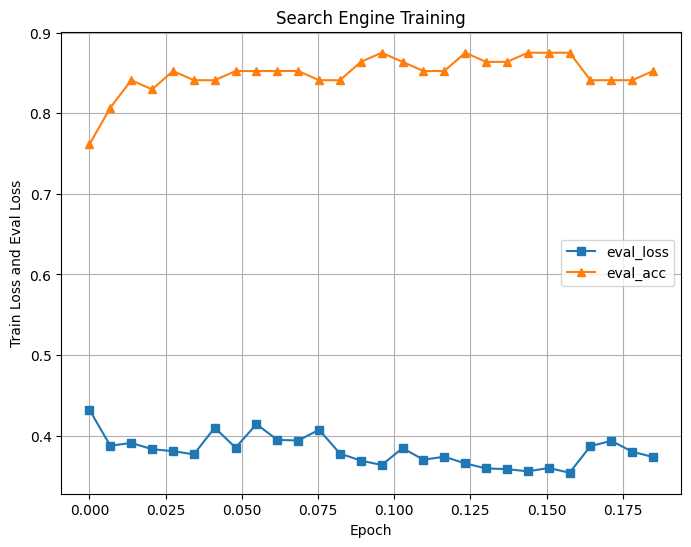

In [3]:
exp_dir = "exp2"
param_save_path = "model1"
last_check_point = "checkpoint-1100"
train_data_path = f"{exp_dir}/{param_save_path}/{last_check_point}/trainer_state.json"

import json
with open(train_data_path) as f:
    train_data = json.load(f)
    log_hist = train_data["log_history"]

train_epoch = []
eval_epoch = []
train_loss = []
eval_loss = []
eval_acc = []
for i, log_hist_data in enumerate(log_hist):
    if "eval_loss" in log_hist_data:
        eval_epoch.append(log_hist_data["epoch"])
        eval_loss.append(log_hist_data["eval_loss"])
        eval_acc.append(log_hist_data["eval_accuracy"])
    else:
        train_epoch.append(log_hist_data["epoch"])
        train_loss.append(log_hist_data["loss"])

import matplotlib.pyplot as plt
# Create a new figure with a specific size
plt.figure(figsize=(8, 6))

# Plot each set of values with markers and labels
#plt.plot(train_epoch, train_loss, marker='o', label='train_loss')
plt.plot(eval_epoch, eval_loss, marker='s', label='eval_loss')
plt.plot(eval_epoch, eval_acc, marker='^', label='eval_acc')

# Add labels and title
plt.xlabel('Epoch')
plt.ylabel('Train Loss and Eval Loss')
plt.title('Search Engine Training')

# Enable the legend and grid
plt.legend()
plt.grid(True)

# Display the plot
plt.show()



# Model Conversion

In [1]:
base_model_name = "/workspace/llama3b-rm"
checkpoint_path = "exp3/model1/checkpoint-40"
model_name = "exp3-model1-step40"

from transformers import AutoModelForSequenceClassification,AutoTokenizer,TrainingArguments,AutoConfig,AutoModelForCausalLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained(base_model_name, padding_side="left",add_eos_token=False,add_bos_token=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id

# Load the pre-trained model without the LM head.
# AutoModelForCausalLM usually refers to models with the LM head included, so you'd typically use a more specific base model class.
#base_model = AutoModelForCausalLM.from_config(config).base_model
model = AutoModelForSequenceClassification.from_pretrained(base_model_name, num_labels=1)

lora_model = PeftModel.from_pretrained(model, checkpoint_path)

reward_model = lora_model.merge_and_unload()

reward_model

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

LlamaForSequenceClassification(
  (model): LlamaModel(
    (embed_tokens): Embedding(128257, 3072, padding_idx=128256)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (k_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (v_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (up_proj): Linear(in_features=3072, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((3072,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((

In [2]:
save_dir = f"./{model_name}-converted-model"
score_save_path = f"./{model_name}-converted-score.pt"

import torch
tokenizer.save_pretrained(save_dir)
reward_model.save_pretrained(save_dir)
torch.save(reward_model.score.weight.data, score_save_path)
del reward_model

generate_model = AutoModelForCausalLM.from_pretrained(save_dir)
generate_model.save_pretrained(save_dir)
del generate_model

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

# Evaluation (Retrival)

In [2]:
# Need to use vllm==0.10.1 version to use this model
!pip install -U vllm==0.10.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 414.4/414.4 MB 116.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 163.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 187.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 112.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 168.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.1/117.1 MB 103.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 139.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 221.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 179.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 183.2 MB/s eta 0:00:00
   ━━━

In [2]:
# Data Loading

working_dir = "/workspace/RMS_exp"
#exp_dir = f"{working_dir}/exp2"
model_name = f"/workspace/llama3b-rm-converted-model"
exp_eval_dir = f"{model_name}-eval"
#dataset_load_path = f"{exp_dir}/dataset"
data_name = "smollm-corpus"
tensor_parallel_size = 1
num_instances = 4
output_path = f"{exp_eval_dir}/relevance_dict.json"

import os
import pandas as pd
import json
import torch

if not os.path.exists(exp_eval_dir): os.makedirs(exp_eval_dir)

df = pd.read_csv(f"{working_dir}/data/{data_name}/df_small.csv")                            # df["text"] = ["sentence1", .... ]
#df = df[:100]
with open(f"{working_dir}/data/{data_name}/query_dict.json") as f:
    query_dict = json.load(f)                                                               # { "0": {"titles":["",...], "keywords":["",...], "questions":["",...], "irr_questions":["",...] } }
with open(f"{working_dir}/data/{data_name}/sentences_relevant_to_questions.json") as f:
    relevant_sentences = json.load(f)                                                       # [{"query":, "query_id":, "correct_id":, "keys":[{"key":, "key_id":,}, ...]}, ... ]
with open(f"{working_dir}/data/{data_name}/tag2query-tag_tree.json") as f:
    tag_dict = json.load(f)                                                                 # [{"tag":"", "query_ids":[], "children":[{"tag":"", "query_ids":[]}, ...]}, ...]


In [3]:
import multiprocessing as mp
mp.set_start_method("spawn", force=True)  # do this ONCE per kernel before using mp

from vllm_reward2 import build_llm, search

device_groups = []
device_id = 0
for dp in range(num_instances):
    device_group = []
    for tp in range(tensor_parallel_size):
        device_group.append(device_id)
        device_id += 1

    device_groups.append(device_group)

#device_groups = [[0], [1]]  # 2 workers on GPU 0 and 1

rm = build_llm(
    model_name=model_name,
    tensor_parallel_size=len(device_groups[0]),
    num_instances=len(device_groups),
    device_groups=device_groups,
    max_model_len=2500,
    max_num_seqs=64,
    gpu_memory_utilization=0.90,
    runner="pooling",
)

tokenizer = rm.tokenizer


INFO 09-27 22:28:06 [__init__.py:241] Automatically detected platform cuda.


In [ ]:
# Put before importing vllm
import os
#os.environ.setdefault("VLLM_CONFIGURE_LOGGING", "0")  # don't let vLLM set up its own handlers
#os.environ.setdefault("VLLM_LOGGING_LEVEL", "ERROR")  # lower verbosity if vLLM config still applies

# After imports, as a belt-and-suspenders:
import logging
logging.getLogger("vllm").setLevel(logging.ERROR)


def llm_template_func(row):
    query = row["query"]
    key = row["key"]
    message = [{'role': 'user', 'content':f"""Give me relevance score between\n\nQuery:{query}\n\nand\n\nSentence:{key}"""}]
    if len(message[0]["content"]) > 4000: message[0]["content"] = message[0]["content"][:4000]+"..."
    prompt = tokenizer.apply_chat_template(message, tokenize=False)
    #prompt = prompt[17:]
    return prompt
    

def search_key(queries, keys, tag2key, k_tag=2, k_key=5, num_instances = 1):
    # queries: ["...", ...]
    # keys: ["...", ...]
    # tag2key: [{"tag":"", "key_ids":[0,2, ...], "children":[{"key_ids":[2, ...]},{"key_ids":[0, ...]}, ...]}, ...]
    
    query2tag_ids = [{"tag_ids":[[] for _ in range(k_tag)]} for i in range(len(queries))]   # query2tag_ids = [{"tag_ids":[[]]}, ...]   # (num_queries, "tag_ids":(k_tag, depth))
    
    tags = [tag2key_dict["tag"] for tag2key_dict in tag2key]
    tags_request = [{"tags":[tags]} for _ in range(len(queries))]    # tags_request = [{"tags":[[]]}, ...]   # (num_queries, "tags":(k_tag, num_tags_in_branch))
    while_end = False
    depth = 0

    def get_tag_dict(tag_ids, tag_dict):
        if tag_ids == []: return None
    
        for tag_id in tag_ids[:-1]:
            if "children" not in tag_dict[tag_id]:
                return None
            else:
                tag_dict = tag_dict[tag_id]["children"]
        
        return tag_dict[tag_ids[-1]]
    '''
    def get_tag_dict(tag_ids, tag_dict):
        if tag_ids == []: return None
    
        for tag_id in tag_ids[:-1]:
            tag_dict = tag_dict[tag_id]["children"]
        
        return tag_dict[tag_ids[-1]]
    '''

    while not while_end:

        depth += 1

        requests = []
        query_and_n_top_ids = [] # [(query_id, n_top), ...] # (num_request)
        total_requests = 0

        for query_id in range(len(tags_request)):
            for nth_tag_ids, tag_list in enumerate(tags_request[query_id]["tags"]):
                query_and_n_top_ids.append((query_id, nth_tag_ids))
                requests.append({"query":queries[query_id], "keys":tag_list, "k": k_tag, "return_relevance":True})
                total_requests += len(tag_list)

        path = f"search_key-output{depth}-test4.json"
        if not os.path.exists(path):
            batch_size = total_requests // num_instances
            print(f"Graph Depth: {depth},  total_requests: {total_requests},  Batch size: {batch_size}")
            output = search(rm, requests, llm_template_func, topk = k_tag, batch_size=5000, timeout_s=4000)
    
            with open(path, "w") as f:
                json.dump(output, f)
        else:
            with open(path) as f:
                output = json.load(f)
        
        tags_request = [{"tags":[]} for _ in range(len(queries))] # tags_request = [{"tags":[[]]}, ...]   # (num_queries, "tags":(k_tag, num_tags_in_branch))
        result1 = {query_id:{"tag_ids_list":[], "relevance_list":[]} for query_id in range(len(queries))}   # {"query_id":{"tag_ids_list":[[3,1],],"relevance_list":[]}}
        for reuqest_id, output_dict in enumerate(output):
            query_id, nth_tag_ids = query_and_n_top_ids[reuqest_id]
            tags = []
            tag_relevance = []
            pre_tag_ids = query2tag_ids[query_id]["tag_ids"][nth_tag_ids]

            for top_nth in range(k_tag):
                try:  # output[query_id]["keys"][top_nth] can be index out of range. It goes to next output_dict.
                    new_tag_id = output_dict["keys"][top_nth]["key_id"]
                    relevance = output_dict["keys"][top_nth]["relevance"]
                    result1[query_id]["tag_ids_list"].append(pre_tag_ids+[new_tag_id])
                    result1[query_id]["relevance_list"].append(relevance)
                except:
                    continue

        while_end = True

        for query_id in result1:
            tag_relevance = result1[query_id]["relevance_list"]
            tag_ids_list = result1[query_id]["tag_ids_list"]
            if len(tag_relevance) == 0:
                top_tag_ids_list = []
            if len(tag_relevance) < k_tag:  # if there are not enough tag_ids
                _, indices = torch.topk(torch.tensor(tag_relevance), k=len(tag_relevance))
                top_tag_ids_list = [tag_ids_list[index.item()] for index in indices]
            else:  # normal pattern
                _, indices = torch.topk(torch.tensor(tag_relevance), k=k_tag)
                top_tag_ids_list = [tag_ids_list[index.item()] for index in indices]
                
            #_, indices = torch.topk(torch.tensor(tag_relevance), k=k_tag)
            #top_tag_ids_list = [tag_ids_list[index.item()] for index in indices]
            query2tag_ids[query_id]["tag_ids"] = top_tag_ids_list
            for tag_ids in top_tag_ids_list:
                tag_dict = get_tag_dict(tag_ids, tag2key)
                if "children" not in tag_dict:
                    continue
                elif tag_dict["children"] == []:
                    continue

                tags = []
                for j in range(len(tag_dict["children"])):
                    tag = tag_dict["children"][j]["tag"]
                    tags.append(tag)

                while_end = False
                tags_request[query_id]["tags"].append(tags)
            
    query2key_ids = [] # [{"key_ids":[]}, ...]   # (num_queries, "key_ids":(n_total_hit_keys))
    total_requests = 0
    requests = []
    for query_id, _ in enumerate(query2tag_ids):
        combined_key_ids = []
        for tag_ids in _["tag_ids"]:
            tag_dict = get_tag_dict(tag_ids, tag2key)
            if "query_ids" in tag_dict:
                key_ids = tag_dict["query_ids"]
                combined_key_ids += key_ids
            
        
        query2key_ids.append({"key_ids":combined_key_ids})
        selected_keys = []
        for key_id in combined_key_ids:
            try:
                selected_keys.append(keys[key_id])
            except:
                continue
            #selected_keys = [keys[key_id] for key_id in combined_key_ids]
            
        requests.append({"query":queries[query_id], "keys":selected_keys, "k": k_key, "return_relevance":True})
        total_requests += len(selected_keys)

    #os.environ.setdefault("VLLM_CONFIGURE_LOGGING", "0")  # don't let vLLM set up its own handlers
    #os.environ.setdefault("VLLM_LOGGING_LEVEL", "ERROR")  # lower verbosity if vLLM config still applies

    batch_size = 10 # total_requests // num_instances
    print(f"Final Search,  total_requests: {total_requests},  Batch size: {batch_size}")
    output = search(rm, requests, llm_template_func, topk = k_key, batch_size=batch_size,  timeout_s=10000)

    # output : [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]
    return output

sentences = []
for i in range(len(df)):
    key = f"""{df.iloc[i]['text']}"""
    sentences.append(key)

questions = []
correct_ids = []
for id in range(len(df)):
    questions += query_dict[str(id)]["questions"]
    correct_ids += [id for _ in range(len(query_dict[str(id)]["questions"]))]

    
output = search_key(questions, sentences, tag_dict, k_tag=2, k_key=10, num_instances= num_instances)
# e.g. [{"query":, "query_id":0, "keys":[{"key_id":2,"key":,}, ...]}, ...]

for i in range(len(output)):
    output[i]["correct_id"] = correct_ids[i]
    for j in range(len(output[i]["keys"])):
        output[i]["keys"][j]["relevant_id"] = output[i]["keys"][j]["key_id"]

# output : [{"query":questions[0], "query_id":0, "keys":[{"relevant_id":8,"key":sentences[8],}, ...]}, ...]
with open(output_path, "w") as f:
    json.dump(output, f)

print("file_saved")


INFO 09-27 22:28:14 [__init__.py:241] Automatically detected platform cuda.
INFO 09-27 22:28:14 [__init__.py:241] Automatically detected platform cuda.
INFO 09-27 22:28:14 [__init__.py:241] Automatically detected platform cuda.
INFO 09-27 22:28:14 [__init__.py:241] Automatically detected platform cuda.
INFO 09-27 22:28:15 [utils.py:326] non-default args: {'model': '/workspace/llama3b-rm-converted-model', 'runner': 'pooling', 'max_model_len': 2500, 'max_num_seqs': 64, 'disable_log_stats': True}
INFO 09-27 22:28:15 [utils.py:326] non-default args: {'model': '/workspace/llama3b-rm-converted-model', 'runner': 'pooling', 'max_model_len': 2500, 'max_num_seqs': 64, 'disable_log_stats': True}
INFO 09-27 22:28:16 [utils.py:326] non-default args: {'model': '/workspace/llama3b-rm-converted-model', 'runner': 'pooling', 'max_model_len': 2500, 'max_num_seqs': 64, 'disable_log_stats': True}
INFO 09-27 22:28:16 [utils.py:326] non-default args: {'model': '/workspace/llama3b-rm-converted-model', 'runner

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 09-27 22:28:23 [__init__.py:983] Resolved `--convert auto` to `--convert embed`. Pass the value explicitly to silence this message.
INFO 09-27 22:28:23 [__init__.py:711] Resolved architecture: LlamaForCausalLM
INFO 09-27 22:28:23 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-27 22:28:23 [__init__.py:983] Resolved `--convert auto` to `--convert embed`. Pass the value explicitly to silence this message.
INFO 09-27 22:28:23 [__init__.py:711] Resolved architecture: LlamaForCausalLM
INFO 09-27 22:28:23 [__init__.py:983] Resolved `--convert auto` to `--convert embed`. Pass the value explicitly to silence this message.
INFO 09-27 22:28:23 [__init__.py:711] Resolved architecture: LlamaForCausalLM
INFO 09-27 22:28:23 [__init__.py:2816] Downcasting torch.float32 to torch.float16.
INFO 09-27 22:28:23 [__init__.py:1750] Using max model len 2500
INFO 09-27 22:28:23 [__init__.py:2816] Downcasting torch.float32 to torch.float16.
INFO 09-27 22:28:23 [__in

`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


INFO 09-27 22:28:24 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-27 22:28:24 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 09-27 22:28:24 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_0 pid=1240) INFO 09-27 22:28:24 [core.py:636] Waiting for init message from front-end.
(EngineCore_0 pid=1240) INFO 09-27 22:28:24 [core.py:74] Initializing a V1 LLM engine (v0.10.1) with config: model='/workspace/llama3b-rm-converted-model', speculative_config=None, tokenizer='/workspace/llama3b-rm-converted-model', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config={}, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=2500, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, device_co

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]
Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


## Derive nDCG

In [ ]:
#Problem with precisiob and recall definition

file_path = '/workspace/llama3b-rm-converted-model-eval/relevance_dict.json'

item_count = 0
items_to_print = 100
#10000 items need 3 seconds
#100000 items need 45 seconds

expected_id = []
retrieved_id = []
not_found_querie_ids = []
precision_result = [] 
rank_scores = []
MAP_score = 0
IDCG = 1
nDCG = 0
DCG = 0

try:
    with open(file_path, 'rb') as file:
        print(f"Reading first {items_to_print} items from '{file_path}'...")
        # 'item' refers to each element in the top-level array
        start_time = time.time()
        for item in ijson.items(file, 'item'):
            # The 'item' is a standard Python dictionary
            # print(f"--- Item {item_count + 1} ---")
            # Print a few key details to inspect the structure
            # if 'query' in item:
            #     print(f"query: {item['query']}")
            if 'query_id' in item:
                # print(f"query id: {item['query_id']}")
                found_match = False
            if 'correct_id' in item:
                # print(f"correct: {item['correct_id']}")
                c_id = int(item['correct_id'])
                expected_id.append(c_id)
                print(f"correct id: {expected_id}")
            if 'keys' in item:
                key_list=item["keys"]
                list_size = len(key_list)
                print(f"The keys have a total of {len(key_list)} items")
                # print(f"keys: {item['keys']}")
                for index, key in enumerate(key_list):
                    # print(i)
                    keyid=int(key["key_id"])
                    print(f"this is the id for this key: {keyid}")
                    # print(f"this is the id for the correct id: {c_id}")
                    if keyid == c_id:
                        retrieved_id.append(keyid)
                        found_match = True

                        position = index + 1
                        # score = (6-position) / 5
                        score = (list_size+1-position)/list_size
                        rank_scores.append(score)
                        print(f"retrieved ids right now is: {retrieved_id}")
                        break
                    # else:
                    #     incorrect_id.append(keyid)
                    #     print(f"Incorrect ids right now is: {incorrect_id}")
                    # print("----------------------------------------")
                #Each item have a query, query id, and key list that contain 5 keys 
                # if the correct key id appear in this top ten we add the id into the retrieved id, if not we add zero
            if not found_match:
                not_found_querie_ids.append(item['query_id'])
                score = 0
                rank_scores.append(score)

            ##Calculate nDCG
            print(f"score: {score}")
            if score == 0:
                rel = 0
            else:
                # rel = 6-5*score
                rel = (list_size+1)-(list_size)*score
            DCG = compute_DCG(rel)
            print(f"DCG: {DCG}")
            nDCG = nDCG + DCG/IDCG/items_to_print
            
            ##Calculate Precision
            # print(expected_id)
            # print(retrieved_id)
            # precision = compute_precision(expected_ids=expected_id, retrieved_ids=retrieved_id)
            # precision_result.append(precision)
            # print(f"precision: {precision}")
            # MAP_score = MAP_score + precision*score/items_to_print
            # print(f"MAP: {MAP_score}")
            
            item_count += 1
            if item_count >= items_to_print:
                break
        elapsed_time = time.time() - start_time
        print(f"✅ Process completed in {elapsed_time:.2f} seconds.")
        # array2D = np.array([precision_result])
        # mean_results = np.mean(array2D, axis=1)
        # results_df = pd.DataFrame(mean_results)
        # results_df.index = ["Precision@10"]  

        print(expected_id)
        print(retrieved_id)
        print(f"The length of expected list is {len(expected_id)}")
        print(f"The length of retrieved list is {len(retrieved_id)}")
        print(f"The length of incorrect list of query id is {len(not_found_querie_ids)}")
        # print(f"The scores are {rank_scores}")
        # print(f"The MAP score is {MAP_score}")
        print(f"The nDCG score is {nDCG}")
        # print(results_df)
        
except FileNotFoundError:
    print(f"Error: The file at '{file_path}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

## Old but can be relevant

In [ ]:
import torch

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    problems = data_dict["problems"]
    answers = data_dict["answers"]

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]

if overlapping_advice_data_load_path:
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)

    accepted_ids = overlapping_advice_data["accepted_ids"]

    accepted_train_advices = []
    for a_id in accepted_ids:
        accepted_train_advices.append(train_advices[a_id])

    n_train_advices = len(accepted_train_advices)
    advices = accepted_train_advices+test_advices
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)
    
else:
    n_train_advices = len(train_advices)
    advices = train_advices+test_advices
        
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)

import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    top_values, top_indices = torch.topk(relevance[new_problem_id], k=num_retrieval) # [num_retrieval]
    #print(top_values, top_indices)
    top_indices = top_indices.tolist()
    
    for k in k_values:
        top_indices_ = top_indices[:k]
        top_original_problem_ids = torch.tensor([advice_problem_ids[top_index] for top_index in top_indices_])
        #print(top_original_problem_ids, original_problem_id)
        result_tensor = torch.where(top_original_problem_ids==original_problem_id, 1, 0)
        n_correct_advice = torch.sum(result_tensor).item()
        num_correct_advice_dict[str(k)].append(n_correct_advice)

eval_result = {"num_correct_advice_dict":num_correct_advice_dict, "mean_n_correct_advice":{}}

for k in k_values:
    print()
    print(f"top-{k}")
    mean_n_correct_advice = sum(num_correct_advice_dict[str(k)])/len(num_correct_advice_dict[str(k)])
    print(f"mean n_correct_advice: {mean_n_correct_advice}")
    eval_result["mean_n_correct_advice"][str(k)] = mean_n_correct_advice

with open(eval_result_save_path, "w") as f:
    json.dump(eval_result, f)

print("eval_result has been saved")


### Old

In [ ]:
from typing import Any, Dict, List
import numpy as np
import ray
from packaging.version import Version
from ray.util.scheduling_strategies import PlacementGroupSchedulingStrategy
from vllm import LLM, SamplingParams
assert Version(ray.__version__) >= Version(
    "2.22.0"), "Ray version must be at least 2.22.0"
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModelForCausalLM

class pooler_config:
    def __init__(self):
        self.pooling_type = "LAST"
        self.normalize = False
        self.softmax = False
        self.softmax = False
        self.step_tag_id = None
        self.returned_token_ids = None

pooler_config_ = pooler_config()

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left",add_eos_token=True,add_bos_token=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    config.pad_token_id = config.eos_token_id


# Create a class to do batch inference.
class LLMPredictor:

    def __init__(self):
        # Create an LLM.
        self.llm = LLM(model=model_name,
                       dtype="bfloat16",
                       #dtype="float32",
                       tensor_parallel_size=tensor_parallel_size,
                       task="embed",
                       override_pooler_config=pooler_config_,)

    def __call__(self, batch: Dict[str, np.ndarray]) -> Dict[str, list]:
        outputs = self.llm.embed(batch["prompt"])

        embeddings = []
        for output in outputs:
            embeddings.append(output.outputs.embedding)
            #generated_text.append(' '.join([o.text for o in output.outputs]))

        return {
            "embeddings": embeddings
        }


# Read one text file from S3. Ray Data supports reading multiple files
# from cloud storage (such as JSONL, Parquet, CSV, binary format).
#ds = ray.data.read_text("s3://anonymous@air-example-data/prompts.txt")

# For tensor_parallel_size > 1, we need to create placement groups for vLLM
# to use. Every actor has to have its own placement group.
def scheduling_strategy_fn():
    # One bundle per tensor parallel worker
    pg = ray.util.placement_group(
        [{
            "GPU": 1,
            "CPU": 1
        }] * tensor_parallel_size,
        strategy="STRICT_PACK",
    )
    return dict(scheduling_strategy=PlacementGroupSchedulingStrategy(
        pg, placement_group_capture_child_tasks=True))


resources_kwarg: Dict[str, Any] = {}
if tensor_parallel_size == 1:
    # For tensor_parallel_size == 1, we simply set num_gpus=1.
    resources_kwarg["num_gpus"] = 1
else:
    # Otherwise, we have to set num_gpus=0 and provide
    # a function that will create a placement group for
    # each instance.
    resources_kwarg["num_gpus"] = 0
    resources_kwarg["ray_remote_args_fn"] = scheduling_strategy_fn



def get_relevance(problems, answers, advices):
    
    import pandas as pd
    import itertools
    
    # Generate the Cartesian product
    new_problem_ids = list(range(len(problems)))
    combinations = list(itertools.product(new_problem_ids, advices))
    df = pd.DataFrame(combinations, columns=['problem_id', 'advice'])
    df['problem'] = df['problem_id'].apply(lambda idx: problems[idx])
    df['answer'] = df['problem_id'].apply(lambda idx: answers[idx])
    
    from datasets import Dataset
    dataset1 = Dataset.from_pandas(df)
    
    def format(row):
        advice = row["advice"]
        problem = row["problem"]
        answer = row["answer"]
        answer = answer[:4000]
        
        message = [
          {'role': 'user', 'content': f"Give me an advice to the problem and answer below;\n\nProblem:{problem}\n\nAnswer:{answer}"},
          {'role': 'assistant', 'content': f"{advice}"}
        ]
        prompt = tokenizer.apply_chat_template(message, tokenize=False)
        prompt = prompt[17:]  # to eliminate <|begin_of_text|> because vllm automatically add it to prompt
        row["prompt"] = prompt
        return row
    
    formatted_dataset = dataset1.map(format)
    df_formatted = formatted_dataset.to_pandas()
    list_of_prompts = df_formatted[['prompt']].to_dict('records')  # [{"prompt":".."}, ...]
    
    ds = ray.data.from_items(list_of_prompts)
    #ds = ray.data.read_text("s3://anonymous@air-example-data/prompts.txt")
    
    batch_size = len(list_of_prompts)//num_instances
    
    # Apply batch inference for all input data.
    ds = ds.map_batches(
        LLMPredictor,
        # Set the concurrency to the number of LLM instances.
        concurrency=num_instances,
        # Specify the batch size for inference.
        batch_size=batch_size,
        **resources_kwarg,
    )
    
    # Peek first 10 results.
    # NOTE: This is for local testing and debugging. For production use case,
    # one should write full result out as shown below.
    # outputs = ds.take(limit=10)
    outputs = ds.take_all()  # [{"embeddings":(2d list)}, ...]
    
    #outputs = model.embed(prompts)
    from datasets import Dataset
    import torch
    dataset1 = Dataset.from_list(outputs)
    print("Putting All Embeddings onto GPU...")
    all_embeddings = torch.tensor(dataset1["embeddings"]).to("cuda")
    #all_embeddings = torch.tensor([outputs[i].outputs.embedding for i in range(len(outputs))]).to("cuda")
    rm_head = torch.load(score_path, weights_only=True)
    rm_head = rm_head.to(all_embeddings.device)
    print("Calculating matmul...")
    advice_rewards = torch.matmul(all_embeddings, rm_head.transpose(0,1)).squeeze()
    relevance = advice_rewards.reshape(len(problems), len(advices))  # [len(problems), len(advices)]
    print("Obtained Relevance")
    
    return relevance

#top_advice_rewards, advice_indices = torch.topk(reshaped_advice_rewards, k=num_retrival) # [len(problems), num_advices]
#torch.save(advice_indices, retrieved_advice_ids_save_path)  #all_advice_indices: [len(test_problem_ids), num_retrival]


In [ ]:
import torch

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    problems = data_dict["problems"]
    answers = data_dict["answers"]

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]

if overlapping_advice_data_load_path:
    with open(overlapping_advice_data_load_path) as f:
        overlapping_advice_data = json.load(f)

    accepted_ids = overlapping_advice_data["accepted_ids"]

    accepted_train_advices = []
    for a_id in accepted_ids:
        accepted_train_advices.append(train_advices[a_id])

    n_train_advices = len(accepted_train_advices)
    advices = accepted_train_advices+test_advices
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)
    
else:
    n_train_advices = len(train_advices)
    advices = train_advices+test_advices
        
    relevance = get_relevance(problems, answers, advices)
    
    train_relevance = relevance[:,:n_train_advices]
    test_relevance = relevance[:,n_train_advices:]
    
    torch.save(train_relevance, train_relevance_save_path)
    torch.save(test_relevance, test_relevance_save_path)

In [ ]:
import json
import torch

with open(train_data_dict_save_path) as f:
    train_data_dict = json.load(f)
    train_advices = train_data_dict["advice"]
    train_advice_problem_ids = train_data_dict["problem_id"]  # index of train_advices -> original_problem_id where advice belongs

with open(test_problem_and_answer_save_path) as f:
    data_dict = json.load(f)
    test_problems = data_dict["problems"]
    test_answers = data_dict["answers"]

with open(test_data_dict_save_path) as f:
    test_data_dict = json.load(f)
    test_advices = test_data_dict["advice"]
    test_advice_problem_ids = test_data_dict["problem_id"]  # index of test_advices -> original_problem_id where advice belongs

train_relevance = torch.load(train_relevance_save_path)  # [len(test_problems), len(train_advices)]
test_relevance = torch.load(test_relevance_save_path)  # [len(test_problems), len(test_dvices)]
n_test_problems, n_train_advices = train_relevance.shape
n_test_problems2, n_test_advices = test_relevance.shape
if not n_test_problems == n_test_problems2: raise Exception("wrong shape")
relevance = torch.cat((train_relevance, test_relevance), dim=1)

advice_problem_ids = train_advice_problem_ids + test_advice_problem_ids

from datasets import load_from_disk
formatted_dataset = load_from_disk(dataset_load_path)
train_problem_ids = formatted_dataset["train"]["problem_id"]
test_problem_ids = formatted_dataset["test"]["problem_id"]


num_correct_advice_dict = {str(k):[] for k in k_values}
for new_problem_id, original_problem_id in enumerate(test_problem_ids):
    top_values, top_indices = torch.topk(relevance[new_problem_id], k=num_retrieval) # [num_retrieval]
    #print(top_values, top_indices)
    top_indices = top_indices.tolist()
    
    for k in k_values:
        top_indices_ = top_indices[:k]
        top_original_problem_ids = torch.tensor([advice_problem_ids[top_index] for top_index in top_indices_])
        #print(top_original_problem_ids, original_problem_id)
        result_tensor = torch.where(top_original_problem_ids==original_problem_id, 1, 0)
        n_correct_advice = torch.sum(result_tensor).item()
        num_correct_advice_dict[str(k)].append(n_correct_advice)

eval_result = {"num_correct_advice_dict":num_correct_advice_dict, "mean_n_correct_advice":{}}

for k in k_values:
    print()
    print(f"top-{k}")
    mean_n_correct_advice = sum(num_correct_advice_dict[str(k)])/len(num_correct_advice_dict[str(k)])
    print(f"mean n_correct_advice: {mean_n_correct_advice}")
    eval_result["mean_n_correct_advice"][str(k)] = mean_n_correct_advice

with open(eval_result_save_path, "w") as f:
    json.dump(eval_result, f)

print("eval_result has been saved")


# Evaluation (?)

In [ ]:
# reset
import json, os, re
with open("file_dict.json") as f:
    file_dict = json.load(f)

for file_path in file_dict:
    with open(file_path, "w") as f:
        f.write(file_dict[file_path])

In [ ]:
import json
with open("data_dict.json") as f:
    data_dict = json.load(f)

In [ ]:
id = 1
bug = data_dict["bug"][id]
file_path = data_dict["file_path"][id]
line_list = data_dict["line_list"][id]
code_lines_list = data_dict["code_lines_list"][id]
print(file_path)
print(bug)

In [ ]:
# modify
if type(line_list)==list:
    line = line_list[0]
elif type(line_list)==int:
    line = line_list
else:
    raise Exception("error")

code_lines_list[line] = "//" + code_lines_list[line]
modified_code = "\n".join(code_lines_list)

with open(file_path, "w") as f:
    json.dump(modified_code, f)
    

In [ ]:
# for normal openhands
print(f'''You are an expert software engineer who writes concise, syntactically correct git patches.  
Output **only** one unified `git diff` that can be applied with `git apply` or `patch`.  
Do **not** include explanations, commentary, or extra text.

Project context:
This code is a script for car racing game created by unity. 

Bug description:
{bug}

Generate a patch that:
- Keeps code style consistent with surrounding code.
- Introduces no unrelated changes.
- Ensures all tests pass (and the bug is fixed).

Also prepend a Conventional Commits-style commit message above the diff.''')


In [ ]:
# for rmsearch + openhands
print(f'''You are an expert software engineer who writes concise, syntactically correct git patches.  
Output **only** one unified `git diff` that can be applied with `git apply` or `patch`.  
Do **not** include explanations, commentary, or extra text.
Also, when you search some files which may contain some error, try to use rmsearch as a tool to get relevant file paths.

Project context:
This code is a script for car racing game created by unity. 

Bug description:
{bug}

Generate a patch that:
- Keeps code style consistent with surrounding code.
- Introduces no unrelated changes.
- Ensures all tests pass (and the bug is fixed).

Also prepend a Conventional Commits-style commit message above the diff.''')

In [ ]:
print(f'''You are an expert software engineer who writes concise, syntactically correct git patches.  
Output **only** one unified `git diff` that can be applied with `git apply` or `patch`.  
Do **not** include explanations, commentary, or extra text.
Also, when you search some files which may contain some error, try to use rmsearch as a tool to get relevant file paths.

Project context:
This code is a script for car racing game created by unity. 

Bug description:
Player car and AI car don't move at all.

Generate a patch that:
- Keeps code style consistent with surrounding code.
- Introduces no unrelated changes.
- Ensures all tests pass (and the bug is fixed).

Also prepend a Conventional Commits-style commit message above the diff.''')

In [ ]:
def same_except_eol(text1: str, text2: str) -> bool:
    """
    Return True if the two pieces of text are identical after normalizing
    Windows (CR-LF) and old-Mac (CR) line endings to Unix (LF).
    """
    def _normalize(s: str) -> str:
        # 1. Convert CR-LF → LF
        s = s.replace("\r\n", "\n")
        # 2. Convert any lone CR → LF
        s = s.replace("\r", "\n")
        return s

    return _normalize(text1) == _normalize(text2)

same_except_eol

# Evaluation (Huan Eval)

In [2]:
"""
Run the server with:

pip3 install /workspace/RMSearch fastapi uvicorn[standard]
uvicorn main:app --host 0.0.0.0 --port 8000
"""

from typing import List, Optional
from pydantic import BaseModel
from rmsearch import Search
import json

# ── Search engine instance ────────────────────────────────────────────────────
search_engine = Search(
    model_name="/workspace/racing_debug/exp3-model1-step120-converted-model",
    tensor_parallel_size=1,
    pipeline_parallel_size=1,
)

tokenizer = search_engine.tokenizer

def llm_template_func(query, key):
    message = [
      {'role': 'user', 'content': f"Give me an expected bug issue to the file content;\n\nFile Content:{key}"},
      {'role': 'assistant', 'content': f"{query}"}
    ]
    message[0]["content"] = message[0]["content"][:4000]+"..."
    prompt = tokenizer.apply_chat_template(message, tokenize=False)
    #prompt = prompt[17:]
    return prompt

search_engine.llm_template = llm_template_func

# ── Fallback keys (only used when the caller omits "keys") ───────────────────
with open("file_dict_bug.json") as f:
    file_dict = json.load(f)

code_list = []
file_paths = []
for file_path in file_dict:
    code = file_dict[file_path]
    code_list.append(code)
    file_paths.append(file_path)
    
DEFAULT_KEYS: List[str] = code_list

# ── Request / Response schemas ───────────────────────────────────────────────
class SearchRequest(BaseModel):
    queries: List[str]
    keys: Optional[List[str]] = None        # optional
    k: Optional[int] = 5

class KeyOut2(BaseModel):
    key_id: int
    code: str
    file_path: str

class QueryOut2(BaseModel):
    query: str
    query_id: int
    keys: List[KeyOut2]

async def rmsearch2(req: SearchRequest):
    """
    Body examples
    -------------
    1) Provide queries only (use server-side default keys):
        {
          "queries": ["How to make LLM?", "What's the capital of Japan?"]
        }

    2) Provide both queries and custom keys:
        {
          "queries": ["How to make LLM?"],
          "keys":    ["LLM is Large Language Model ..."]
        }
    """
    
    keys = req.keys or DEFAULT_KEYS                    # choose key set
    output = await search_engine(req.queries, keys, k=req.k, return_relevance=True)  # e.g. [{"query":, "query_id":0, "keys":[{"key_id":8,"key":,}, ...]}, ...]

    #print(output)
    # Build the required structure
    response: List[QueryOut2] = []
    for output_dict in output:
        key_objs = [KeyOut2(key_id=key_dict["key_id"], code=key_dict["key"], file_path=file_paths[key_dict["key_id"]]) for key_dict in output_dict["keys"]]
        response.append(QueryOut2(query=output_dict["query"], query_id=output_dict["query_id"], keys=key_objs))

    return response

INFO 07-05 06:49:05 config.py:2167] Downcasting torch.float32 to torch.bfloat16.
WARNING 07-05 06:49:11 arg_utils.py:1096] The model has a long context length (131072). This may cause OOM errors during the initial memory profiling phase, or result in low performance due to small KV cache space. Consider setting --max-model-len to a smaller value.
INFO 07-05 06:49:11 llm_engine.py:249] Initializing an LLM engine (v0.6.5) with config: model='/workspace/racing_debug/exp3-model1-step120-converted-model', speculative_config=None, tokenizer='/workspace/racing_debug/exp3-model1-step120-converted-model', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=131072, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, d

Loading safetensors checkpoint shards:   0% Completed | 0/3 [00:00<?, ?it/s]


INFO 07-05 06:49:18 model_runner.py:1097] Loading model weights took 6.0160 GB


In [3]:
output = await rmsearch2(SearchRequest(queries=["The AI cars don't move."], k=10))

Map:   0%|          | 0/51 [00:00<?, ? examples/s]

INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 0.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 1.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 2.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 3.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 4.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 5.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 6.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 7.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 8.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 9.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 10.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 11.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 12.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 13.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 14.
INFO 07-05 06:49:18 async_llm_engine.py:211] Added request 15.
IN

In [5]:
for i in range(10):
    print(file_paths[output[0].keys[i].key_id])

/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/AI/AICarAvoidanceSmartSteering.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/AI/AIWaypointTracker.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/Car/CarColor.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/AI/AICarAvoidanceBehaviour.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/Car/CarUserControl.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/Car/CarController.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/Car/CarFreeze.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/ScriptableObjects/RaceManagerItem.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/Car/CarAIControl.cs
/Use

# Expand Dataset

In [1]:
# Use Model from local environment

import asyncio
from transformers import AutoTokenizer
from vllm import AsyncLLMEngine, AsyncEngineArgs, SamplingParams
import time, warnings
import os

model_name = "/workspace/qwen7b"
tensor_parallel_size = 1

engine_args = AsyncEngineArgs(
    model = model_name,
    tensor_parallel_size = tensor_parallel_size,
    gpu_memory_utilization=0.95,
)
engine = AsyncLLMEngine.from_engine_args(engine_args)
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side='left')



INFO 07-06 14:24:57 config.py:478] This model supports multiple tasks: {'score', 'generate', 'classify', 'reward', 'embed'}. Defaulting to 'generate'.
INFO 07-06 14:24:57 llm_engine.py:249] Initializing an LLM engine (v0.6.5) with config: model='/workspace/qwen7b', speculative_config=None, tokenizer='/workspace/qwen7b', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_time=False), seed=0, served_model_name=/workspace/qwen7b, num

Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


INFO 07-06 14:26:21 model_runner.py:1097] Loading model weights took 14.2487 GB
INFO 07-06 14:26:25 worker.py:241] Memory profiling takes 4.43 seconds
INFO 07-06 14:26:25 worker.py:241] the current vLLM instance can use total_gpu_memory (44.45GiB) x gpu_memory_utilization (0.95) = 42.23GiB
INFO 07-06 14:26:25 worker.py:241] model weights take 14.25GiB; non_torch_memory takes 0.10GiB; PyTorch activation peak memory takes 4.35GiB; the rest of the memory reserved for KV Cache is 23.52GiB.
INFO 07-06 14:26:26 gpu_executor.py:76] # GPU blocks: 27525, # CPU blocks: 4681
INFO 07-06 14:26:26 gpu_executor.py:80] Maximum concurrency for 32768 tokens per request: 13.44x
INFO 07-06 14:26:29 model_runner.py:1413] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 07-06 14:26:29 model_runner.py:1417] If out-of-memory error occurs during cudagraph cap

In [5]:
file_paths = ["/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/AI/AICarAvoidanceSmartSteering.cs",
                "/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/Car/CarAIControl.cs"]

import json
with open("file_dict_bug.json") as f:
    file_dict = json.load(f)

system = f"""You are an excellent code assistant. Judge which file is more relevant to fix the issue, file 1 or file 2. Return the id of more relevant file following the designated output format."""
    
prompt = f"""Issue:
AI cars don't move.

File 1:
```{file_paths[0]}
{file_dict[file_paths[0]]}
```

File 2:
```{file_paths[1]}
{file_dict[file_paths[1]]}
```

Output Format:
'''
(Provide your thought first)

<ID>1 or 2</ID>
'''

Let's think step by step."""

prompt = tokenizer.apply_chat_template(
                [{"role": "system", "content":system}, {"role": "user", "content":prompt}],
                tokenize=False,
                add_generation_prompt=True
            )

print(prompt)

final_output = None
results_generator = engine.generate(prompt, SamplingParams(temperature=0, max_tokens=9000), 0)
async for request_output in results_generator:
    # print(request_output) => for streaming
    final_output = request_output

output = final_output.outputs[0].text

output

<s>[INST]You are an excellent code assistant. Judge which file is more relevant to fix the issue, file 1 or file 2. Return the id of more relevant file following the designated output format.

Issue:
AI cars don't move.

File 1:
```/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/AI/AICarAvoidanceSmartSteering.cs
using UnityEngine;
using System.Collections;
/// <summary>
/// use two raycasts, one at each side of the car to detect obstacles and steer the other way
/// </summary>
namespace SpinMotion
{
    public class AICarAvoidanceSmartSteering : MonoBehaviour
    {
        public CarController aiCarController;
        public float raycastDistance = 2f;
        public float smartSteeringRaycastCheckDelay = 0.5f;
        public Vector3 leftRaycastOffset;
        public Vector3 rightRaycastOffset;

        private bool canCheckRaycast = true;
        private Vector3 leftRayOrigin;
        private Vector3 rightRayOrigin;

        private void Update()

"The issue described is that AI cars don't move. This suggests that the AI logic responsible for controlling the car's movement is not functioning correctly. Given the provided files, we need to determine which file is more relevant to fixing this issue.\n\n### Analysis:\n\n**File 1: `AICarAvoidanceSmartSteering.cs`**\n- This script is responsible for the AI car's steering logic based on raycasts to detect obstacles and steer accordingly.\n- It uses raycasts to determine if there are obstacles on the left or right side of the car and adjusts the steering force based on that.\n\n**File 2: `CarAIControl.cs`**\n- This script is responsible for the overall AI control of the car, including acceleration, braking, and steering.\n- It includes logic for handling different braking conditions, target following, and evasive actions.\n\n### Thought Process:\n- The issue of AI cars not moving could be due to several reasons, such as incorrect steering, lack of acceleration, or improper target setti

In [6]:
import re
def extract_text(textC: str, textB: str) -> str | None:
    # Build a non-greedy pattern like r'<tag>(.*?)</tag>'
    pattern = rf"<{re.escape(textB)}>(.*?)</{re.escape(textB)}>"
    match = re.search(pattern, textC, flags=re.DOTALL)
    return match.group(1) if match else None

def extract_int(text: str) -> int | None:
    """
    Return the first integer found in `text`.
    If no digits appear, return None.
    """
    match = re.search(r"-?\d+", text)  # handles negative numbers too
    return int(match.group()) if match else None

In [7]:
prompt = f"""Judge which file is more relevant to fix the issue? Return the id of more relevant file following the output format.

Issue:
AI cars don't move.

File 1:
```{file_paths[0]}
{file_dict[file_paths[0]]}
```

File 2:
```{file_paths[1]}
{file_dict[file_paths[1]]}
```

Output Format:
'''
<ID>1 or 2</ID>
'''
"""

final_output = None
results_generator = engine.generate(prompt, SamplingParams(temperature=0, max_tokens=9000), 0)
async for request_output in results_generator:
    # print(request_output) => for streaming
    final_output = request_output

output = final_output.outputs[0].text

output

INFO 07-06 13:25:52 async_llm_engine.py:211] Added request 0.


'```'

In [6]:
id = extract_text(output, "ID")
if not id: id = extract_int(output[-10:])
id

'1 or 2'

In [23]:
for key in file_dict:
    print(key)

/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/VFX/SkidTrail.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/CheckpointTracker.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/RealTimeRacePositions.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/Checkpoints.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/SFXPlayer.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/PlayerChangeCameras.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/Checkpoint.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/RaceFinishCamera.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/RaceFinish.cs
/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter

In [8]:
file_paths = ["/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/AI/AICarAvoidanceSmartSteering.cs",
                "/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/PlayersSpawner.cs"]


system = f"""You are an excellent code assistant. Judge which file is more relevant to fix the issue, file 1 or file 2. Return the id of more relevant file following the designated output format."""
    
prompt = f"""Issue:
AI cars don't move.

File 1:
```{file_paths[0]}
{file_dict[file_paths[0]]}
```

File 2:
```{file_paths[1]}
{file_dict[file_paths[1]]}
```

Output Format:
'''
(Provide your step by step thought first)

<ID>1 or 2</ID>
'''

Let's think step by step."""

prompt = tokenizer.apply_chat_template(
                [{"role": "system", "content":system}, {"role": "user", "content":prompt}],
                tokenize=False,
                add_generation_prompt=True
            )

final_output = None
results_generator = engine.generate(prompt, SamplingParams(temperature=0, max_tokens=9000), 0)
async for request_output in results_generator:
    # print(request_output) => for streaming
    final_output = request_output

output = final_output.outputs[0].text

output

INFO 07-06 13:26:06 async_llm_engine.py:211] Added request 0.


"To determine which file is more relevant to fix the issue of AI cars not moving, we need to consider the following:\n\n1. **Understanding the Issue**: The issue is that AI cars are not moving. This suggests that the AI logic responsible for controlling the movement of the cars is not functioning correctly.\n\n2. **Identifying Responsible Code**: The AI cars' movement is likely controlled by the `AICarAvoidanceSmartSteering` script, which is responsible for steering the car based on raycasts to detect obstacles.\n\n3. **File 1 Analysis**:\n   - **File Path**: `/Users/multivac/openhands/racing_test_bug/Assets/Racing Starter Kit/RSK Assets/Scripts/AI/AICarAvoidanceSmartSteering.cs`\n   - **Content**: This file contains the `AICarAvoidanceSmartSteering` class, which is responsible for the AI car's steering logic based on raycasts.\n   - **Relevance**: This file directly deals with the AI car's movement and steering, making it the most likely candidate for fixing the issue.\n\n4. **File 2 

In [9]:
id = extract_text(output, "ID")
if not id: id = extract_int(output[-10:])
id

'1'

In [26]:
output

"So, the issue is that the AI cars aren't moving. I need to figure out which file is more relevant to fix this issue.\n\nFirst, I'll look at the problem: AI cars aren't moving. So, the AI cars aren't moving as expected. Let's see what each file does.\n\nLooking at File 1: AICarAvoidanceSmartSteering.cs. This script seems to handle the AI car's steering. It uses raycasts to check for obstacles and steers the car away. It has a method CheckSmartSteering which does the raycast checks and sets forceSteering. Force steering probably affects the car's movement direction.\n\nIn the Update method, it calls CheckSmartSteering, which runs a coroutine. The coroutine checks for left and right hits, and based on that, sets the forceSteering to -1, 1, or 0. So, this script is responsible for making the AI car steer.\n\nLooking at File 2: PlayersSpawner.cs. This script is about spawning players and AI cars. It handles the creation of player and AI car objects, their positions, rotations, and checkpoi